Differential expression analysis of Bulk RNA-seq data of MEF cells


Date last updated: February 14,2024

Created by : Sayane Shome

The workflow for the DESEQ2 analysis has been adapted from the tutorial :
https://rstudio-pubs-static.s3.amazonaws.com/329027_593046fb6d7a427da6b2c538caf601e1.html#example-3-two-conditions-two-genotypes-with-an-interaction-term


"Here we have two genotypes, wild-type (wt) and mutant (mut). Two conditions: control (Control) and treated (LPS treated). We are interested in the responses of both wild-type and mutant to treatment. We are also interested in the differences in response between genotypes, which is captured by the interaction term in linear models."

The order of the samples has to be WT +/- LPS and then KO +/- LPS.

In [1]:
version #to make sure which R version and computer architecture the code was run

               _                           
platform       aarch64-apple-darwin20      
arch           aarch64                     
os             darwin20                    
system         aarch64, darwin20           
status                                     
major          4                           
minor          2.1                         
year           2022                        
month          06                          
day            23                          
svn rev        82513                       
language       R                           
version.string R version 4.2.1 (2022-06-23)
nickname       Funny-Looking Kid           

In [2]:
#loading packages

In [3]:
library(EnsDb.Mmusculus.v79)
library(DESeq2)
library(EnhancedVolcano)
library(tidyr)
library(ashr)
library(tidyverse)
library(knitr)
library(Glimma)
library(DESeq2)
library(pheatmap)
library(ggplot2)
library(dplyr)
library(plotly)
library(VennDiagram)
library(clusterProfiler)
library(enrichplot)
library(ggplot2)
library(ggridges)


Loading required package: ensembldb

Loading required package: BiocGenerics


Attaching package: ‘BiocGenerics’


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:base’:

    anyDuplicated, aperm, append, as.data.frame, basename, cbind,
    colnames, dirname, do.call, duplicated, eval, evalq, Filter, Find,
    get, grep, grepl, intersect, is.unsorted, lapply, Map, mapply,
    match, mget, order, paste, pmax, pmax.int, pmin, pmin.int,
    Position, rank, rbind, Reduce, rownames, sapply, setdiff, sort,
    table, tapply, union, unique, unsplit, which.max, which.min


Loading required package: GenomicRanges

Loading required package: stats4

Loading required package: S4Vectors

Warning message:
“package ‘S4Vectors’ was built under R version 4.2.2”

Attaching package: ‘S4Vectors’


The following objects are masked from ‘package:base’:

    expand.grid, I, unname


Loading required package: IRanges

Loading

In [4]:
#loading count matrix from processed data. The count matrix contains the count values obtained from RSEM. 

s <- read.csv('../all_unnorm_counts_MEF_minus_het_arranged.csv')
colnames(s)[1] <- "Ensemble_ID"
s4 <- s
#reading metadata about the count matrix
coldata <- read.csv('MEF_counts/coldata_minus_het_mef2020counts_v1.csv',header = FALSE)
metadata <- coldata



Complete sets of LPS + Ctrl

P4_5_lps1,P4_5_lps2,P4_5_lps3,P7_4_lps1,P7_4_lps2,P8_4_lps3,P8_4_lps4,P8_4_lps5,P4_5_ctrl1,P4_5_ctrl2,P4_5_ctrl3,P7_4_ctrl1,P7_4_ctrl2,P8_4_ctrl3,P8_4_ctrl4,P8_4_ctrl5	

In [5]:
#renaming columns

colnames(metadata)[1] <- "sample"
colnames(metadata)[2] <- "id"
colnames(metadata)[3] <- "genotype"
colnames(metadata)[4] <- "condition"


In [6]:
#This is how metadata table looks like.
metadata

sample,id,genotype,condition
<chr>,<chr>,<chr>,<chr>
AMC11,P8_4_Lps3,wt,LPS
AMC12,P8_4_Lps5,wt,LPS
AMC21,P8_4_Lps4,wt,LPS
AMC3,P7_4_Lps1,wt,LPS
AMC4,P7_4_Lps2,wt,LPS
AMC6,P4_5_Lps2,mut,LPS
AMC18,P4_5_Lps3,mut,LPS
AMC22,P4_5_Lps1,mut,LPS
AMC1,P7_4_Ctrl1,wt,Control


In [7]:
# Filtering rows with zero counts in more than four columns/samples

In [8]:
zeros_count <- apply(s4 == 0, 1, sum)
filtered_df <- s4[zeros_count <= 4, ]
s4 <- filtered_df 
s4[,3:18] <- s4[,3:18]+1 
s4[,3:18] <- round(s4[,3:18])

In [9]:
countData <- s4     #assigning metadata and countdata
metaData <- metadata


In [10]:
#Formatted the countData dataframe and 

In [11]:
countData <- read.csv('all_unnorm_counts_MEF_minus_het_arranged_genenames_added_for_ensembleids_v1.csv')

In [12]:
rownames(countData) <- countData$Ensemble_ID
#countData$Ensemble_ID <- NULL

In [13]:
countData <- countData %>%
  mutate(Gene_name = ifelse(is.na(Gene_name) | Gene_name == "", Ensemble_ID, Gene_name))

In [14]:
# Assuming numeric columns 2 to n contain expression data
countData_resolved <- countData %>%
  group_by(Gene_name) %>%
  summarise(across(where(is.numeric), mean))

In [15]:
countData_resolved

Gene_name,P8_4_Lps3,P8_4_Lps5,P8_4_Lps4,P7_4_Lps1,P7_4_Lps2,P4_5_Lps2,P4_5_Lps3,P4_5_Lps1,P7_4_Ctrl1,P7_4_Ctrl2,P8_4_Ctrl3,P8_4_Ctrl4,P8_4_Ctrl5,P4_5_Ctrl1,P4_5_Ctrl3,P4_5_Ctrl2
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
0610005C13Rik,22,33,23,18,17,19,4,45,22,50,47,65,36,47,34,28
0610007P14Rik,1218,1106,949,678,813,383,487,868,776,1632,1519,2159,1426,860,1021,644
0610009B22Rik,471,445,383,269,344,224,315,419,356,725,672,999,592,481,834,369
0610009E02Rik,36,17,29,12,16,26,56,41,18,43,32,48,45,48,56,33
0610009L18Rik,19,14,24,9,18,15,11,37,20,49,32,46,30,32,20,30
0610009O20Rik,1005,944,788,525,645,338,290,844,613,1273,1286,1920,1162,865,437,638
0610010F05Rik,1094,1061,884,642,835,388,284,954,699,1481,1372,1951,1222,989,911,675
0610010K14Rik,416,351,335,220,267,192,213,477,258,484,525,787,434,319,523,252
0610011F06Rik,300,223,219,139,158,95,227,305,178,355,382,515,336,277,366,224


In [16]:
countData1 <- as.data.frame(countData_resolved)
countData1[,2:17] <- round(countData1[,2:17])

In [17]:
countData1

Gene_name,P8_4_Lps3,P8_4_Lps5,P8_4_Lps4,P7_4_Lps1,P7_4_Lps2,P4_5_Lps2,P4_5_Lps3,P4_5_Lps1,P7_4_Ctrl1,P7_4_Ctrl2,P8_4_Ctrl3,P8_4_Ctrl4,P8_4_Ctrl5,P4_5_Ctrl1,P4_5_Ctrl3,P4_5_Ctrl2
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
0610005C13Rik,22,33,23,18,17,19,4,45,22,50,47,65,36,47,34,28
0610007P14Rik,1218,1106,949,678,813,383,487,868,776,1632,1519,2159,1426,860,1021,644
0610009B22Rik,471,445,383,269,344,224,315,419,356,725,672,999,592,481,834,369
0610009E02Rik,36,17,29,12,16,26,56,41,18,43,32,48,45,48,56,33
0610009L18Rik,19,14,24,9,18,15,11,37,20,49,32,46,30,32,20,30
0610009O20Rik,1005,944,788,525,645,338,290,844,613,1273,1286,1920,1162,865,437,638
0610010F05Rik,1094,1061,884,642,835,388,284,954,699,1481,1372,1951,1222,989,911,675
0610010K14Rik,416,351,335,220,267,192,213,477,258,484,525,787,434,319,523,252
0610011F06Rik,300,223,219,139,158,95,227,305,178,355,382,515,336,277,366,224


In [18]:
new_order <- c(9,10,11,12,13,1,2,3,4,5,14,15,16,6,7,8)

# Step 3: Rearrange the dataframe by the specified row indices
metadata <- metadata[new_order, ]
metadata

,sample,id,genotype,condition
,<chr>,<chr>,<chr>,<chr>
9,AMC1,P7_4_Ctrl1,wt,Control
10,AMC2,P7_4_Ctrl2,wt,Control
11,AMC10,P8_4_Ctrl3,wt,Control
12,AMC19,P8_4_Ctrl4,wt,Control
13,AMC20,P8_4_Ctrl5,wt,Control
1,AMC11,P8_4_Lps3,wt,LPS
2,AMC12,P8_4_Lps5,wt,LPS
3,AMC21,P8_4_Lps4,wt,LPS
4,AMC3,P7_4_Lps1,wt,LPS


In [19]:
metadata

,sample,id,genotype,condition
,<chr>,<chr>,<chr>,<chr>
9,AMC1,P7_4_Ctrl1,wt,Control
10,AMC2,P7_4_Ctrl2,wt,Control
11,AMC10,P8_4_Ctrl3,wt,Control
12,AMC19,P8_4_Ctrl4,wt,Control
13,AMC20,P8_4_Ctrl5,wt,Control
1,AMC11,P8_4_Lps3,wt,LPS
2,AMC12,P8_4_Lps5,wt,LPS
3,AMC21,P8_4_Lps4,wt,LPS
4,AMC3,P7_4_Lps1,wt,LPS


In [20]:
library(DESeq2)
library(tibble) # For tidy data handling

# Assuming 'metadata' is your metadata DataFrame and 'countData1' is your count matrix
# First, make sure 'countData1' has the correct row names (genes) and column names (samples)
rownames(countData1) <- countData1$Gene_name
countData1 <- countData1[, -1] # Remove the 'Gene_name' column

# Make sure the 'metadata' DataFrame is correctly ordered to match the samples in 'countData1'
# The order should match exactly with the column names of 'countData1'
metadata_ordered <- metadata[match(colnames(countData1), metadata$id), ]

# Create a DESeqDataSet
# Assuming 'metadata_ordered' now has the columns in the correct order: 'sample', 'id', 'genotype', 'condition'
# The 'design' formula you have can stay the same
dds <- DESeqDataSetFromMatrix(countData = countData1,
                              colData = DataFrame(metadata_ordered),
                              design = ~ genotype + condition + genotype:condition)

# At this point, 'dds' should have 'genotype' and 'condition' correctly aligned
# You can proceed with your DESeq2 analysis workflow


converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
"some variables in design formula are characters, converting to factors"


In [21]:
#Setting reference as Control and wildtype(wt) respectively.

In [22]:
#dds$condition <- factor(dds$condition, levels = c("LPS","Control"))
#dds$genotype <- factor(dds$genotype, levels = c("wt","mut"))

dds$condition <- relevel(dds$condition, ref = "Control")
dds$genotype <- relevel(dds$genotype, ref = "wt")

In [23]:
#running DESEq to obtain the DE results

In [24]:
#design(dds) <- ~ genotype + condition + genotype:condition
dds <- DESeq(dds) 
resultsNames(dds)

estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing



[1] "Intercept"                "genotype_mut_vs_wt"      
[3] "condition_LPS_vs_Control" "genotypemut.conditionLPS"

In [25]:
#Next part of code shows the results of how many DE genes shows up.

In [26]:
normalized_counts <- counts(dds, normalized=TRUE)
write.csv(normalized_counts,"MEF_Deseq2_2020countsdata_normalized_chk.csv")

In [27]:
manual_annotation <- data.frame(
  Genotype = factor(c("wt", "wt", "wt","wt","wt","wt","wt","wt","wt","wt","mut","mut","mut","mut","mut","mut")),
  Condition = factor(c("Control", "Control", "Control", "Control","Control","LPS", "LPS", "LPS","LPS","LPS","Control","Control", "Control","LPS","LPS","LPS"))
)

#annotation_col = as.data.frame(manual_annotation)

ann_colors <- list(
  Genotype = c("wt" = "#fe9388", "mut" = "#9bca1e"),
  Condition = c("Control" = "#05d8e1", "LPS" = "#e298fe")
)


# Ensure row names of annotations match the sample names, if needed
rownames(manual_annotation) <- colnames(normalized_counts)

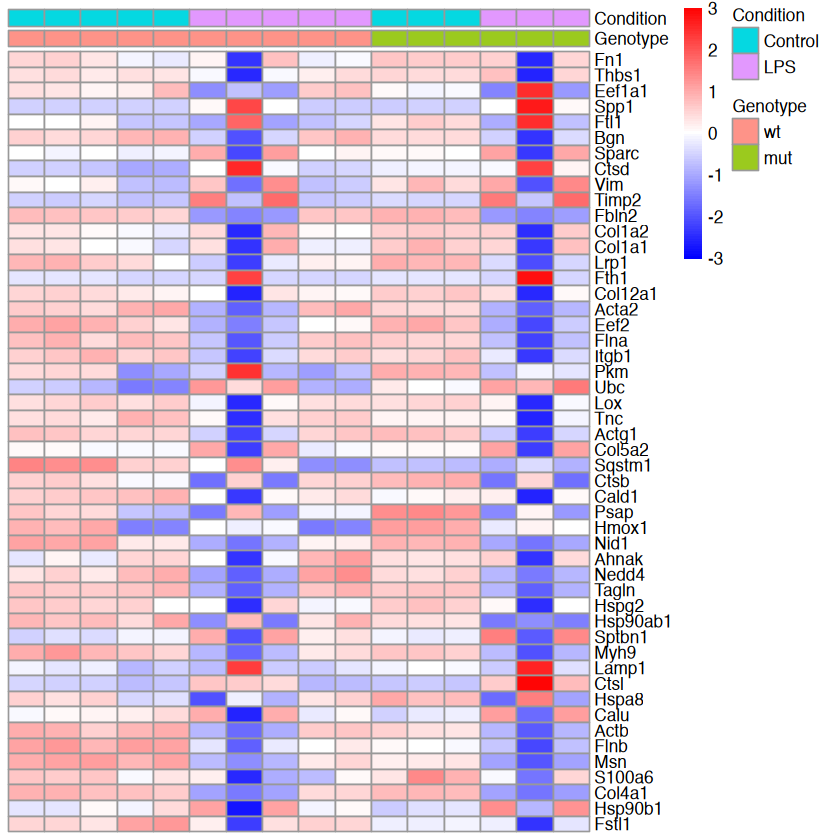

In [28]:
row_means_norm_counts <- apply(normalized_counts, 1, mean)

ordered_indices_norm_counts <- order(-row_means_norm_counts)
ordered_norm_counts <- normalized_counts[ordered_indices_norm_counts, ]
rows_to_keep <- !grepl("^(Gm|Mir|ENSMUS|Rpl.*|.*Rik|mt-|Malat1)", rownames(ordered_norm_counts))

# Filter the dataframe to remove undesired rows
ordered_norm_counts <- ordered_norm_counts[rows_to_keep, ]

# Assuming ordered_norm_counts, manual_annotation, and ann_colors are already defined

# Define the color palette, you might adjust this based on your preference
color_palette <- colorRampPalette(c("blue", "white", "red"))(101) # 101 colors for -3 to 3 scale

# Generate breaks from -3 to 3
breaks <- seq(-3, 3, length.out = length(color_palette))

# Plot the heatmap with the specified breaks and color scale
pheatmap(ordered_norm_counts[1:50, ],
         cluster_rows = FALSE, 
         cluster_cols = FALSE, 
         scale = "row", 
         show_rownames = TRUE, 
         show_colnames = FALSE,
         annotation_col = manual_annotation,
         annotation_colors = ann_colors,
         breaks = breaks,
         color = color_palette)


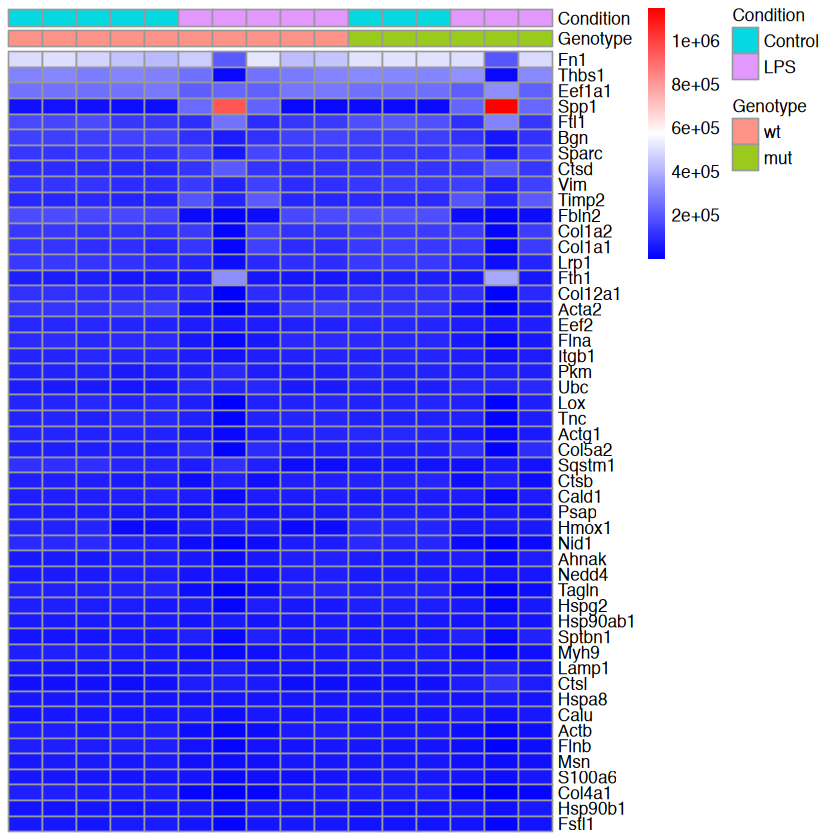

In [29]:
# Step 3: Plot the heatmap with ordered rows of normalized counts
pheatmap(ordered_norm_counts[1:50,],
         cluster_rows = FALSE, 
         cluster_cols = FALSE, 
         scale = "none", 
         show_rownames = TRUE, 
         show_colnames = FALSE,
         annotation_col = manual_annotation,
         annotation_colors = ann_colors,# Adjust based on your preference
         color = colorRampPalette(c("blue", "white", "red"))(255)) # Adjust color gradient as needed

In [30]:
LMC_top50genes_bycounts <- read.csv('LMC_top50_meanvalues_genenames.csv')

In [31]:
LMC_top50genes_bycounts$X <- NULL
colnames(LMC_top50genes_bycounts)[1] <- "Gene_name"


In [32]:
LMC_genes_data <- ordered_norm_counts[rownames(ordered_norm_counts) %in% LMC_top50genes_bycounts$Gene_name, ]
gene_names <- LMC_top50genes_bycounts$Gene_name[LMC_top50genes_bycounts$Gene_name %in% rownames(LMC_genes_data)]
LMC_genes_data_ordered <- LMC_genes_data[gene_names, ]


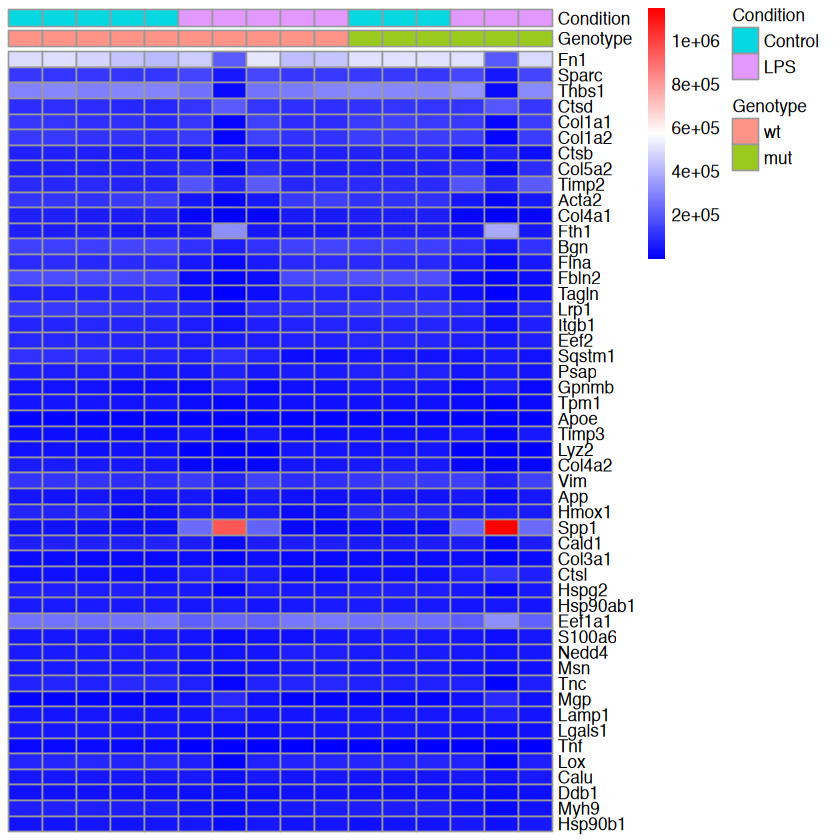

In [33]:
pheatmap(LMC_genes_data_ordered,
         cluster_rows = FALSE, 
         cluster_cols = FALSE, 
         scale = "none", 
         show_rownames = TRUE, 
         show_colnames = FALSE,
         annotation_col = manual_annotation,
         annotation_colors = ann_colors,# Adjust based on your preference
         color = colorRampPalette(c("blue", "white", "red"))(255)) # Adjust color gradient as needed

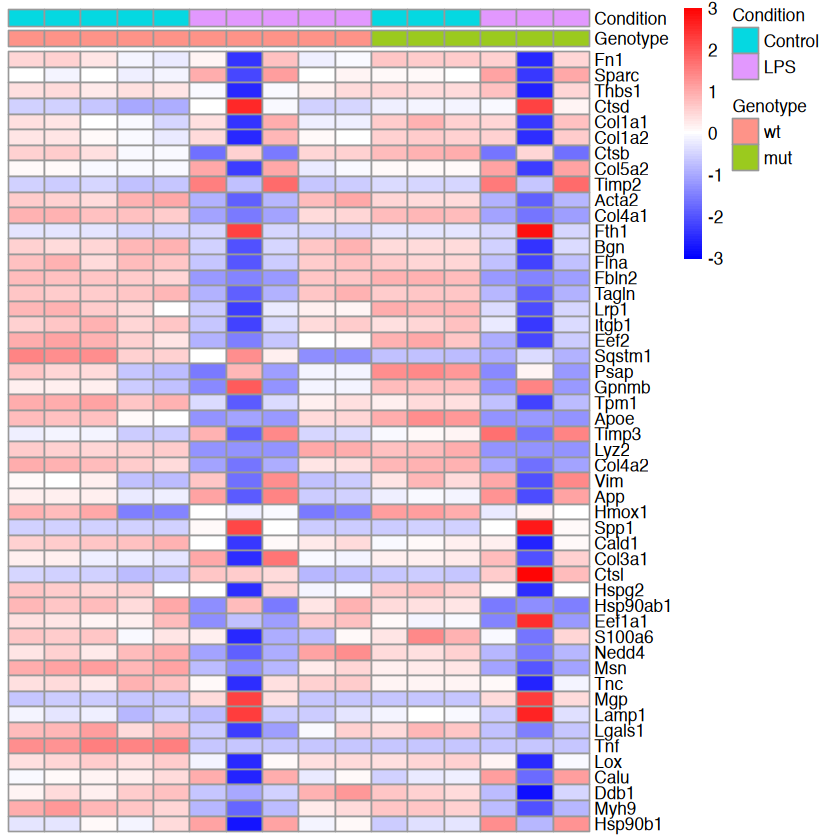

In [34]:
breaks <- seq(-3, 3, length.out = length(color_palette))

# Plot the heatmap with the specified breaks and color scale
pheatmap(LMC_genes_data_ordered,
         cluster_rows = FALSE, 
         cluster_cols = FALSE, 
         scale = "row", 
         show_rownames = TRUE, 
         show_colnames = FALSE,
         annotation_col = manual_annotation,
         annotation_colors = ann_colors,
         breaks = breaks,
         color = color_palette)

In [35]:
groups <- c("wt_Control", "wt_Control", "wt_Control","wt_Control","wt_Control","wt_LPS","wt_LPS","wt_LPS","wt_LPS","wt_LPS","mut_Control","mut_Control","mut_Control", "mut_LPS", "mut_LPS","mut_LPS")

In [36]:
normalized_counts_1 <- data.frame(normalized_counts)

In [37]:
normalized_counts_2 <- data.frame(
  Gene = rownames(normalized_counts_1),
  P8_4_Lps3_minus_Ctrl3 = normalized_counts_1$P8_4_Lps3 - normalized_counts_1$P8_4_Ctrl3,
  P8_4_Lps5_minus_Ctrl5 = normalized_counts_1$P8_4_Lps5 - normalized_counts_1$P8_4_Ctrl5,
  P8_4_Lps4_minus_Ctrl4 = normalized_counts_1$P8_4_Lps4 - normalized_counts_1$P8_4_Ctrl4,
  P7_4_Lps1_minus_Ctrl1 = normalized_counts_1$P7_4_Lps1 - normalized_counts_1$P7_4_Ctrl1,
  P7_4_Lps2_minus_Ctrl2 = normalized_counts_1$P7_4_Lps2 - normalized_counts_1$P7_4_Ctrl2,
  P4_5_Lps2_minus_Ctrl2 = normalized_counts_1$P4_5_Lps2 - normalized_counts_1$P4_5_Ctrl2,
  P4_5_Lps3_minus_Ctrl3 = normalized_counts_1$P4_5_Lps3 - normalized_counts_1$P4_5_Ctrl3,
  P4_5_Lps1_minus_Ctrl1 = normalized_counts_1$P4_5_Lps1 - normalized_counts_1$P4_5_Ctrl1
)


In [38]:
colnames(normalized_counts_2)[1] <- "Gene_name"
colnames(normalized_counts_2)[7] <- "P8_4_3"
colnames(normalized_counts_2)[9] <- "P8_4_5"
colnames(normalized_counts_2)[8] <- "P8_4_4"
colnames(normalized_counts_2)[5] <- "P7_4_1"
colnames(normalized_counts_2)[6] <- "P7_4_2"
colnames(normalized_counts_2)[3] <- "P4_5_2"
colnames(normalized_counts_2)[4] <- "P4_5_3"
colnames(normalized_counts_2)[2] <- "P4_5_1"

In [39]:
glimmaMDS(dds,html = "MDS_plot_MEF_all_samples_March27_2024.html")

Saving widget...

MDS_plot_MEF_all_samples_March27_2024.html generated.



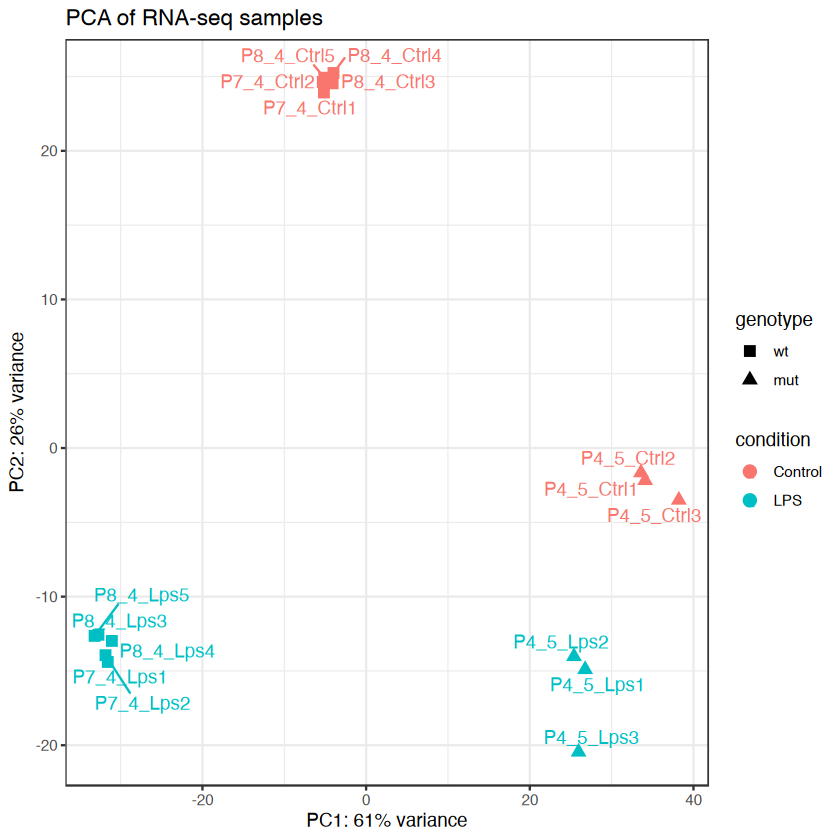

In [40]:
rlog_data <- rlog(dds)
pca_data <- plotPCA(rlog_data, intgroup=c("condition", "genotype"), returnData=TRUE)
percentVar <- round(100 * attr(pca_data, "percentVar"))
ggplot(pca_data, aes(x = PC1, y = PC2, color = condition, shape = genotype)) +
    geom_point(size = 3) +
    geom_text_repel(aes(label = row.names(pca_data))) +
    xlab(paste0("PC1: ", percentVar[1], "% variance")) +
    ylab(paste0("PC2: ", percentVar[2], "% variance")) +
    ggtitle("PCA of RNA-seq samples") +
    theme_bw() +
    scale_shape_manual(values = c(15, 17, 19))


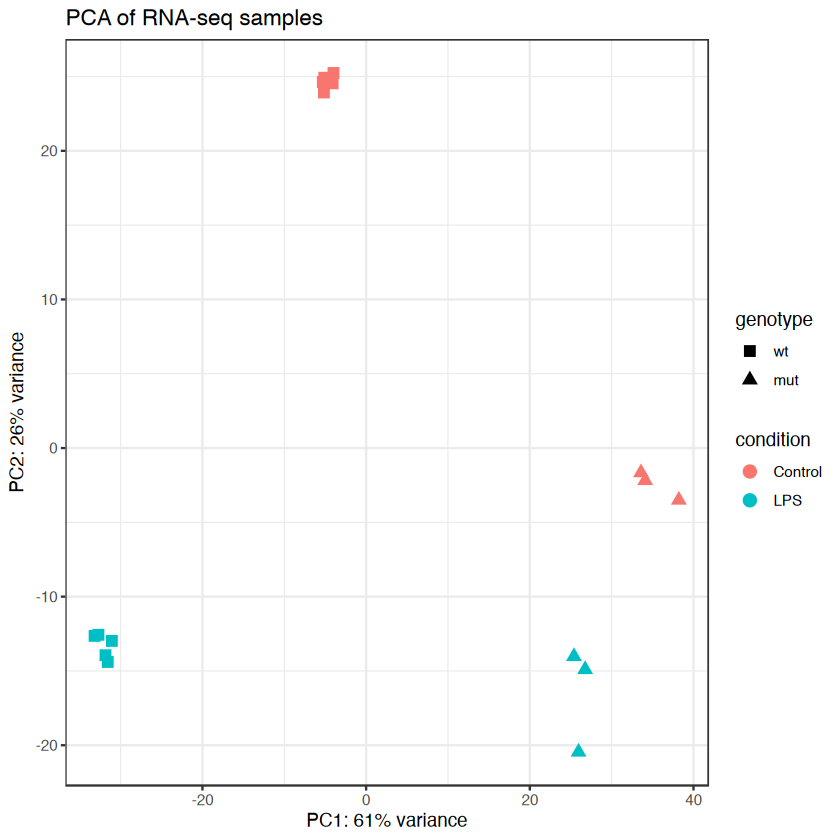

In [41]:
library(DESeq2)
library(ggplot2)
library(ggrepel) # Ensure you have ggrepel installed for geom_text_repel

# Assuming rlog_data and dds are already defined and correctly prepared
rlog_data <- rlog(dds)

pca_data <- plotPCA(rlog_data, intgroup=c("condition", "genotype"), returnData=TRUE)
percentVar <- round(100 * attr(pca_data, "percentVar"))

# Generate the PCA plot without sample names
ggplot(pca_data, aes(x = PC1, y = PC2, color = condition, shape = genotype)) +
    geom_point(size = 3) +
    xlab(paste0("PC1: ", percentVar[1], "% variance")) +
    ylab(paste0("PC2: ", percentVar[2], "% variance")) +
    ggtitle("PCA of RNA-seq samples") +
    theme_bw() +
    scale_shape_manual(values = c(15, 17, 19)) # Adjust shapes or colors as needed


In [42]:
pca_data_onlyControl <- pca_data %>%
  filter(condition == "Control")

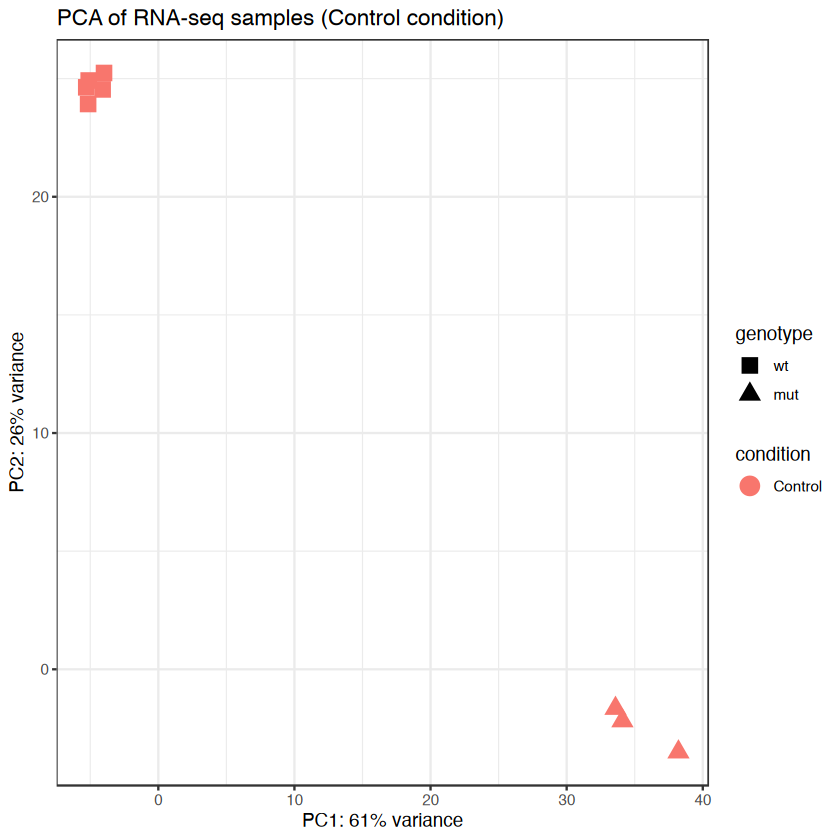

In [43]:
ggplot(pca_data_onlyControl, aes(x = PC1, y = PC2, color = condition, shape = genotype)) +
    geom_point(size = 4, stroke = 1) + # Adjust size and stroke for visibility
    xlab(paste0("PC1: ", percentVar[1], "% variance")) +
    ylab(paste0("PC2: ", percentVar[2], "% variance")) +
    ggtitle("PCA of RNA-seq samples (Control condition)") +
    theme_bw() +
    scale_shape_manual(values = c(15, 17, 19)) # Adjust shapes or colors as needed


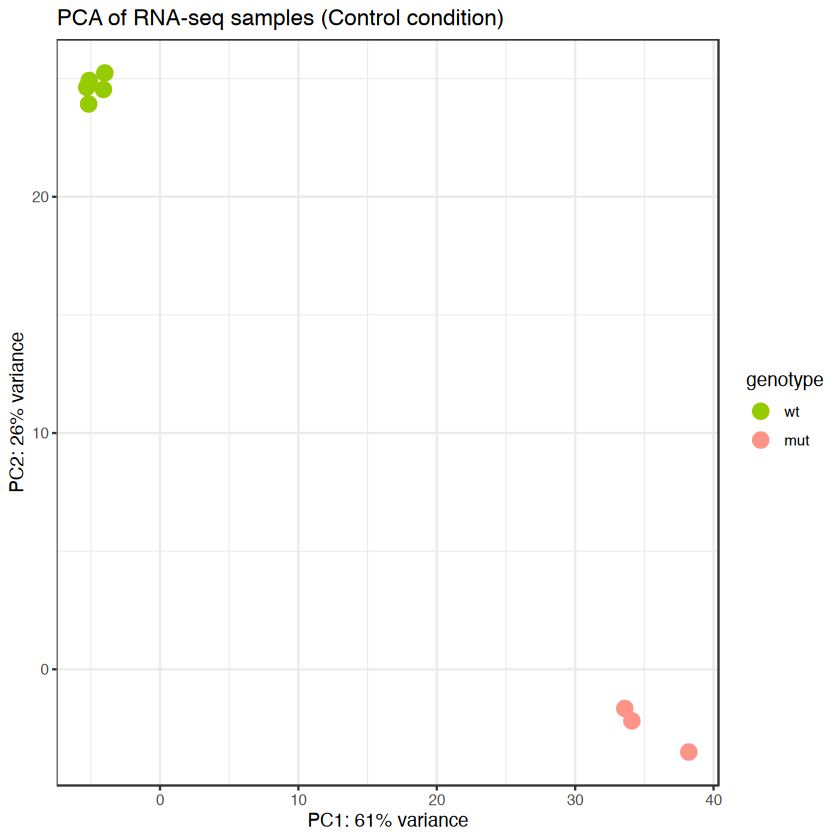

In [44]:
ggplot(pca_data_onlyControl, aes(x = PC1, y = PC2, color = genotype)) +
    geom_point(size = 4, stroke = 1, shape = 16) + # Shape set to 16 for all points
    xlab(paste0("PC1: ", percentVar[1], "% variance")) +
    ylab(paste0("PC2: ", percentVar[2], "% variance")) +
    ggtitle("PCA of RNA-seq samples (Control condition)") +
    theme_bw() +
    scale_color_manual(values = c("wt" = "#96cb01", "mut" = "#fe9388")) # Adjust as per your genotypes

Carrying out DE analysis using DESeq2


Next part of code should help answer this :


I.The effect of treatment in wild-type.[This is for WT, treated compared with untreated.]

1.Genes upregulated with LPS in wild-type samples

2.Genes downregulated with LPS in wild-type samples



II.The effect of treatment in mutant[This is for knockout,treated compared with untreated ]   


3.Genes upregulated with LPS in Sp3 knockout samples

4.Genes downregulated with LPS in Sp3 knockout samples



III.What is the difference between mutant and wild-type in control treatments ?[mutant ctrl compared with wild type ctrl]

5.Genes upregulated in wild-type samples in control treatment/Genes downregulated in wild-type samples in control treatment

6.Genes downregulated in wild-type samples in control treatment/Genes downregulated in wild-type samples in control treatment



IV.With LPS treatment, what is the difference between mutant and wild-type?[mutant LPS compared with wild type LPS]

8.Genes upregulated in mutant samples compared to wildtype with LPS treatment

9.Genes downregulated in mutant samples compared to wildtype with LPS treatment




In [45]:
res <- results(dds)
summary(res)


out of 20298 with nonzero total read count
adjusted p-value < 0.1
LFC > 0 (up)       : 472, 2.3%
LFC < 0 (down)     : 806, 4%
outliers [1]       : 106, 0.52%
low counts [2]     : 2361, 12%
(mean count < 6)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



In [46]:
#Plotting Glimma/scatter plots showing expression levels of particular gene across samples.
countData2 <- countData1
rownames(countData2) <- toupper(rownames(countData2))

gene_expression <- countData2["MEF2A",]  # Extract expression levels for particular gene
plot_data <- data.frame(
  Sample = colnames(countData2),  
  Expression = as.numeric(gene_expression),  
  Group = groups  
)
gene_name <- "MEF2A"

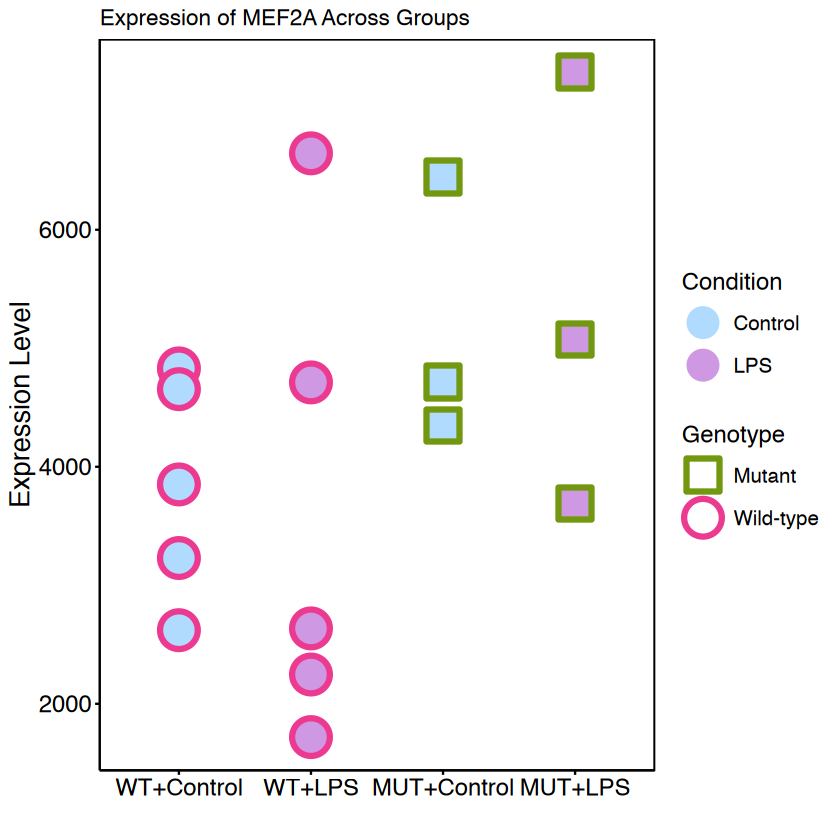

In [47]:
# Create Genotype and Condition columns based on the Group column
plot_data$Genotype <- ifelse(grepl("wt", plot_data$Group), "WT", "MUT")
plot_data$Condition <- ifelse(grepl("Control", plot_data$Group), "Control", "LPS")

# Create a new column for the combined labels
plot_data$Group_Combined <- with(plot_data, paste(Genotype, Condition, sep = "+"))

# Define the colors
genotype_colors <- c("WT" = "#fe9388", "MUT" = "#9bca1e")
condition_colors <- c("Control" = "#add8e6", "LPS" = "#e298fe")  # Lighter blue for Control

# Define the colors
genotype_colors <- c("WT" = "#EC3A91", "MUT" = "#71980E")  # Adjusted colors
condition_colors <- c("Control" = "#B0DBFF", "LPS" = "#CF98E2")  # Lightened inside colors

# Create the plot
ggplot(plot_data, aes(x = Group_Combined, y = Expression)) +
  geom_point(aes(fill = Condition, color = Genotype, shape = Genotype), size = 9, stroke = 2) +  # Use shape 21 for filled points with outline
  scale_fill_manual(name = "Condition", values = condition_colors, guide = guide_legend(override.aes = list(shape = 21, size = 9, stroke = 0))) +  # Inner circle colors and remove outline in legend
  scale_color_manual(name = "Genotype", values = genotype_colors, labels = c("WT" = "Wild-type", "MUT" = "Mutant")) +  # Outer circle colors
  scale_shape_manual(name = "Genotype", values = c("WT" = 21, "MUT" = 22), labels = c("WT" = "Wild-type", "MUT" = "Mutant")) +  # Shape 21 for circles, 22 for squares
  scale_x_discrete(limits = c("WT+Control", "WT+LPS", "MUT+Control", "MUT+LPS")) +  # Set the order of the x-axis labels
  labs(
    title = paste("Expression of", gene_name, "Across Groups"),
    x = "",
    y = "Expression Level"
  ) +
  theme_minimal() +
  theme(
    axis.text.x = element_text(size = 14, color = "black"),  # Increase x-axis label size
    axis.text.y = element_text(size = 14, color = "black"),  # Increase y-axis label size
    axis.title.x = element_text(size = 16),  # Increase x-axis title size
    axis.title.y = element_text(size = 16),  # Increase y-axis title size
    axis.ticks = element_line(color = "black"),
    axis.line = element_line(color = "black"),
    panel.background = element_blank(),
    panel.border = element_rect(color = "black", fill = NA),
    panel.grid.major = element_blank(),
    panel.grid.minor = element_blank(),
    legend.position = "right",
    legend.text = element_text(size = 12),  # Increase legend text size
    legend.title = element_text(size = 14),  # Increase legend title size
    legend.key = element_blank()  # Remove legend key outline
  )

In [48]:
library(dplyr)

# Calculate mean and sd for each group
summary_data <- plot_data %>%
  group_by(Group_Combined, Genotype, Condition) %>%
  summarise(
    mean_expression = mean(Expression, na.rm = TRUE),
    sd_expression = sd(Expression, na.rm = TRUE),
    n = n()
  )


`summarise()` has grouped output by 'Group_Combined', 'Genotype'. You can
override using the `.groups` argument.


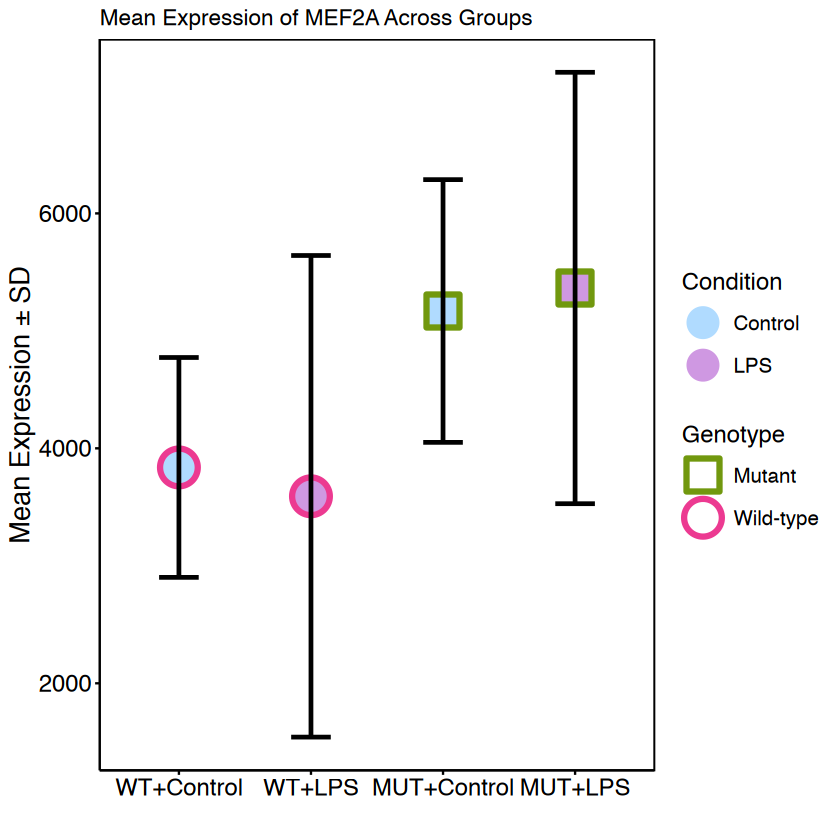

In [49]:
ggplot(summary_data, aes(x = Group_Combined, y = mean_expression)) +
  geom_point(
    aes(fill = Condition, color = Genotype, shape = Genotype),
    size = 9, stroke = 2
  ) +
  geom_errorbar(
    aes(ymin = mean_expression - sd_expression, ymax = mean_expression + sd_expression),
    width = 0.3, linewidth = 1
  ) +
  scale_fill_manual(
    name = "Condition",
    values = condition_colors,
    guide = guide_legend(override.aes = list(shape = 21, size = 9, stroke = 0))
  ) +
  scale_color_manual(
    name = "Genotype",
    values = genotype_colors,
    labels = c("WT" = "Wild-type", "MUT" = "Mutant")
  ) +
  scale_shape_manual(
    name = "Genotype",
    values = c("WT" = 21, "MUT" = 22),
    labels = c("WT" = "Wild-type", "MUT" = "Mutant")
  ) +
  scale_x_discrete(
    limits = c("WT+Control", "WT+LPS", "MUT+Control", "MUT+LPS")
  ) +
  labs(
    title = paste("Mean Expression of", gene_name, "Across Groups"),
    x = "",
    y = "Mean Expression ± SD"
  ) +
  theme_minimal() +
  theme(
    axis.text.x = element_text(size = 14, color = "black"),
    axis.text.y = element_text(size = 14, color = "black"),
    axis.title.x = element_text(size = 16),
    axis.title.y = element_text(size = 16),
    axis.ticks = element_line(color = "black"),
    axis.line = element_line(color = "black"),
    panel.background = element_blank(),
    panel.border = element_rect(color = "black", fill = NA),
    panel.grid.major = element_blank(),
    panel.grid.minor = element_blank(),
    legend.position = "right",
    legend.text = element_text(size = 12),
    legend.title = element_text(size = 14),
    legend.key = element_blank()
  )


In [50]:
# Load required libraries
library(ggplot2)

# Ensure gene names are in uppercase
countData2 <- countData1
rownames(countData2) <- toupper(rownames(countData2))

# Define gene lists
gene_list <- c(
  "CCL4"
)

# Define colors
genotype_colors <- c("WT" = "#EC3A91", "MUT" = "#71980E")
condition_colors <- c("Control" = "#B0DBFF", "LPS" = "#CF98E2")

# Create output directory
output_dir <- "Gene_Expression_Plots"
if (!dir.exists(output_dir)) dir.create(output_dir)

# Loop through each gene and generate the plots
for (gene in gene_list) {
  if (gene %in% rownames(countData2)) {
    gene_expression <- countData2[gene,]  # Extract expression levels
    
    plot_data <- data.frame(
      Sample = colnames(countData2),
      Expression = as.numeric(gene_expression),
      Group = groups
    )

    # Assign Genotype and Condition
    plot_data$Genotype <- ifelse(grepl("wt", plot_data$Group, ignore.case = TRUE), "WT", "MUT")
    plot_data$Condition <- ifelse(grepl("Control", plot_data$Group, ignore.case = TRUE), "Control", "LPS")
    plot_data$Group_Combined <- with(plot_data, paste(Genotype, Condition, sep = "+"))

    # Generate plot
    p <- ggplot(plot_data, aes(x = Group_Combined, y = Expression)) +
      geom_point(aes(fill = Condition, color = Genotype, shape = Genotype), size = 9, stroke = 2) +
      scale_fill_manual(name = "Condition", values = condition_colors, guide = guide_legend(override.aes = list(shape = 21, size = 9, stroke = 0))) +
      scale_color_manual(name = "Genotype", values = genotype_colors, labels = c("WT" = "Wild-type", "MUT" = "Mutant")) +
      scale_shape_manual(name = "Genotype", values = c("WT" = 21, "MUT" = 22), labels = c("WT" = "Wild-type", "MUT" = "Mutant")) +
      scale_x_discrete(limits = c("WT+Control", "WT+LPS", "MUT+Control", "MUT+LPS")) +
      labs(
        title = paste("Expression of", gene, "Across Groups"),
        x = "",
        y = "Expression Level"
      ) +
      theme_minimal() +
      theme(
        axis.text.x = element_text(size = 14, color = "black"),
        axis.text.y = element_text(size = 14, color = "black"),
        axis.title.x = element_text(size = 16),
        axis.title.y = element_text(size = 16),
        axis.ticks = element_line(color = "black"),
        axis.line = element_line(color = "black"),
        panel.background = element_blank(),
        panel.border = element_rect(color = "black", fill = NA),
        panel.grid.major = element_blank(),
        panel.grid.minor = element_blank(),
        legend.position = "right",
        legend.text = element_text(size = 12),
        legend.title = element_text(size = 14),
        legend.key = element_blank()
      )

    # Save plot
    plot_filename <- file.path(output_dir, paste0(gene, "_mef_expression_plot.png"))
    ggsave(plot_filename, plot = p, width = 8, height = 6, dpi = 300)
    
    message("Saved plot for: ", gene)
  } else {
    message("Gene not found in data: ", gene)
  }
}

message("All plots saved in the directory: ", output_dir)


Saved plot for: CCL4

All plots saved in the directory: Gene_Expression_Plots



In [51]:
# Load required libraries
library(ggplot2)

# Ensure gene names are in uppercase
countData2 <- countData1
rownames(countData2) <- toupper(rownames(countData2))

# Define gene list
gene_list <- c(
  "INCENP", "ZWILCH", "SPDL1", "CDCA8", "CDT1", "STIL", "GEN1", "SPC24", "TRIP13", "AURKA",
  "BUB1B", "AURKB", "BIRC5", "TTK", "NDC80", "CENPE", "CDC20", "NUF2", "PLK1", "BUB1",
  "KNTC1", "CCNB1",
  "PITX1", "TBX4", "HOXA11", "HOXA10", "BMP4", "SALL1", "HOXC11", "HOXC10", "LMX1B",
  "ALX3", "MSX1", "ALDH1A2", "GDF5", "GJA1", "LEF1", "NOG", "TBX2", "CRABP2", "HAND2",
  "CYP26B1", "TBX5", "RARB", "SHOX2", "FGF9", "HOXA9", "MSX2"
)

# Define colors
genotype_colors <- c("WT" = "#EC3A91", "MUT" = "#71980E")
condition_colors <- c("Control" = "#B0DBFF")  # Only Control remains

# Create output directory
output_dir <- "Gene_Expression_Plots"
if (!dir.exists(output_dir)) dir.create(output_dir)

# Loop through each gene and generate the plots
for (gene in gene_list) {
  if (gene %in% rownames(countData2)) {
    gene_expression <- countData2[gene,]  # Extract expression levels
    
    plot_data <- data.frame(
      Sample = colnames(countData2),
      Expression = as.numeric(gene_expression),
      Group = groups
    )

    # Assign Genotype and Condition
    plot_data$Genotype <- ifelse(grepl("wt", plot_data$Group, ignore.case = TRUE), "WT", "MUT")
    plot_data$Condition <- ifelse(grepl("Control", plot_data$Group, ignore.case = TRUE), "Control", "LPS")
    
    # Filter out LPS groups
    plot_data <- subset(plot_data, Condition == "Control")
    
    # Create a new column for the combined labels
    plot_data$Group_Combined <- with(plot_data, paste(Genotype, Condition, sep = "+"))

    # Generate plot
    p <- ggplot(plot_data, aes(x = Group_Combined, y = Expression)) +
      geom_point(aes(fill = Condition, color = Genotype, shape = Genotype), size = 9, stroke = 2) +
      scale_fill_manual(name = "Condition", values = condition_colors, guide = guide_legend(override.aes = list(shape = 21, size = 9, stroke = 0))) +
      scale_color_manual(name = "Genotype", values = genotype_colors, labels = c("WT" = "Wild-type", "MUT" = "Mutant")) +
      scale_shape_manual(name = "Genotype", values = c("WT" = 21, "MUT" = 22), labels = c("WT" = "Wild-type", "MUT" = "Mutant")) +
      scale_x_discrete(limits = c("WT+Control", "MUT+Control")) +  # Only control groups
      labs(
        title = paste("Expression of", gene, "Across Groups"),
        x = "",
        y = "Expression Level"
      ) +
      theme_minimal() +
      theme(
        axis.text.x = element_text(size = 14, color = "black"),
        axis.text.y = element_text(size = 14, color = "black"),
        axis.title.x = element_text(size = 16),
        axis.title.y = element_text(size = 16),
        axis.ticks = element_line(color = "black"),
        axis.line = element_line(color = "black"),
        panel.background = element_blank(),
        panel.border = element_rect(color = "black", fill = NA),
        panel.grid.major = element_blank(),
        panel.grid.minor = element_blank(),
        legend.position = "right",
        legend.text = element_text(size = 12),
        legend.title = element_text(size = 14),
        legend.key = element_blank()
      )

    # Save plot
    plot_filename <- file.path(output_dir, paste0(gene, "_mef_expression_plot_withoutLPS.png"))
    ggsave(plot_filename, plot = p, width = 8, height = 6, dpi = 300)
    
    message("Saved plot for: ", gene)
  } else {
    message("Gene not found in data: ", gene)
  }
}

message("All plots saved in the directory: ", output_dir)


Saved plot for: INCENP

Saved plot for: ZWILCH

Saved plot for: SPDL1

Saved plot for: CDCA8

Saved plot for: CDT1

Saved plot for: STIL

Saved plot for: GEN1

Saved plot for: SPC24

Saved plot for: TRIP13

Saved plot for: AURKA

Saved plot for: BUB1B

Saved plot for: AURKB

Saved plot for: BIRC5

Saved plot for: TTK

Saved plot for: NDC80

Saved plot for: CENPE

Saved plot for: CDC20

Saved plot for: NUF2

Saved plot for: PLK1

Saved plot for: BUB1

Saved plot for: KNTC1

Saved plot for: CCNB1

Saved plot for: PITX1

Saved plot for: TBX4

Saved plot for: HOXA11

Saved plot for: HOXA10

Saved plot for: BMP4

Saved plot for: SALL1

Saved plot for: HOXC11

Saved plot for: HOXC10

Saved plot for: LMX1B

Saved plot for: ALX3

Saved plot for: MSX1

Saved plot for: ALDH1A2

Saved plot for: GDF5

Saved plot for: GJA1

Saved plot for: LEF1

Saved plot for: NOG

Saved plot for: TBX2

Saved plot for: CRABP2

Saved plot for: HAND2

Saved plot for: CYP26B1

Saved plot for: TBX5

Saved plot for: RA

Warning message in brewer.pal(num_groups, "Set1"):
"minimal value for n is 3, returning requested palette with 3 different levels
"


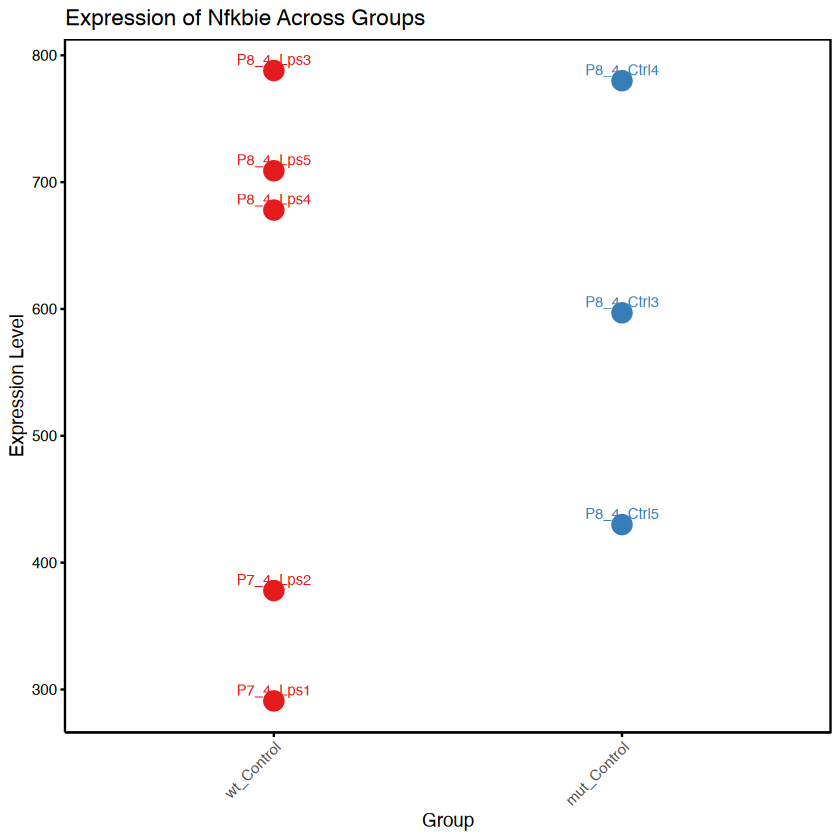

In [52]:
library(ggplot2)
library(RColorBrewer)

# Assuming 'plot_data' is already prepared with 'Sample', 'Expression', 'Group', and 'GeneName'
gene_name <- "Nfkbie"

# Prepare colors
num_groups <- length(unique(plot_data$Group))
palette <- brewer.pal(num_groups, "Set1")
if (num_groups > 9) { # Set1 has a maximum of 9 colors
  palette <- colorRampPalette(brewer.pal(9, "Set1"))(num_groups)
}

# Order the 'Group' factor based on unique values
plot_data$Group <- factor(plot_data$Group, levels = unique(plot_data$Group))

# Plot with sample names
ggplot(plot_data, aes(x = Group, y = Expression, color = Group)) +
  geom_point(size = 5) +  # Increase the size of the points
  geom_text(aes(label = Sample), vjust = -0.5, size = 3) +  # Add text labels for each sample
  scale_color_manual(values = palette) +  # Use the generated palette for colors
  labs(
    title = paste("Expression of", gene_name, "Across Groups"),
    x = "Group",
    y = "Expression Level"
  ) +
  theme_minimal() +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1),
    axis.text.y = element_text(color = "black"),
    axis.ticks = element_line(color = "black"),
    axis.line = element_line(color = "black"),
    panel.background = element_blank(),
    panel.border = element_rect(color = "black", fill = NA),
    panel.grid.major = element_blank(),
    panel.grid.minor = element_blank(),
    legend.position = "none"
  )


In [53]:
res <- results(dds, name="genotypemut.conditionLPS",alpha = 0.05)
topGenes <- head(order(res$padj), 50)
topGeneCounts <- countData[topGenes,]


In [54]:
topGenes <- head(order(res$log2FoldChange, na.last=NA), 60)  # na.last=NA removes NAs
countData <- counts(dds, normalized=TRUE)
topGeneCounts <- countData[topGenes, ]
rownames(manual_annotation) <- colnames(topGeneCounts)

In [55]:
# Remove rows where row name starts with 'NA'
filtered_topGeneCounts <- topGeneCounts[!grepl("^NA", rownames(topGeneCounts)), ]


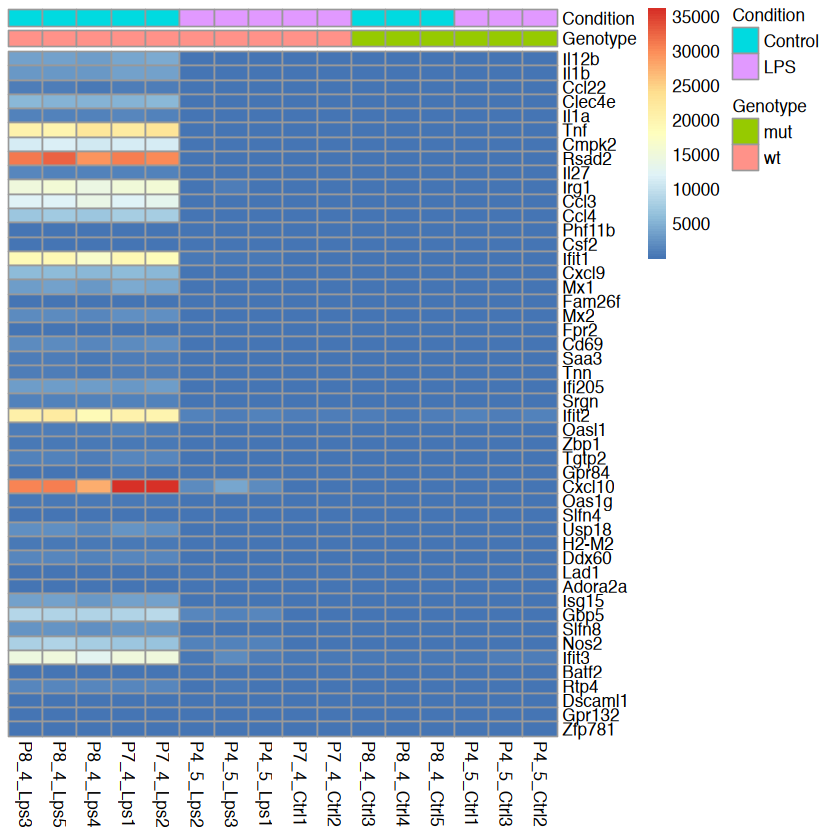

In [56]:
# Filter the rows of filtered_topGeneCounts based on your criteria
filtered_rows <- rownames(filtered_topGeneCounts)[!grepl("^Gm|^Mir|^ENSMUS|^Rpl|Rik$", rownames(filtered_topGeneCounts))]

# Subset the dataframe to include only the filtered rows
filtered_topGeneCounts_filtered <- filtered_topGeneCounts[filtered_rows, ]

# Create the heatmap with the filtered dataframe
pheatmap(filtered_topGeneCounts_filtered, 
         cluster_rows = FALSE, 
         cluster_cols = FALSE, 
         annotation_col = as.data.frame(manual_annotation), 
         show_rownames = TRUE)

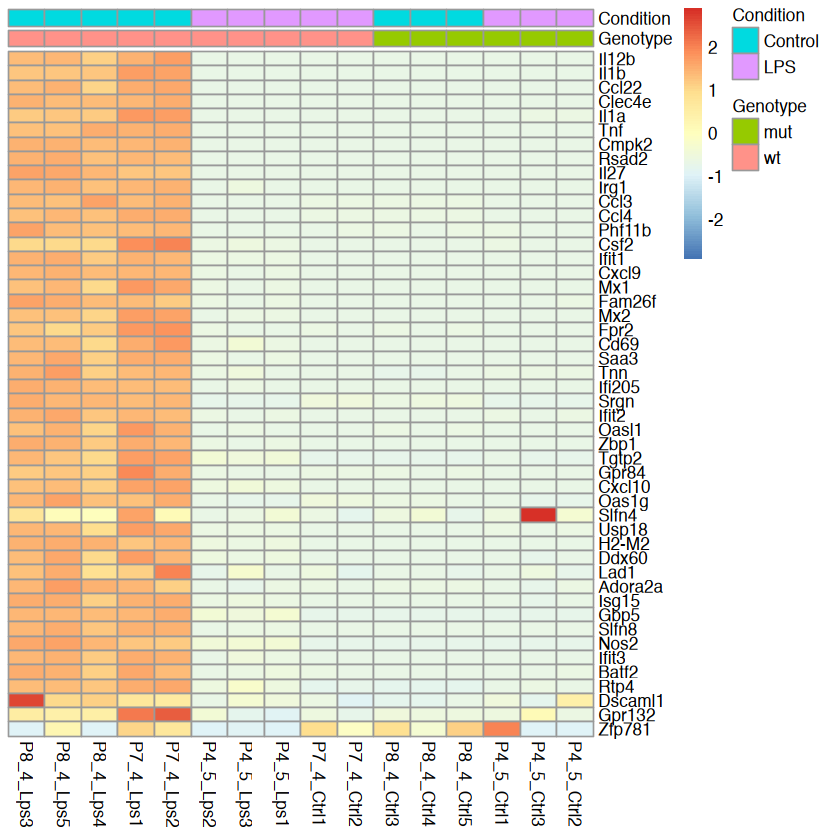

In [57]:
# Create the heatmap with the filtered dataframe
pheatmap(filtered_topGeneCounts_filtered, 
         cluster_rows = FALSE, 
         cluster_cols = FALSE, 
         scale = "row",
         annotation_col = as.data.frame(manual_annotation), 
         show_rownames = TRUE)

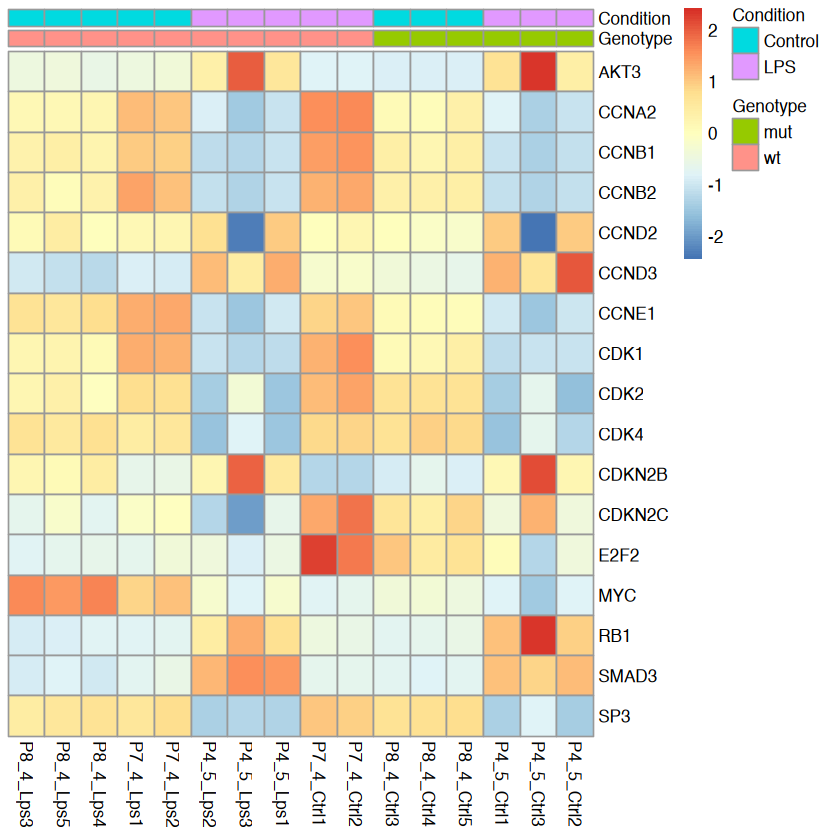

In [58]:
cell_cycle_mef <- read.table('mef_cellcyclegenes.txt')
cell_cycle_lmc <- read.table('lmc_cellcyclegenes.txt')
colnames(cell_cycle_mef)[1] <- "Gene_name"
colnames(cell_cycle_lmc)[1] <- "Gene_name"
cell_cycle_mef_combo <- rbind(cell_cycle_lmc,cell_cycle_mef)

cell_cycle_mef_combo$Gene_name <- toupper(cell_cycle_mef_combo$Gene_name)







# Filter the countData to include only genes in the nf_kb list
rownames(countData) <- toupper(rownames(countData))
cell_cycle_res <- intersect(rownames(countData), cell_cycle_mef_combo$Gene_name)
filteredCountData_cellcycle <- countData[cell_cycle_res, ]



# Plot the heatmap for the top 100 genes
pheatmap(filteredCountData_cellcycle, 
         cluster_rows = FALSE, 
         cluster_cols = FALSE, 
         annotation_col = as.data.frame(manual_annotation), 
         show_rownames = TRUE,scale = 'row')

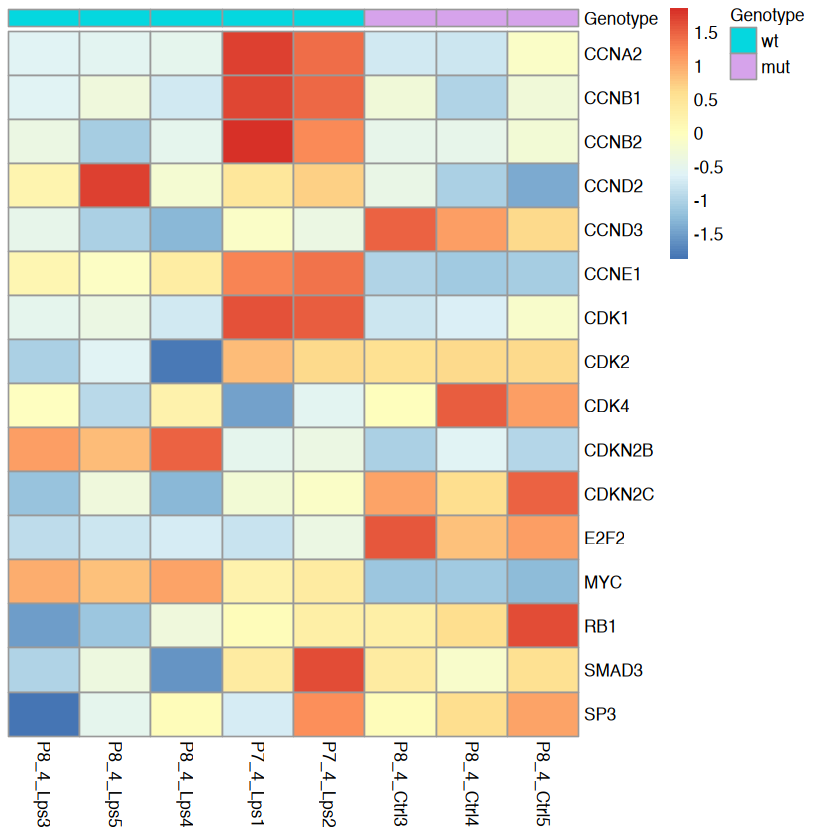

In [59]:
# Create the manual_annotation data frame with only Genotype
manual_annotation <- data.frame(
  Genotype = factor(c("wt", "wt", "wt", "wt", "wt", "wt", "wt", "wt", "wt", "wt", "mut", "mut", "mut", "mut", "mut", "mut")),
  Condition = factor(c("Control", "Control", "Control", "Control", "Control", "LPS", "LPS", "LPS", "LPS", "LPS", "Control", "Control", "Control", "LPS", "LPS", "LPS"))
)

# Define annotation colors for Genotype only
ann_colors <- list(
  Genotype = c("wt" = "#05d7df", "mut" = "#d6a3eb")
)

# Read the cell cycle gene data
cell_cycle_mef <- read.table('mef_cellcyclegenes.txt', header = TRUE)
cell_cycle_lmc <- read.table('lmc_cellcyclegenes.txt', header = TRUE)
colnames(cell_cycle_mef)[1] <- "Gene_name"
colnames(cell_cycle_lmc)[1] <- "Gene_name"

# Combine the gene data and convert gene names to uppercase
cell_cycle_mef_combo <- rbind(cell_cycle_lmc, cell_cycle_mef)
cell_cycle_mef_combo$Gene_name <- toupper(cell_cycle_mef_combo$Gene_name)

# Ensure rownames of countData are uppercase
rownames(countData) <- toupper(rownames(countData))

# Filter the countData to include only genes in the cell cycle list
cell_cycle_res <- intersect(rownames(countData), cell_cycle_mef_combo$Gene_name)
filteredCountData_cellcycle <- countData[cell_cycle_res, ]

# Subset the manual_annotation and filteredCountData_cellcycle to exclude LPS samples
samples_to_keep <- manual_annotation$Condition != "LPS"
filteredCountData_cellcycle <- filteredCountData_cellcycle[, samples_to_keep]
manual_annotation_filtered <- manual_annotation[samples_to_keep, "Genotype", drop = FALSE]

# Set the row names of manual_annotation_filtered to match the column names of filteredCountData_cellcycle
rownames(manual_annotation_filtered) <- colnames(filteredCountData_cellcycle)

# Check for any NA or infinite values and remove them
filteredCountData_cellcycle <- filteredCountData_cellcycle[complete.cases(filteredCountData_cellcycle), ]

# Ensure the data is not empty after filtering
if (nrow(filteredCountData_cellcycle) == 0 || ncol(filteredCountData_cellcycle) == 0) {
  stop("Filtered data contains no rows or columns. Please check your data and filtering criteria.")
}

# Plot the heatmap for the filtered data using only Genotype annotations
pheatmap(filteredCountData_cellcycle, 
         cluster_rows = FALSE, 
         cluster_cols = FALSE, 
         annotation_col = manual_annotation_filtered, 
         show_rownames = TRUE, 
         scale = 'row',
         annotation_colors = ann_colors)



In [60]:
#troubleshoot if needed

nf_kb <- read.table('nf_kb_sites.txt')
colnames(nf_kb)[1] <- "Gene_name"
# Filter the countData to include only genes in the nf_kb list
rownames(countData) <- toupper(rownames(countData))
nf_kb_genes <- intersect(rownames(countData), nf_kb$Gene_name)
filteredCountData <- countData[nf_kb_genes, ]

# Rank genes based on their mean expression levels and select the top 100
meanExpressionLevels <- rowMeans(filteredCountData)
top100Genes <- names(sort(meanExpressionLevels, decreasing = TRUE))[1:50]
filteredCountDataTop100 <- filteredCountData[top100Genes, ]

# Apply further filtering if necessary (you might want to skip this if focusing on top 100 already)
# Example pattern shown in your request - adjust if using this additional filter step
filtered_rows <- grep("^(?!GM|MIR|ENSMUS|RPL|RIK).*$", rownames(filteredCountDataTop100), perl = TRUE)
filteredCountDataTop100Filtered <- filteredCountDataTop100[filtered_rows, ]




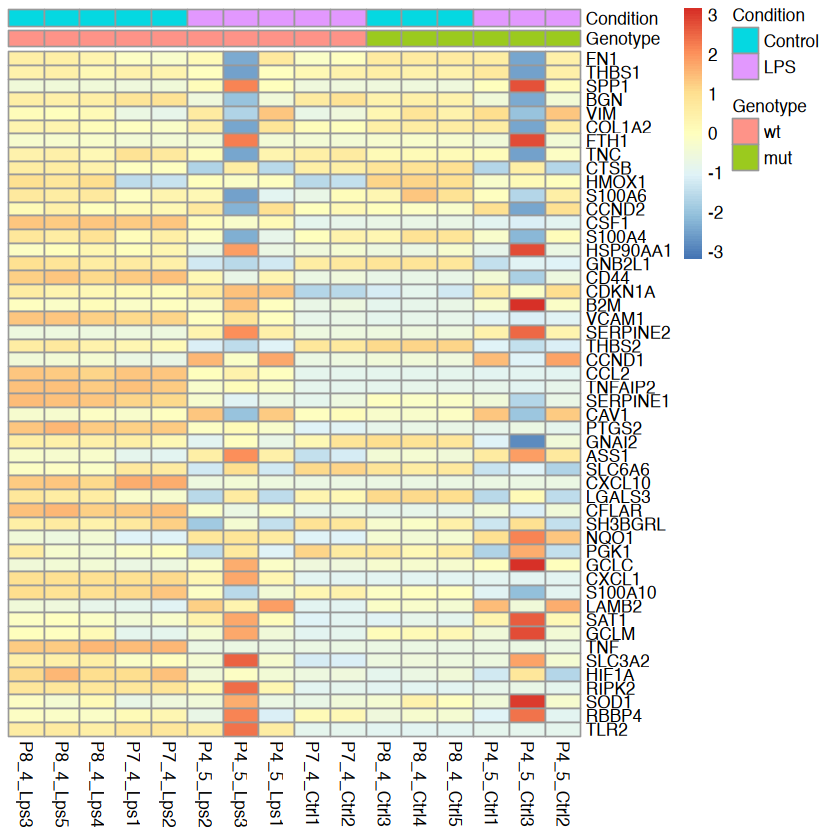

In [61]:
library(pheatmap)

# Create the manual annotation dataframe
manual_annotation <- data.frame(
  Genotype = factor(c("wt", "wt", "wt", "wt", "wt", "wt", "wt", "wt", "wt", "wt", "mut", "mut", "mut", "mut", "mut", "mut")),
  Condition = factor(c("Control", "Control", "Control", "Control", "Control", "LPS", "LPS", "LPS", "LPS", "LPS", "Control", "Control", "Control", "LPS", "LPS", "LPS"))
)

# Define annotation colors
ann_colors <- list(
  Genotype = c("wt" = "#fe9388", "mut" = "#9bca1e"),
  Condition = c("Control" = "#05d8e1", "LPS" = "#e298fe")
)

rownames(manual_annotation) <- colnames(filteredCountDataTop100Filtered)
#plot the heatmap
pheatmap(filteredCountDataTop100Filtered,
         cluster_rows = FALSE,
         cluster_cols = FALSE,
         annotation_col = manual_annotation,
         annotation_colors = ann_colors,
         show_rownames = TRUE,
         scale = "row")

In [62]:
res <- results(dds, name="genotypemut.conditionLPS")

In [63]:
# Correctly filtering genes, accounting for NAs in 'padj'
filtered_genes <- res[!is.na(res$log2FoldChange) & !is.na(res$padj) & res$padj < 0.05, ]


In [64]:
#The next part of code will help obtain the following answer.

I.The effect of treatment in wild-type.[This is for WT, treated compared with untreated.]

1.Genes upregulated with LPS in wild-type samples

2.Genes downregulated with LPS in wild-type samples

In [65]:
res = results(dds, contrast=c("condition", "LPS", "Control"))
ix = which.min(res$padj) # most significant
res <- res[order(res$padj),] # sort
kable(res[1:5,-(3:4)])



|        | baseMean| log2FoldChange| pvalue| padj|
|:-------|--------:|--------------:|------:|----:|
|Bcl2a1b | 1169.982|       3.064283|      0|    0|
|Ccl3    | 4035.521|       5.946324|      0|    0|
|Ccl4    | 2385.701|       5.620336|      0|    0|
|Ccl5    | 2193.676|       8.158562|      0|    0|
|Clec4e  | 1711.188|       7.747770|      0|    0|

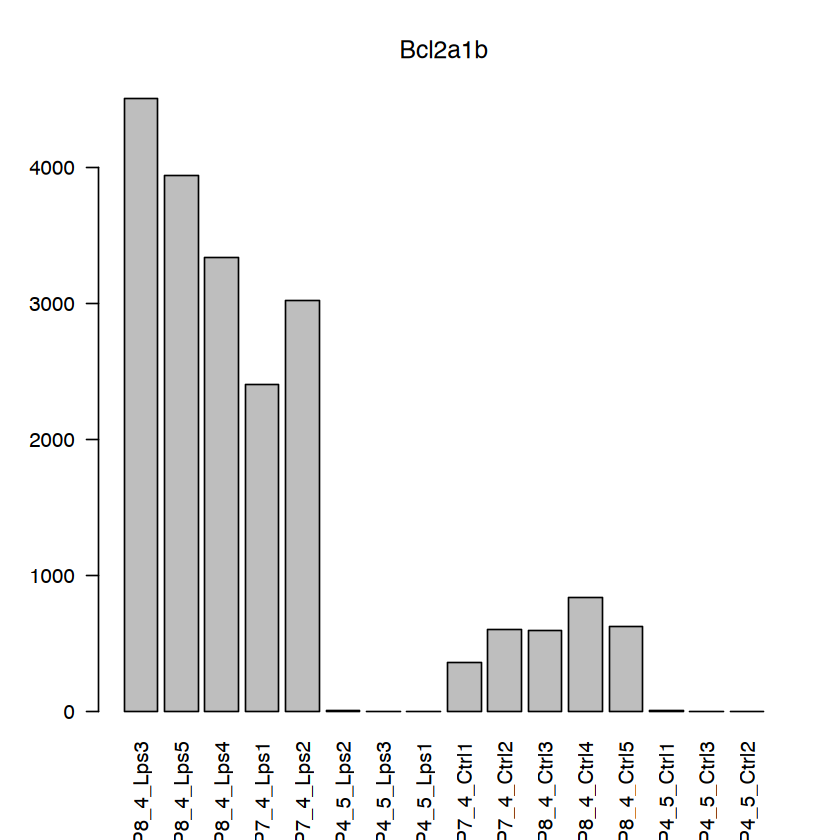

In [66]:
p <- barplot(assay(dds)[ix,],las=2, main=rownames(dds)[ ix  ]  )
#the plot below shows which gene is most prominent and how much it is expressed in each sample.

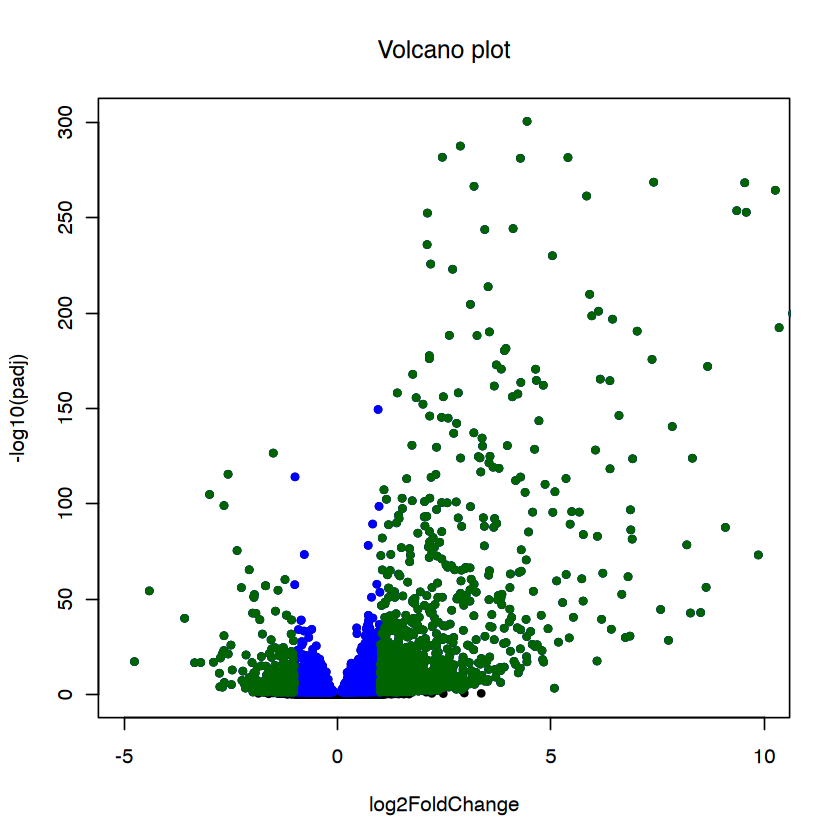

In [67]:
res2 <- res
#reset par
par(mfrow=c(1,1))
# Make a basic volcano plot
with(res2, plot(log2FoldChange, -log10(padj), pch=20, main="Volcano plot", xlim=c(-5,10)))

# Add colored points: blue if padj<0.05, red if log2FC>1 and padj<0.05)
with(subset(res2, padj<.05 ), points(log2FoldChange, -log10(padj), pch=20, col="blue"))
with(subset(res2, padj<.05 & abs(log2FoldChange)>1), points(log2FoldChange, -log10(padj), pch=20, col="dark green"))

In [68]:
#omit null values and only consider entries where adjusted p-value < 0.05.
res2 <- na.omit(res2)
mef_I <- res2
res2_I <- res2[res2$padj < 0.05, ]
res2_I_all <- res2

Warning message:
"One or more p-values is 0. Converting to 10^-1 * current lowest non-zero p-value..."


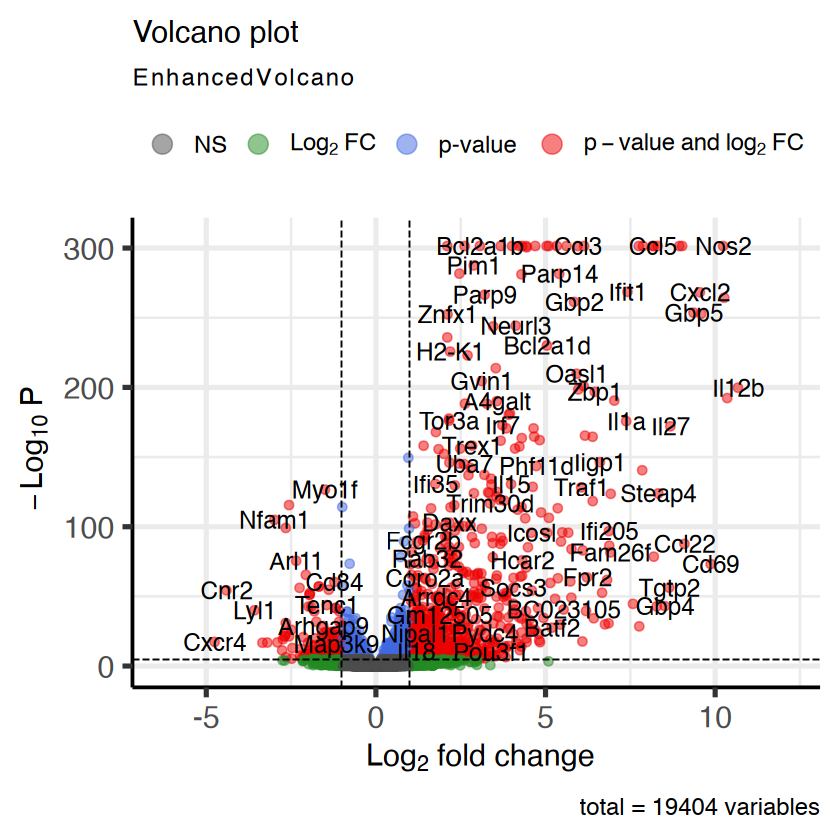

In [69]:
# Number of genes to label
N <- 5  

# Sorting the data frame based on the criteria (e.g., padj)
sorted_indices <- order(res2$padj)

# Initializing labels to NA
res2$labels <- NA

# Select top N genes based on sorted indices
top_N_indices <- sorted_indices[1:N]
filtered_indices <- top_N_indices[grepl("^Gm|-ik$|Mir|^Rps", res2$SYMBOL[top_N_indices])]
num_more <- length(filtered_indices)
next_valid_indices <- sorted_indices[(N + 1):(N + num_more)]
next_valid_indices <- next_valid_indices[!grepl("^Gm|-ik$|Mir|^Rps", res2$SYMBOL[next_valid_indices])]

# Combining the valid top indices and the next valid indices to get top N labels
final_top_N_indices <- c(setdiff(top_N_indices, filtered_indices), next_valid_indices[1:num_more])

# Filtering out NA indices
final_top_N_indices <- final_top_N_indices[!is.na(final_top_N_indices)]
final_top_N_indices <- final_top_N_indices[!is.na(res2$SYMBOL[final_top_N_indices])]

# Checking if any of the final_top_N_indices are NA or if corresponding SYMBOLs are NA
if (any(is.na(final_top_N_indices)) || any(is.na(res2$SYMBOL[final_top_N_indices]))) {
    stop("NA indices detected. Please resolve before proceeding.")
}

# Setting the labels for these final top N indices
res2$labels[final_top_N_indices] <- res2$SYMBOL[final_top_N_indices]

# Creating the EnhancedVolcano plot
EnhancedVolcano(res2,
                lab = rownames(res2),
                x = 'log2FoldChange',
                y = 'padj')


Here above plot suggests upregulated genes(positive Foldchange values) and downregulated genes(negative Foldchange values) in wildtype samples when subjected to LPS treatment.

In [70]:
#Finding DE genes with adjusted p-value < 0.05 and LFC threshold = 0.20 and saving as csv files.

In [71]:
res3 <- res2[complete.cases(res2),]
res3$abs_LFC <- abs(res3$log2FoldChange)
res4 <- res3[res3$abs_LFC > 1, ]
res5 <- res4[res4$padj < 0.05, ]  

res2_I_up <- res2[res2$log2FoldChange > 1 & res2$padj < 0.05, ]
res2_I_down <- res2[res2$log2FoldChange < -1 & res2$padj < 0.05, ]

In [72]:
res2_I$abs_LFC <- abs(res2_I$log2FoldChange)
res2_I_sig <- res2_I[res2_I$abs_LFC > 1, ]
res2_I_sig

log2 fold change (MLE): condition LPS vs Control 
Wald test p-value: condition LPS vs Control 
DataFrame with 1223 rows and 7 columns
               baseMean log2FoldChange     lfcSE      stat     pvalue      padj
              <numeric>      <numeric> <numeric> <numeric>  <numeric> <numeric>
Bcl2a1b         1169.98        3.06428 0.0815532   37.5740          0         0
Ccl3            4035.52        5.94632 0.0897479   66.2558          0         0
Ccl4            2385.70        5.62034 0.0852013   65.9654          0         0
Ccl5            2193.68        8.15856 0.1956929   41.6906          0         0
Clec4e          1711.19        7.74777 0.1459524   53.0842          0         0
...                 ...            ...       ...       ...        ...       ...
Pak7            4.17286       -1.43537  0.555976  -2.58172 0.00983098 0.0491018
Selenbp1       80.23607       -1.26987  0.492018  -2.58094 0.00985306 0.0491867
Doc2b          37.67114       -1.20351  0.466517  -2.57977 0.00988

In [73]:
write.csv(res2_I,'results_DEgenes_MEF_I_2020counts_v1.csv')
write.csv(rownames(res2_I_up),'upregulated_genes_MEF_I.csv')
write.csv(rownames(res2_I_down),'downregulated_genes_MEF_I.csv')

write.csv(res2_I_up,'upregulated_genes_MEF_I_rf.csv')
write.csv(res2_I_down,'downregulated_genes_MEF_I_rf.csv')

Warning message:
"One or more p-values is 0. Converting to 10^-1 * current lowest non-zero p-value..."


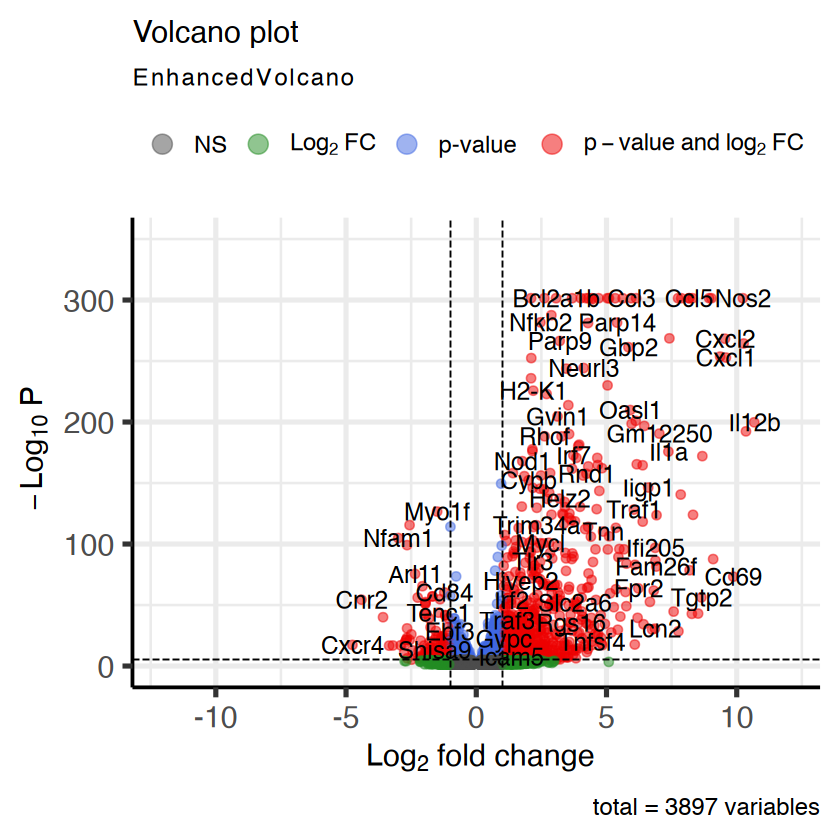

In [74]:
# Number of genes to label
N <- 5  

# Sorting the data frame based on the criteria (e.g., padj)
sorted_indices <- order(res2_I$padj)

# Initializing labels to NA if the 'labels' column doesn't exist
if (!"labels" %in% colnames(res2_I)) {
  res2_I$labels <- NA  # Fixed typo here; changed res5 to res2_I
}

# Selecting top N genes based on sorted indices
top_N_indices <- sorted_indices[1:N]

# Identifying those among the top N that need to be filtered out
filtered_indices <- top_N_indices[grepl("^Gm|-ik$|Mir|^Rpl", res2_I$SYMBOL[top_N_indices])]
num_more <- length(filtered_indices)
next_valid_indices <- sorted_indices[(N + 1):(N + num_more)]
next_valid_indices <- next_valid_indices[!grepl("^Gm|-ik$|Mir|^Rpl", res2_I$SYMBOL[next_valid_indices])]
final_top_N_indices <- c(setdiff(top_N_indices, filtered_indices), next_valid_indices[1:num_more])

# Checking if 'labels' column exists in res2_I before assigning labels
if ("labels" %in% colnames(res2_I)) {
  # Set the labels for these final top N indices, avoiding NA indices
  non_na_indices <- final_top_N_indices[!is.na(res2_I$SYMBOL[final_top_N_indices])]
  res2_I$labels[non_na_indices] <- res2_I$SYMBOL[non_na_indices]
} else {
  cat("The 'labels' column does not exist in res2_I.\n")
}

# Creating the EnhancedVolcano plot using res2_I and its labels
EnhancedVolcano(res2_I,
                lab = rownames(res2_I),
                x = 'log2FoldChange',
                y = 'padj',xlim = c(-12,12),ylim = c(0,350))


II.The effect of treatment in mutant samples [This is for Sp3 knockout,treated compared with untreated ]   


3.Genes upregulated with LPS in Sp3 knockout samples

4.Genes downregulated with LPS in Sp3 knockout samples


In [75]:
res <- results(dds,list(c("condition_LPS_vs_Control","genotypemut.conditionLPS") ))
ix = which.min(res$padj) # most significant
res <- res[order(res$padj),] # sort
kable(res[1:5,-(3:4)])



|       | baseMean| log2FoldChange| pvalue| padj|
|:------|--------:|--------------:|------:|----:|
|Neurl3 | 1396.644|       5.227313|      0|    0|
|Cxcl1  | 7935.192|       8.330495|      0|    0|
|Nos2   | 2629.325|       6.200872|      0|    0|
|Gbp2   | 6562.313|       4.816823|      0|    0|
|Nfkbia | 4246.507|       3.396784|      0|    0|

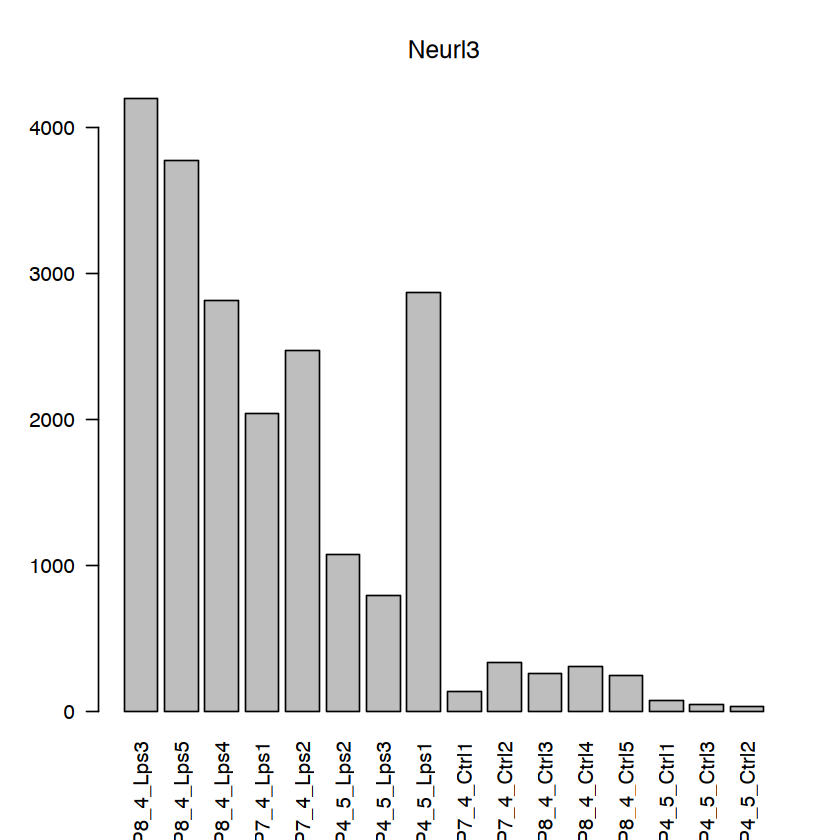

In [76]:
barplot(assay(dds)[ix,],las=2, main=rownames(dds)[ ix  ]  )

In [77]:
res2 <- res
res2 <- na.omit(res2)
mef_II <- res2

In [78]:
#filtering entries where adjusted p-value < 0.05 

res2_II <- res2[res2$padj < 0.05, ]
res2_II_all <- res2

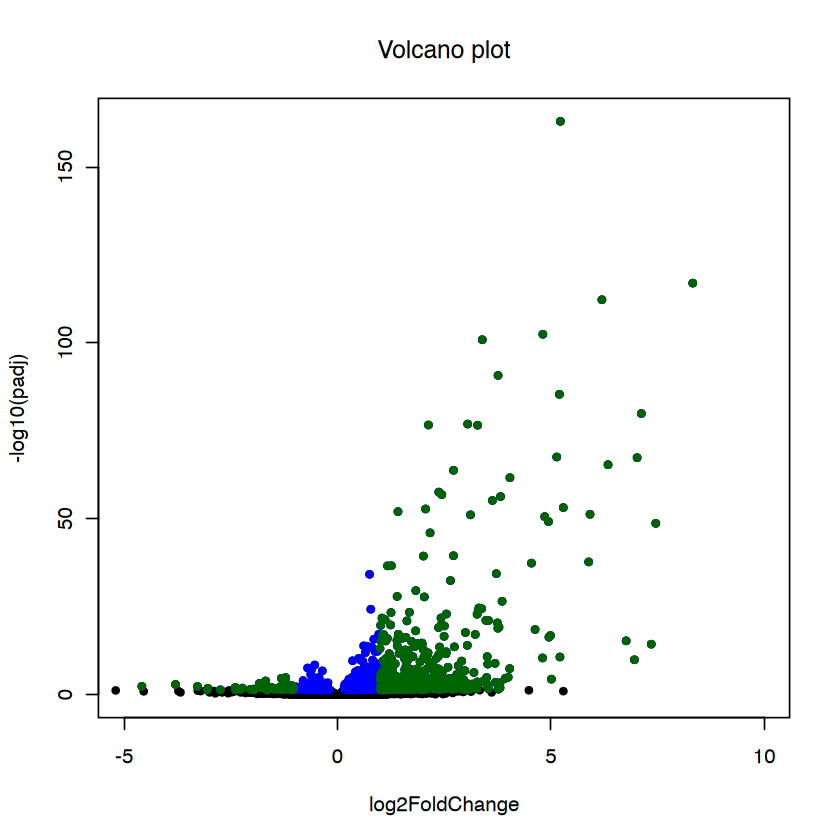

In [79]:
#reset par
par(mfrow=c(1,1))
with(res2, plot(log2FoldChange, -log10(padj), pch=20, main="Volcano plot", xlim=c(-5,10)))
# Add colored points: blue if padj<0.05, red if log2FC>1 and padj<0.05)
with(subset(res2, padj<.05 ), points(log2FoldChange, -log10(padj), pch=20, col="blue"))
with(subset(res2, padj<.05 & abs(log2FoldChange)>1), points(log2FoldChange, -log10(padj), pch=20, col="dark green"))

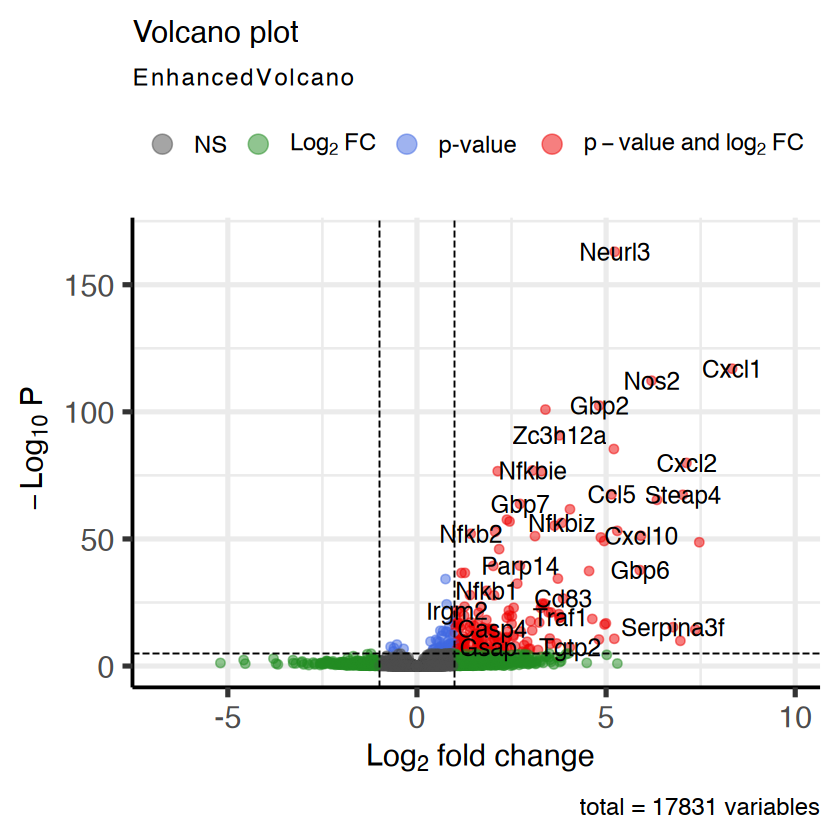

In [80]:
# Number of genes to label
N <- 10  

# Sorting the data frame based on the criteria (e.g., padj)
sorted_indices <- order(res2$padj)

# Initializing labels to NA
res2$labels <- NA

# Selecting top N genes based on sorted indices
top_N_indices <- sorted_indices[1:N]

# Identifying those among the top N that need to be filtered out
filtered_indices <- top_N_indices[grepl("^Gm|-ik$|Mir", res2$SYMBOL[top_N_indices])]
num_more <- length(filtered_indices)
next_valid_indices <- sorted_indices[(N + 1):(N + num_more)]
next_valid_indices <- next_valid_indices[!grepl("^Gm|-ik$|Mir", res2$SYMBOL[next_valid_indices])]
final_top_N_indices <- c(setdiff(top_N_indices, filtered_indices), next_valid_indices[1:num_more])
final_top_N_indices <- final_top_N_indices[!is.na(final_top_N_indices)]
final_top_N_indices <- final_top_N_indices[!is.na(res2$SYMBOL[final_top_N_indices])]

# Checking if any of the final_top_N_indices are NA or if corresponding SYMBOLs are NA
if (any(is.na(final_top_N_indices)) || any(is.na(res2$SYMBOL[final_top_N_indices]))) {
    stop("NA indices detected. Please resolve before proceeding.")
}

# Setting the labels for these final top N indices
res2$labels[final_top_N_indices] <- res2$SYMBOL[final_top_N_indices]

# Creating the EnhancedVolcano plot
EnhancedVolcano(res2,
                lab = rownames(res2),
                x = 'log2FoldChange',
                y = 'padj')


Here above plot suggests upregulated genes(positive Foldchange) and downregulated genes(negative Foldchange) in mutant samples when subjected to LPS treatment

In [81]:
res3 <- res2[complete.cases(res2),]
res2_I_full <- res3
res3$abs_LFC <- abs(res3$log2FoldChange)
res4 <- res3[res3$abs_LFC > 0.20, ]
res5 <- res4[res4$padj < 1, ]  

res2_II_up <- res2[res2$log2FoldChange > 1 & res2$padj < 0.05, ]
res2_II_down <- res2[res2$log2FoldChange < -1 & res2$padj < 0.05, ]

write.csv(res2_II,'results_DEgenes_MEF_II_2020counts_v1.csv')
write.csv(rownames(res2_II_up),'upregulated_genes_MEF_II.csv')
write.csv(rownames(res2_II_down),'downregulated_genes_MEF_II.csv')


write.csv(res2_II_up,'upregulated_genes_MEF_II_rf.csv')
write.csv(res2_II_down,'downregulated_genes_MEF_II_rf.csv')


In [82]:
res2_II$abs_LFC <- abs(res2_II$log2FoldChange)
res2_II_sig <- res2_II[res2_II$abs_LFC > 1, ]
res2_II_sig

log2 fold change (MLE): condition_LPS_vs_Control+genotypemut.conditionLPS effect 
Wald test p-value: condition_LPS_vs_Control+genotypemut.conditionLPS effect 
DataFrame with 418 rows and 7 columns
          baseMean log2FoldChange     lfcSE      stat       pvalue         padj
         <numeric>      <numeric> <numeric> <numeric>    <numeric>    <numeric>
Neurl3     1396.64        5.22731  0.189235   27.6234 5.82091e-168 1.03793e-163
Cxcl1      7935.19        8.33050  0.355147   23.4565 1.13573e-121 1.01256e-117
Nos2       2629.33        6.20087  0.269945   22.9709 9.11894e-117 5.42000e-113
Gbp2       6562.31        4.81682  0.219402   21.9543 7.88046e-107 3.51291e-103
Nfkbia     4246.51        3.39678  0.155952   21.7810 3.51635e-105 1.25400e-101
...            ...            ...       ...       ...          ...          ...
Cldn15     34.3178        1.41302  0.465483   3.03560   0.00240058    0.0477198
Mcc      1193.4357        1.09311  0.360153   3.03513   0.00240429    0.0477405
Irs

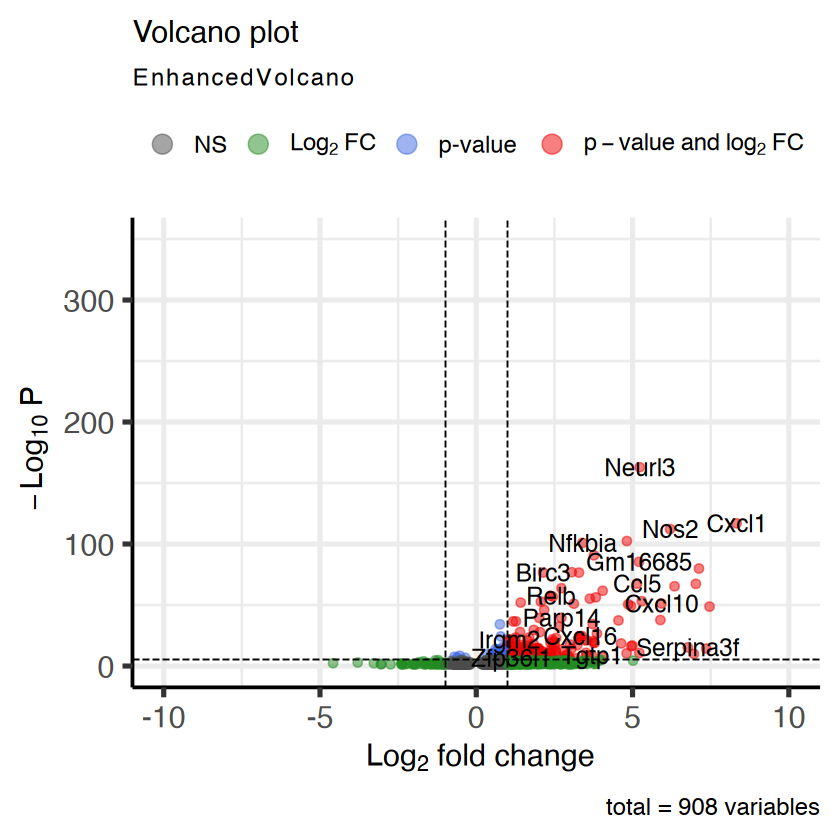

In [83]:
# Number of genes to label
N <- 10  

# Sorting the data frame based on the criteria (e.g., padj)
sorted_indices <- order(res2_II$padj)

# Initializing labels to NA if the 'labels' column doesn't exist
if (!"labels" %in% colnames(res2_II)) {
  res2_II$labels <- NA  # Changed res2_I to res2_II
}

# Selecting top N genes based on sorted indices
top_N_indices <- sorted_indices[1:N]

# Identifying those among the top N that need to be filtered out
filtered_indices <- top_N_indices[grepl("^Gm|Rik$|Mir", res2_II$SYMBOL[top_N_indices])]  # Changed res2_I to res2_II

num_more <- length(filtered_indices)
next_valid_indices <- sorted_indices[(N + 1):(N + num_more)]
next_valid_indices <- next_valid_indices[!grepl("^Gm|Rik$|Mir", res2_II$SYMBOL[next_valid_indices])]  # Changed res2_I to res2_II
final_top_N_indices <- c(setdiff(top_N_indices, filtered_indices), next_valid_indices[1:num_more])

# Checking if 'labels' column exists in res2_II before assigning labels
if ("labels" %in% colnames(res2_II)) {  # Changed res2_I to res2_II
  # Set the labels for these final top N indices, avoiding NA indices
  non_na_indices <- final_top_N_indices[!is.na(res2_II$SYMBOL[final_top_N_indices])]  # Changed res2_I to res2_II
  res2_II$labels[non_na_indices] <- res2_II$SYMBOL[non_na_indices]  # Changed res2_I to res2_II
} else {
  cat("The 'labels' column does not exist in res2_II.\n")  # Changed res2_I to res2_II
}

# Creating the EnhancedVolcano plot using res2_II and its labels
EnhancedVolcano(res2_II,  # Changed res2_I to res2_II
                lab = rownames(res2_II),  # Changed res2_I to res2_II
                x = 'log2FoldChange',
                y = 'padj',ylim = c(0,350),xlim = c(-10,10))


In [84]:
lmc_data <- read.csv('merged_LMC_I_II_III_deseq2results.csv')

In [85]:
lmc_data$X <- NULL

In [86]:
res = results(dds, contrast=c("genotype","mut","wt"))
ix = which.min(res$padj) # most significant
res <- res[order(res$padj),] # sort
kable(res[1:5,-(3:4)])



|       |  baseMean| log2FoldChange| pvalue| padj|
|:------|---------:|--------------:|------:|----:|
|Mpeg1  | 5590.2821|      -8.921650|      0|    0|
|Xist   | 9450.0934|       9.862630|      0|    0|
|Laptm5 | 2621.6106|      -7.952874|      0|    0|
|Cd84   |  760.7402|      -5.430426|      0|    0|
|Tbx4   |  463.9069|       7.077411|      0|    0|

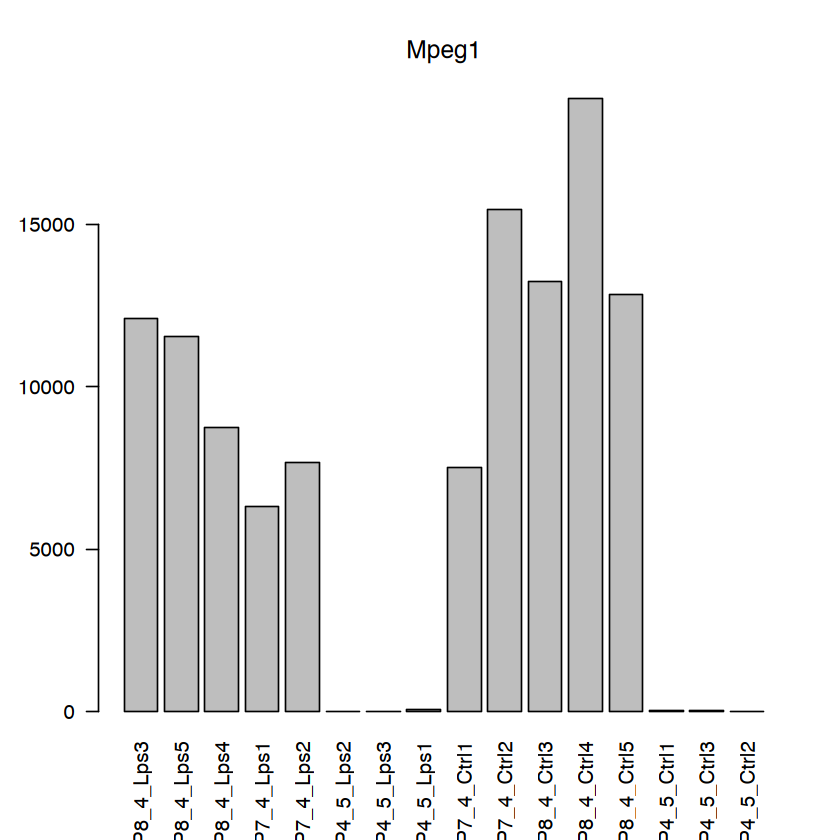

In [87]:
barplot(assay(dds)[ix,],las=2, main=rownames(dds)[ ix  ]  )

In [88]:
res2 <- res
res2 <- na.omit(res2)
mef_III <- res2

In [89]:
res2_III <- res2[res2$padj < 0.05, ]
res2_III_all <- res2

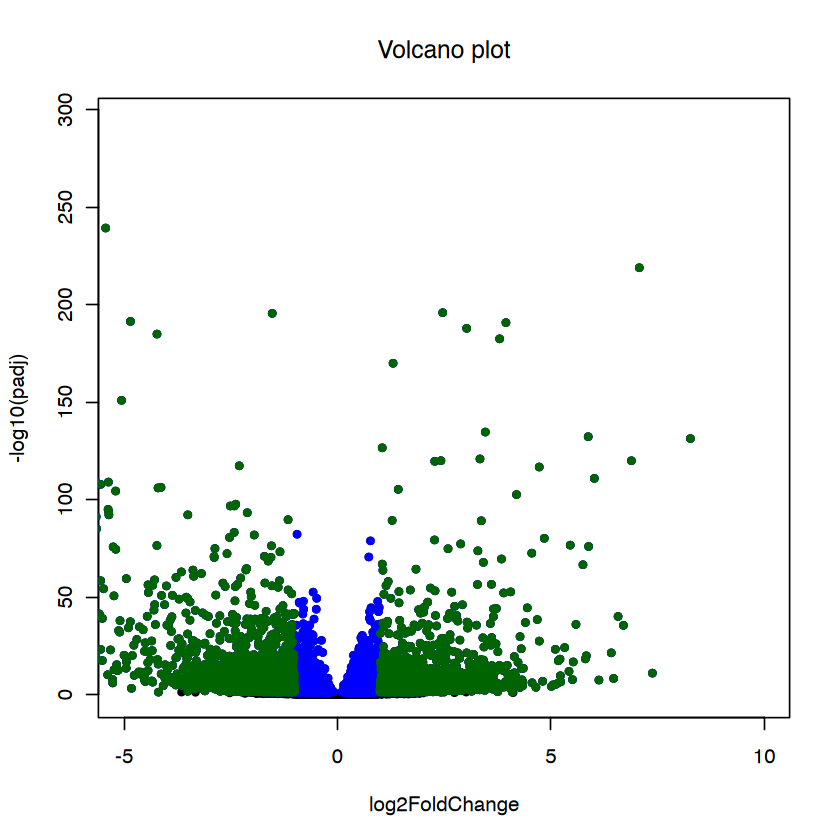

In [90]:
#reset par
par(mfrow=c(1,1))
with(res2, plot(log2FoldChange, -log10(padj), pch=20, main="Volcano plot", xlim=c(-5,10)))

# Add colored points: blue if padj<0.05, red if log2FC>1 and padj<0.05)
with(subset(res2, padj<.05 ), points(log2FoldChange, -log10(padj), pch=20, col="blue"))
with(subset(res2, padj<.05 & abs(log2FoldChange)>1), points(log2FoldChange, -log10(padj), pch=20, col="dark green"))

Warning message:
"One or more p-values is 0. Converting to 10^-1 * current lowest non-zero p-value..."


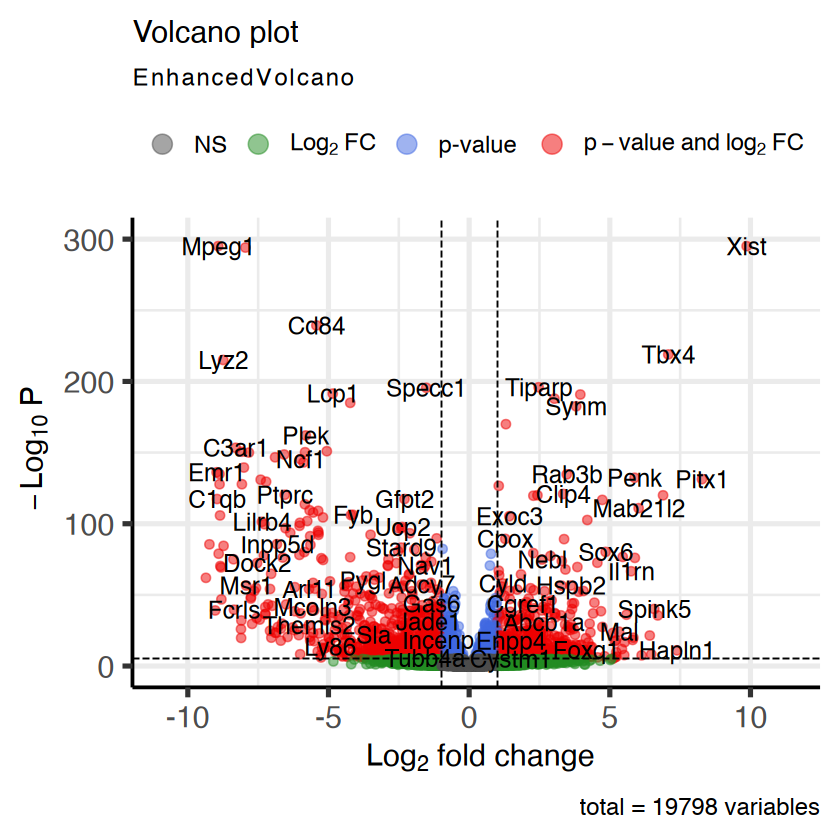

In [91]:
# Number of genes to label
N <- 10  

# Sorting the data frame based on the criteria (e.g., padj)
sorted_indices <- order(res2$padj)

# Initializing labels to NA
res2$labels <- NA

# Selecting top N genes based on sorted indices
top_N_indices <- sorted_indices[1:N]

# Identifying those among the top N that need to be filtered out
filtered_indices <- top_N_indices[grepl("^Gm|Rik$|Mir|^Rpl", res2$SYMBOL[top_N_indices])]

# Identifying how many more genes we need to pick
num_more <- length(filtered_indices)

# Picking the next top-most genes that are valid
next_valid_indices <- sorted_indices[(N + 1):(N + num_more)]
next_valid_indices <- next_valid_indices[!grepl("^Gm|Rik$|Mir|^Rpl", res2$SYMBOL[next_valid_indices])]

# Combining the valid top indices and the next valid indices to get top N labels
final_top_N_indices <- c(setdiff(top_N_indices, filtered_indices), next_valid_indices[1:num_more])

# Filtering out NA indices
final_top_N_indices <- final_top_N_indices[!is.na(final_top_N_indices)]
final_top_N_indices <- final_top_N_indices[!is.na(res2$SYMBOL[final_top_N_indices])]

# Checking if any of the final_top_N_indices are NA or if corresponding SYMBOLs are NA
if (any(is.na(final_top_N_indices)) || any(is.na(res2$SYMBOL[final_top_N_indices]))) {
    stop("NA indices detected. Please resolve before proceeding.")
}

# Setting the labels for these final top N indices
res2$labels[final_top_N_indices] <- res2$SYMBOL[final_top_N_indices]

# Creating the EnhancedVolcano plot
EnhancedVolcano(res2,
                lab = rownames(res2),
                x = 'log2FoldChange',
                y = 'padj')


Here above results suggest upregulated genes(positive Foldchange) and downregulated genes(negative Foldchange)in
Wildtype samples compared to mutant without considering control/LPS treatment.


In [92]:
res3 <- res2[complete.cases(res2),]
res2_II_full <- res3
res3$abs_LFC <- abs(res3$log2FoldChange)
res4 <- res3[res3$abs_LFC > 0.20, ]
res5 <- res4[res4$padj < 0.05, ]  


res3_up <- res2[res2$log2FoldChange > 1 & res2$padj < 0.05, ]
res3_down <- res2[res2$log2FoldChange < -1 & res2$padj < 0.05, ]

write.csv(res2_III,'MEF_III_DEgenes.csv')
write.csv(rownames(res3_up),'upregulated_genes_MEF_III.csv')
write.csv(rownames(res3_down),'downregulated_genes_MEF_III.csv')


write.csv(res3_up,'upregulated_genes_MEF_III_rf.csv')
write.csv(res3_down,'downregulated_genes_MEF_III_rf.csv')

res3_up_v <- res2[res2$log2FoldChange > 0 & res2$padj < 0.05, ]
res3_down_v <- res2[res2$log2FoldChange < 0 & res2$padj < 0.05, ]

write.csv(rownames(res3_up_v),'upregulated_genes_MEF_III_venndiagram.csv')
write.csv(rownames(res3_down_v),'downregulated_genes_MEF_III_venndiagram.csv')

In [93]:
# Load required packages
library(plotly)
library(htmltools)

DE_results <- res2_III
# Ensure gene names are uppercase
rownames(countData2) <- toupper(rownames(countData2))
rownames(DE_results) <- toupper(rownames(DE_results))

# Filter to only genes present in countData1
gene_list <- rownames(DE_results)
gene_list <- gene_list[gene_list %in% rownames(countData2)]

# Subset countData1 accordingly
countData3 <- countData2[gene_list, , drop = FALSE]

# Extract sample metadata
sample_ids <- colnames(countData3)
Group <- groups
Genotype <- ifelse(grepl("wt", Group, ignore.case = TRUE), "WT", "MUT")
Condition <- ifelse(grepl("Control", Group, ignore.case = TRUE), "Control", "LPS")

In [94]:
res2_III_hmap <- res2_III
res2_III_hmap$abs_LFC <- abs(res2_III$log2FoldChange)
res2_III_hmap <- res2_III_hmap[res2_III_hmap$abs_LFC > 2, ]
#res2_III_hmap <- res2_III_hmap[res2_III_hmap$abs_LFC > 3, ]

In [95]:
columns_without_LPS <- !grepl("Lps", names(countData1))

# Select only those columns
countData1_onlycontrol <- countData1[, columns_without_LPS]

In [96]:
MEF_DEgenes_III <- intersect(rownames(countData1_onlycontrol), rownames(res2_III_hmap))

[1] 1222

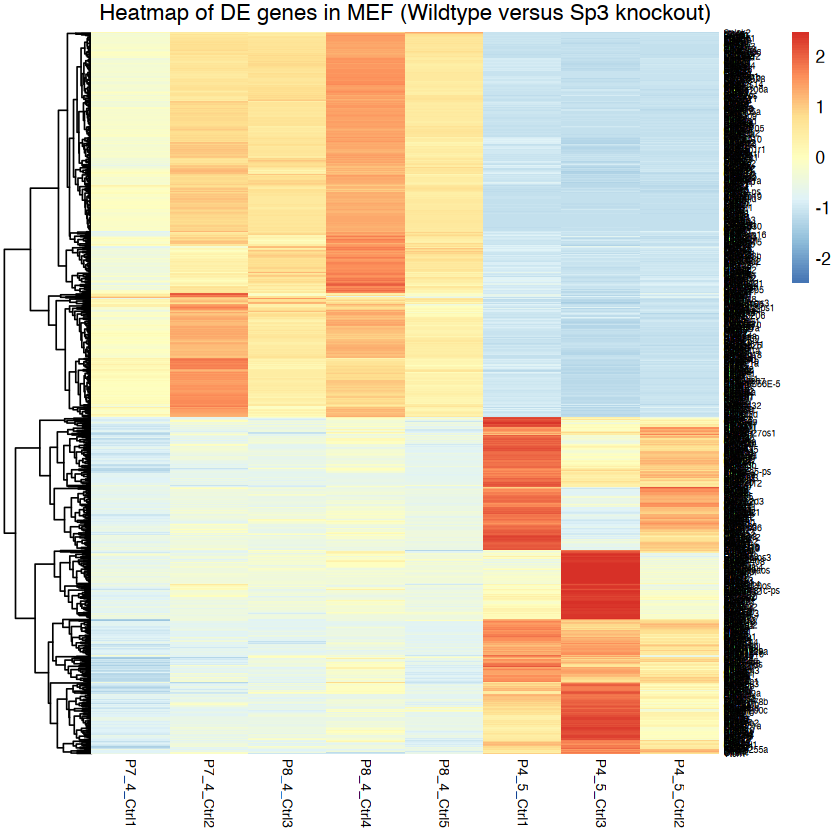

In [97]:
filtered_countdata <- countData1_onlycontrol[MEF_DEgenes_III, ]
nrow(filtered_countdata)
filtered_countdata_matrix <- as.matrix(filtered_countdata)

# Define the pattern to remove unwanted genes
pattern <- "^(Gm|MIR|ENSMUS|Rpl)|Rik$|^[A-Z]+$|\\."
rows_to_keep <- grep(pattern, rownames(filtered_countdata_matrix), invert = TRUE, ignore.case = TRUE)

# Further filter to keep only the first 500 after removing unwanted genes
filtered_matrix <- filtered_countdata_matrix[rows_to_keep, ]

# Save the filtered matrix to CSV
write.csv(filtered_matrix, "filter_MEF.csv")

# Generate heatmap and extract clustering information, reducing font size
heatmap_result <- pheatmap(filtered_matrix, 
                           scale = "row",
                           cluster_cols = FALSE, # Do not cluster columns
                           show_rownames = TRUE,
                           show_colnames = TRUE,
                           main = "Heatmap of DE genes in MEF (Wildtype versus Sp3 knockout)",
                           fontsize_row = 5,   # Adjust row label font size
                           fontsize_col = 8,   # Adjust column label font size
                           width = 20,         # Width of the plot in inches
                           height = 40)        # Height of the plot in inches

# Extract clustering order of rows
clustered_order <- heatmap_result$tree_row$order

# Reorder matrix according to clustering order
filtered_matrix_ordered <- filtered_matrix[clustered_order, ]

# Save reordered matrix to CSV
#write.csv(filtered_matrix_ordered, "filter_MEF_ordered.csv")




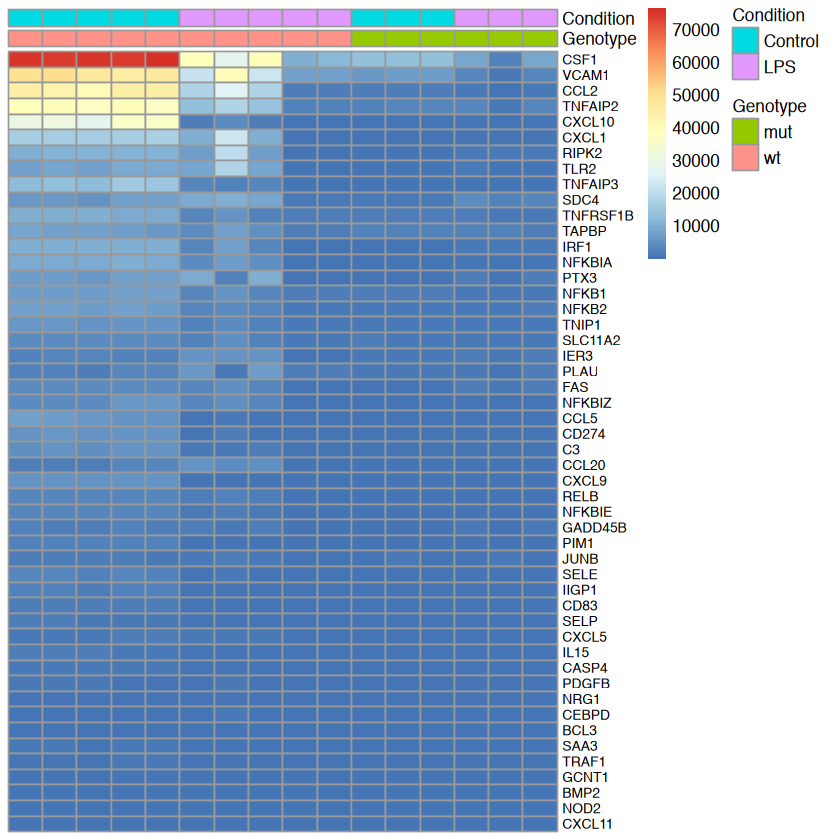

In [98]:

# Convert row names to uppercase to match case insensitivity
rownames(countData) <- toupper(rownames(countData))
rownames(res2_II_sig) <- toupper(rownames(res2_II_sig))
nf_kb$Gene_name <- toupper(nf_kb$Gene_name)  # Ensuring case consistency

common_genes_sig_II <- intersect(rownames(countData), rownames(res2_II_sig))


# Also intersect with nf_kb gene names
common_genes_nf_kb <- intersect(rownames(countData), nf_kb$Gene_name)

# Get the intersection of the two lists to find genes common in both
common_genes_final <- intersect(common_genes_sig_II, common_genes_nf_kb)

# Filter countData to include only rows that have genes present in both res2_I_sig and nf_kb
filteredCountData <- countData[common_genes_final, ]

# Further filter rows to exclude certain gene name prefixes
filtered_rows <- grep("^(?!GM|MIR|ENSMUS|RPL|RIK).*$", rownames(filteredCountData), perl = TRUE)
filteredCountDataFiltered <- filteredCountData[filtered_rows, ]

meanExpressionLevels <- rowMeans(filteredCountDataFiltered)

# Sort genes by mean expression levels in decreasing order and select the top 50
top50Genes <- names(sort(meanExpressionLevels, decreasing = TRUE))[1:50]

# Filter the data to include only these top 50 genes
top50FilteredData <- filteredCountDataFiltered[top50Genes, ]

# Plot the heatmap of the top 50 filtered countData
pheatmap(top50FilteredData,
         cluster_rows = FALSE,
         cluster_cols = FALSE,
         annotation_col = as.data.frame(manual_annotation),  # Ensure this is defined or modify as needed
         show_rownames = TRUE,
         show_colnames = FALSE,  # Hiding column names
       #  scale = "row",
         fontsize_row = 8)

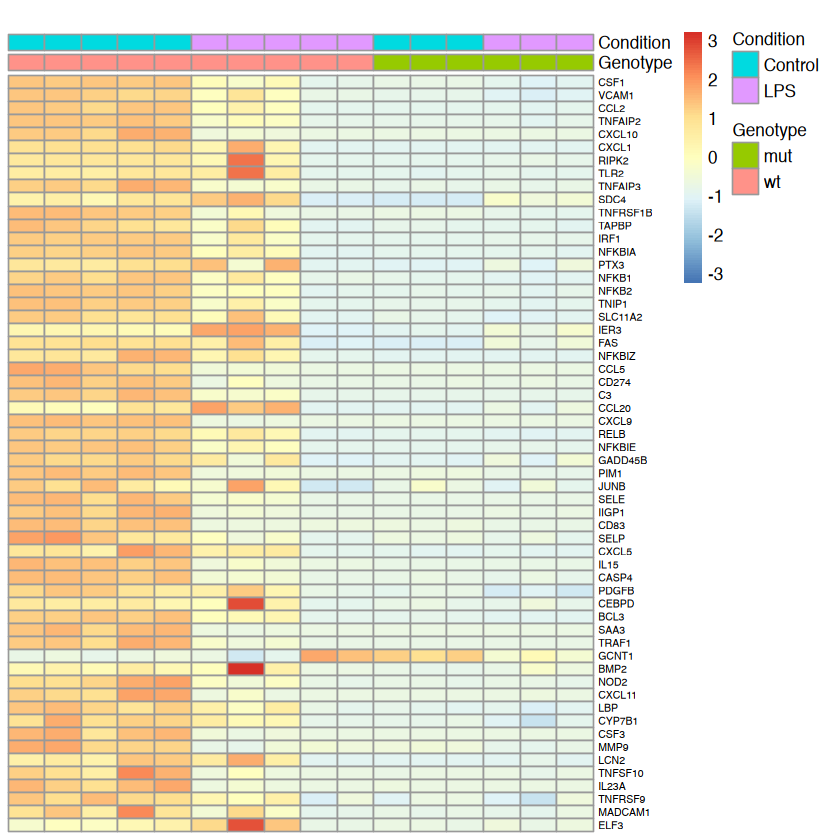

In [99]:

# Convert row names to uppercase to match case insensitivity
rownames(countData) <- toupper(rownames(countData))
rownames(res2_I_sig) <- toupper(rownames(res2_I_sig))
rownames(res2_II_sig) <- toupper(rownames(res2_II_sig))
nf_kb$Gene_name <- toupper(nf_kb$Gene_name)  # Ensuring case consistency

# Intersect gene names across different datasets
common_genes_I_sig <- intersect(rownames(countData), rownames(res2_I_sig))
common_genes_II_sig <- intersect(rownames(countData), rownames(res2_II_sig))
common_genes_nf_kb <- intersect(rownames(countData), nf_kb$Gene_name)

# Combine intersections to find genes common across all conditions
common_genes_final <- Reduce(intersect, list(common_genes_I_sig, common_genes_II_sig, common_genes_nf_kb))

# Filter countData to include only rows that have genes present in all intersections
filteredCountData <- countData[common_genes_final, ]

# Further filter rows to exclude certain gene name prefixes
filtered_rows <- grep("^(?!GM|MIR|ENSMUS|RPL|RIK).*$", rownames(filteredCountData), perl = TRUE)
filteredCountDataFiltered <- filteredCountData[filtered_rows, ]

# Calculate mean expression levels
meanExpressionLevels <- rowMeans(filteredCountDataFiltered)

# Sort genes by mean expression levels in decreasing order and select the top 50
top50Genes <- names(sort(meanExpressionLevels, decreasing = TRUE))#[1:50]

# Filter the data to include only these top 50 genes
top50FilteredData <- filteredCountDataFiltered[top50Genes, ]

# Optional: Define or calculate any specific annotation for columns if needed
# manual_annotation <- data.frame(Condition = c("Control", "Treatment"), row.names = colnames(top50FilteredData))



# Plot the heatmap of the top 50 filtered countData
pheatmap(top50FilteredData,
         cluster_rows = FALSE,
         cluster_cols = FALSE,
         annotation_col = as.data.frame(manual_annotation),  # Ensure this is defined or modify as needed
         show_rownames = TRUE,
         show_colnames = FALSE,  # Hiding column names
         scale = "row",
         fontsize_row = 6,
         main = "")

Warning message:
"One or more p-values is 0. Converting to 10^-1 * current lowest non-zero p-value..."


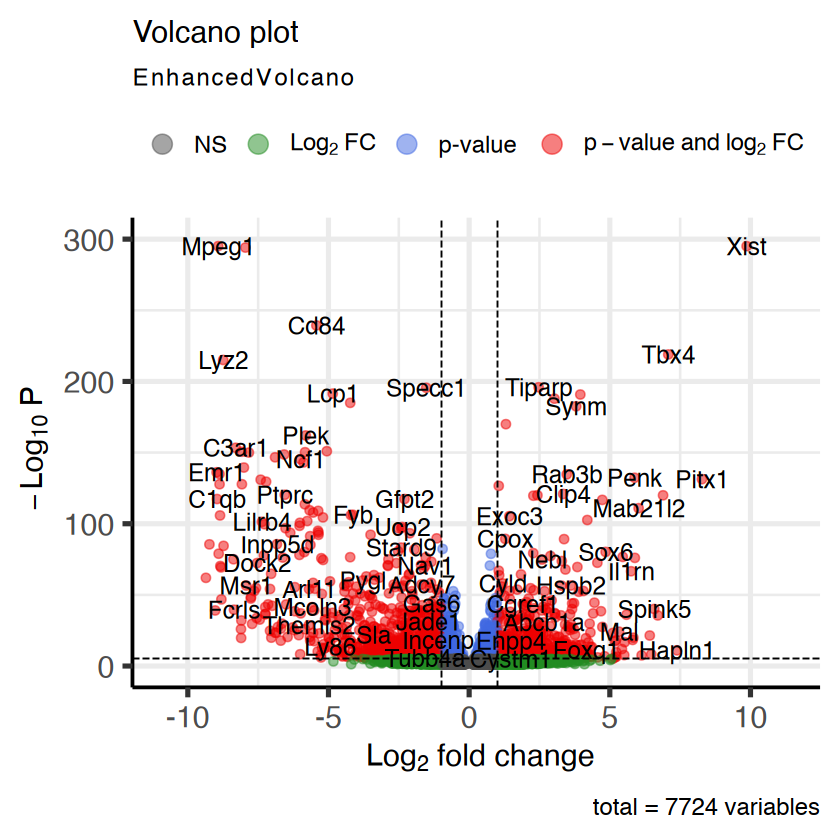

In [101]:
# Number of genes to label
N <- 10  

# Sorting the data frame based on the criteria (e.g., padj)
sorted_indices <- order(res2_III$padj)

# Initializing labels to NA
res2_III$labels <- NA

# Selecting top N genes based on sorted indices
top_N_indices <- sorted_indices[1:N]

# Identifying those among the top N that need to be filtered out
filtered_indices <- top_N_indices[grepl("^Gm|-ik$|Mir|^Rpl", res2_III$SYMBOL[top_N_indices])]

# Identifying how many more genes we need to pick
num_more <- length(filtered_indices)

# Picking the next top-most genes that are valid
next_valid_indices <- sorted_indices[(N + 1):(N + num_more)]
next_valid_indices <- next_valid_indices[!grepl("^Gm|-ik$|Mir|^Rpl", res2_III$SYMBOL[next_valid_indices])]

# Combining the valid top indices and the next valid indices to get top N labels
final_top_N_indices <- c(setdiff(top_N_indices, filtered_indices), next_valid_indices[1:num_more])

# Filtering out NA indices
final_top_N_indices <- final_top_N_indices[!is.na(final_top_N_indices)]
final_top_N_indices <- final_top_N_indices[!is.na(res2_III$SYMBOL[final_top_N_indices])]

# Checking if any of the final_top_N_indices are NA or if corresponding SYMBOLs are NA
if (any(is.na(final_top_N_indices)) || any(is.na(res2_III$SYMBOL[final_top_N_indices]))) {
    stop("NA indices detected. Please resolve before proceeding.")
}

# Setting the labels for these final top N indices
res2_III$labels[final_top_N_indices] <- res2_III$SYMBOL[final_top_N_indices]

# Creating the EnhancedVolcano plot
EnhancedVolcano(res2_III,
                lab = rownames(res2_III),
                x = 'log2FoldChange',
                y = 'padj')


In [102]:
res2_I_df <- data.frame(res2_I)
res2_II_df <- data.frame(res2_II)
res2_III_df <- data.frame(res2_III)

In [103]:
res2_I_full <- data.frame(res2_I_full)
res2_II_full <- data.frame(res2_II_full)

In [104]:
colnames(res2_II_full)

[1] "baseMean"       "log2FoldChange" "lfcSE"          "stat"          
[5] "pvalue"         "padj"           "labels"

In [105]:
lmc_data <- read.csv('merged_LMC_I_II_III_deseq2results.csv')

In [106]:
res2_I_df$gene <- rownames(res2_I_df)
res2_II_df$gene <- rownames(res2_II_df)


merged_data_mef <- merge(res2_I_df, res2_II_df, by="gene", suffixes = c("_I", "_II"))

res2_III_df <- data.frame(res2_III)
res2_III_df$gene <- rownames(res2_III_df)
mef_data <- merge(merged_data_mef, res2_III_df, by="gene", suffixes = c("", "_III"))


mef_data <- mef_data %>%
  rename_with(.fn = ~paste0(., "_III"), .cols = tail(names(mef_data), 6))



In [107]:
library(ggplot2)

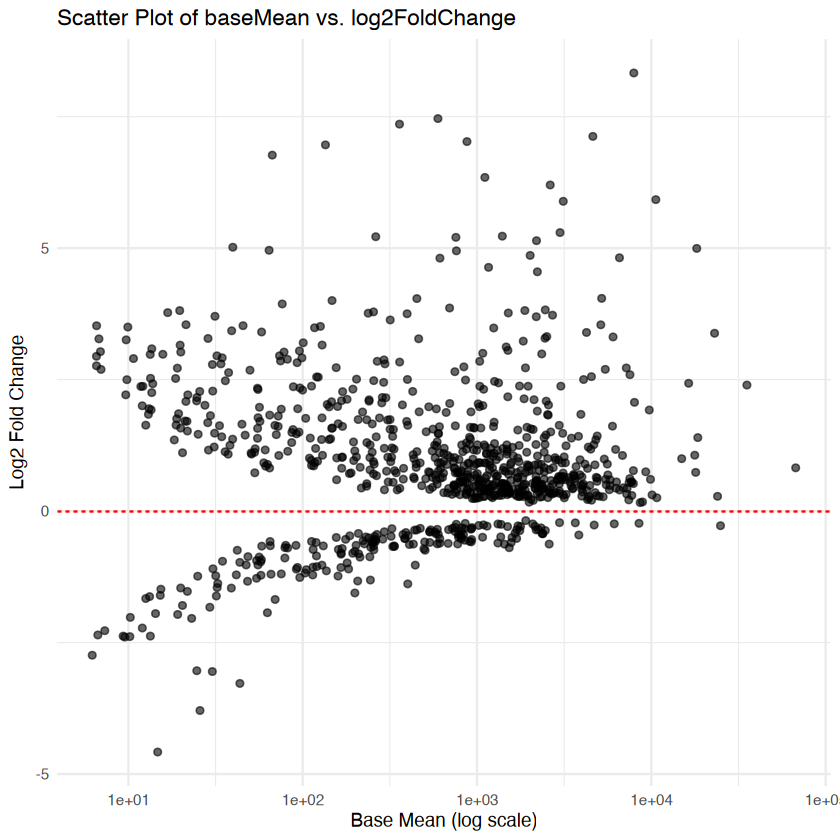

In [108]:
ggplot(res2_II_df, aes(x = baseMean, y = log2FoldChange)) +
  geom_point(alpha = 0.6) + # Set alpha for better visualization if points overlap
  scale_x_log10() + # Log-transform the baseMean axis for better visualization
  theme_minimal() +
  labs(x = "Base Mean (log scale)", 
       y = "Log2 Fold Change", 
       title = "Scatter Plot of baseMean vs. log2FoldChange") +
  geom_hline(yintercept = 0, linetype = "dashed", color = "red") # Add a horizontal line at y=0

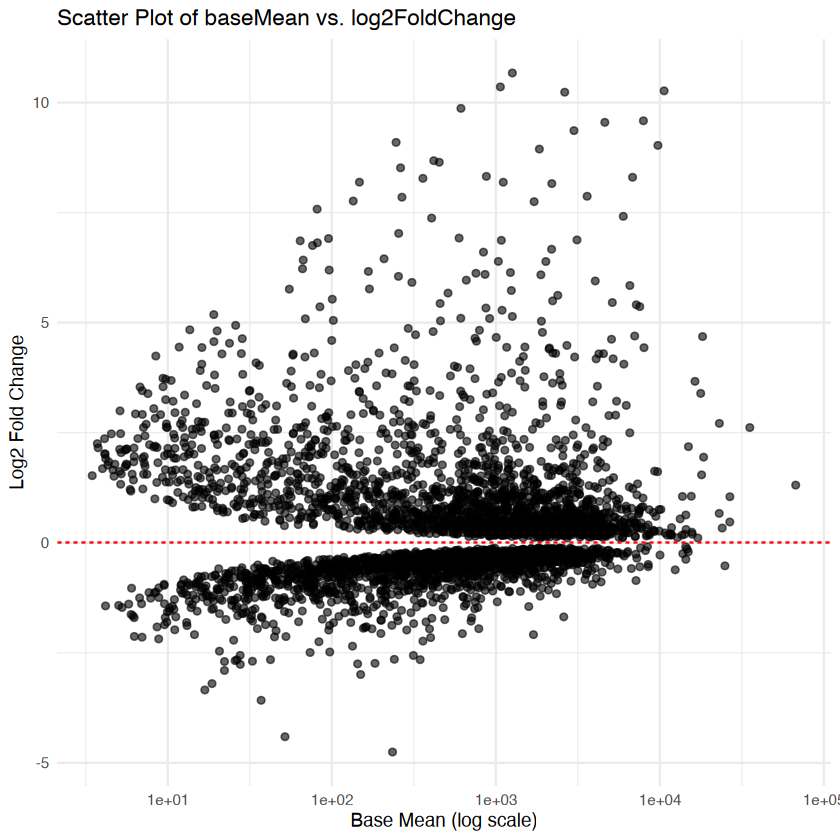

In [109]:
ggplot(res2_I_df, aes(x = baseMean, y = log2FoldChange)) +
  geom_point(alpha = 0.6) + # Set alpha for better visualization if points overlap
  scale_x_log10() + # Log-transform the baseMean axis for better visualization
  theme_minimal() +
  labs(x = "Base Mean (log scale)", 
       y = "Log2 Fold Change", 
       title = "Scatter Plot of baseMean vs. log2FoldChange") +
  geom_hline(yintercept = 0, linetype = "dashed", color = "red")

Warning message:
"No shared levels found between `names(values)` of the manual scale and the
data's colour values."


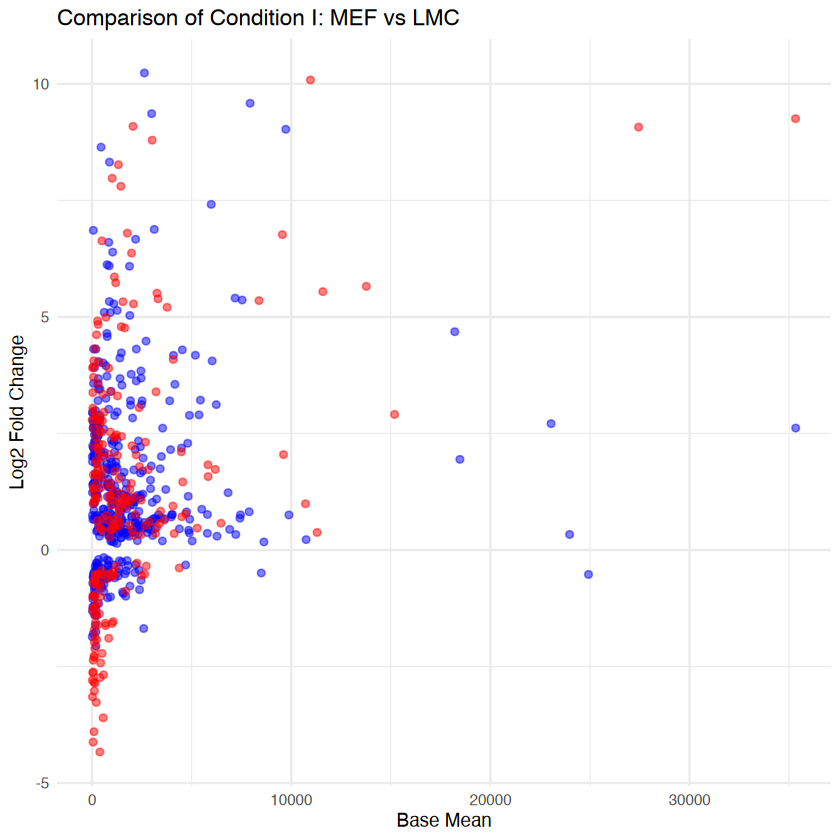

In [110]:
library(ggplot2)

# Assuming your datasets are read into data frames named `lmc_data` and `mef_data`
# You can read your data with something like:
# lmc_data <- read.csv("path_to_your_lmc_data_file.csv")
# mef_data <- read.csv("path_to_your_mef_data_file.csv")

# 1. Comparison of I conditions between lmc_data and mef_data
ggplot() +
  geom_point(data = mef_data, aes(x = baseMean_I, y = log2FoldChange_I), color = "blue", alpha = 0.5) +
  geom_point(data = lmc_data, aes(x = baseMean_I, y = log2FoldChange_I), color = "red", alpha = 0.5) +
  labs(title = "Comparison of Condition I: MEF vs LMC", x = "Base Mean", y = "Log2 Fold Change") +
  scale_color_manual(values = c("MEF" = "blue", "LMC" = "red")) +
  theme_minimal()



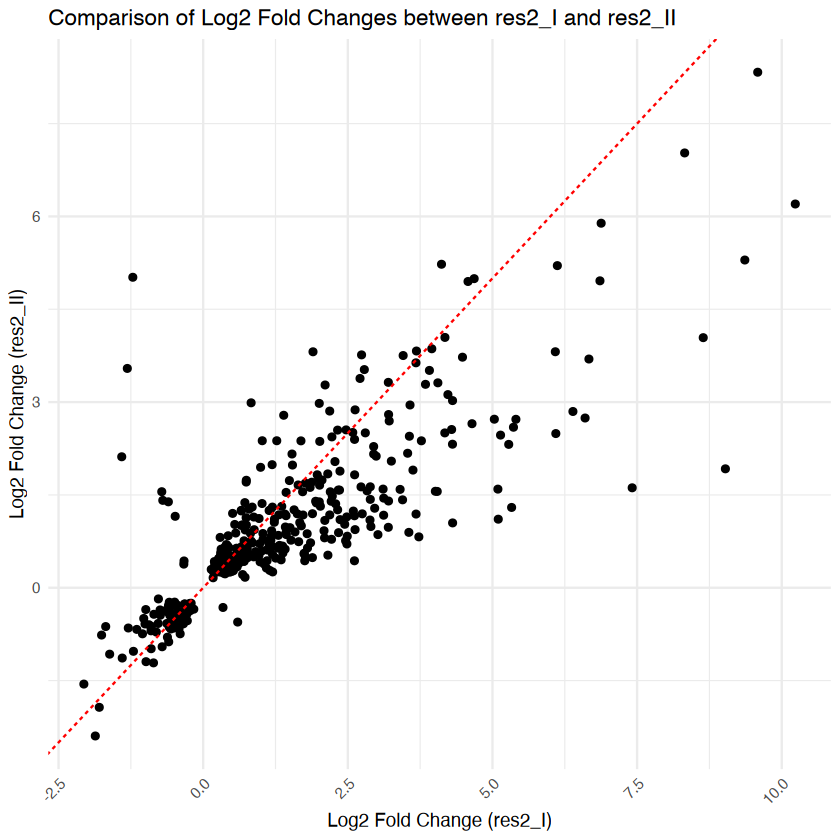

In [111]:
# Load necessary library for plotting
library(ggplot2)

# Plotting
ggplot(mef_data, aes(x = log2FoldChange_I, y = log2FoldChange_II)) +
  geom_point() +  # Add points
  geom_abline(intercept = 0, slope = 1, linetype = "dashed", color = "red") + # Add y=x line for reference
  theme_minimal() +  # Use a minimal theme
  labs(x = "Log2 Fold Change (res2_I)", y = "Log2 Fold Change (res2_II)", 
       title = "Comparison of Log2 Fold Changes between res2_I and res2_II") +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))  # Improve label readability

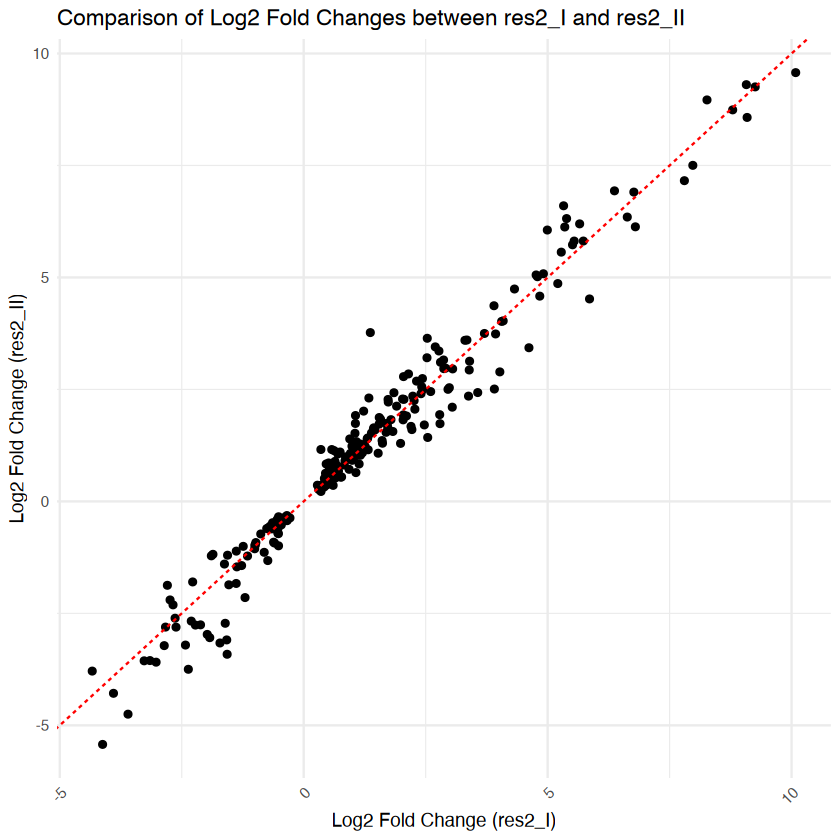

In [112]:
# Load necessary library for plotting
library(ggplot2)

# Plotting
ggplot(lmc_data, aes(x = log2FoldChange_I, y = log2FoldChange_II)) +
  geom_point() +  # Add points
  geom_abline(intercept = 0, slope = 1, linetype = "dashed", color = "red") + # Add y=x line for reference
  theme_minimal() +  # Use a minimal theme
  labs(x = "Log2 Fold Change (res2_I)", y = "Log2 Fold Change (res2_II)", 
       title = "Comparison of Log2 Fold Changes between res2_I and res2_II") +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))  # Improve label readability

Warning message:
"No shared levels found between `names(values)` of the manual scale and the
data's colour values."


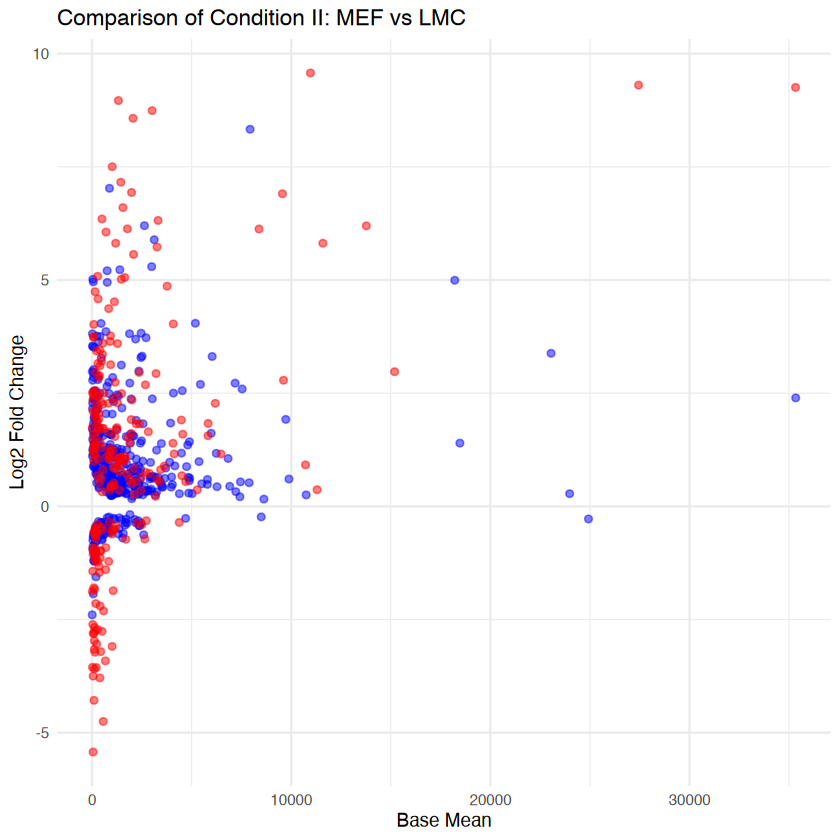

In [113]:
# 2. Comparison of II conditions between lmc_data and mef_data
ggplot() +
  geom_point(data = mef_data, aes(x = baseMean_II, y = log2FoldChange_II), color = "blue", alpha = 0.5) +
  geom_point(data = lmc_data, aes(x = baseMean_II, y = log2FoldChange_II), color = "red", alpha = 0.5) +
  labs(title = "Comparison of Condition II: MEF vs LMC", x = "Base Mean", y = "Log2 Fold Change") +
  scale_color_manual(values = c("MEF" = "blue", "LMC" = "red")) +
  theme_minimal()

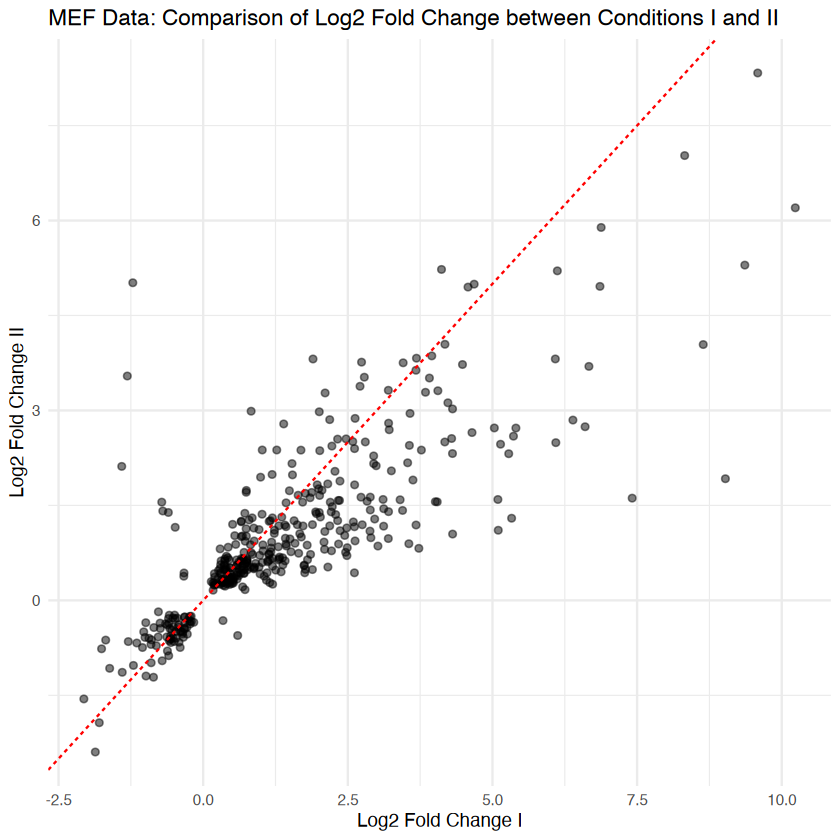

In [114]:
ggplot(mef_data, aes(x = log2FoldChange_I, y = log2FoldChange_II)) +
  geom_point(alpha = 0.5) + # Plot points with semi-transparency for better visualization
  geom_abline(slope = 1, intercept = 0, color = "red", linetype = "dashed") + # Add diagonal line
  labs(title = "MEF Data: Comparison of Log2 Fold Change between Conditions I and II", 
       x = "Log2 Fold Change I", 
       y = "Log2 Fold Change II") +
  theme_minimal() # Use minimal theme for a clean look

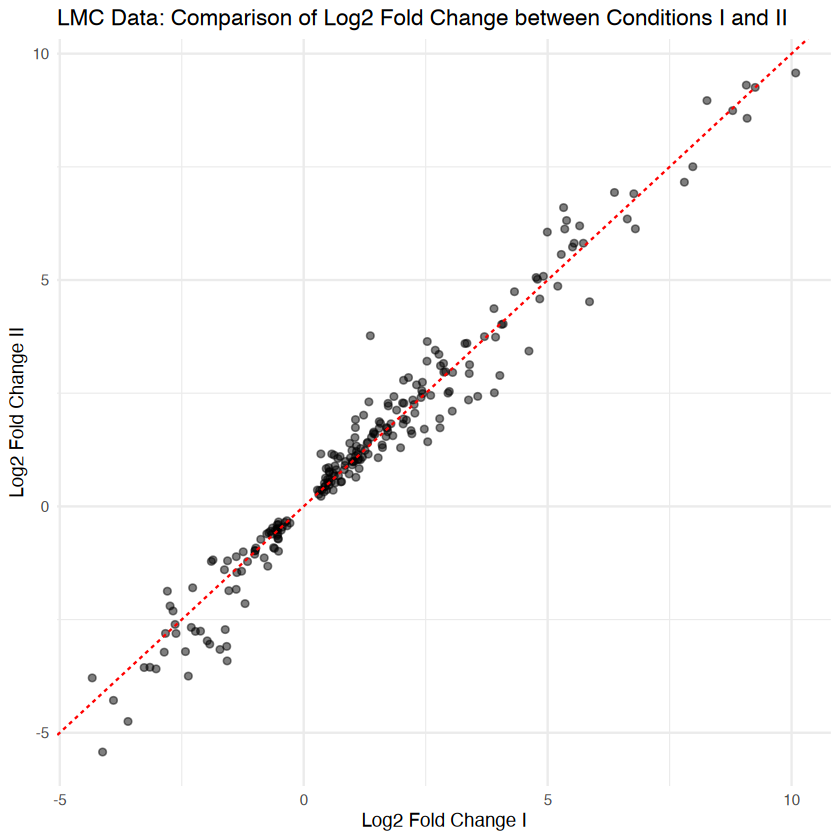

In [115]:
ggplot(lmc_data, aes(x = log2FoldChange_I, y = log2FoldChange_II)) +
  geom_point(alpha = 0.5) + # Plot points with semi-transparency for better visualization
  geom_abline(slope = 1, intercept = 0, color = "red", linetype = "dashed") + # Add diagonal line
  labs(title = "LMC Data: Comparison of Log2 Fold Change between Conditions I and II", 
       x = "Log2 Fold Change I", 
       y = "Log2 Fold Change II") +
  theme_minimal() # Use minimal theme for a clean look

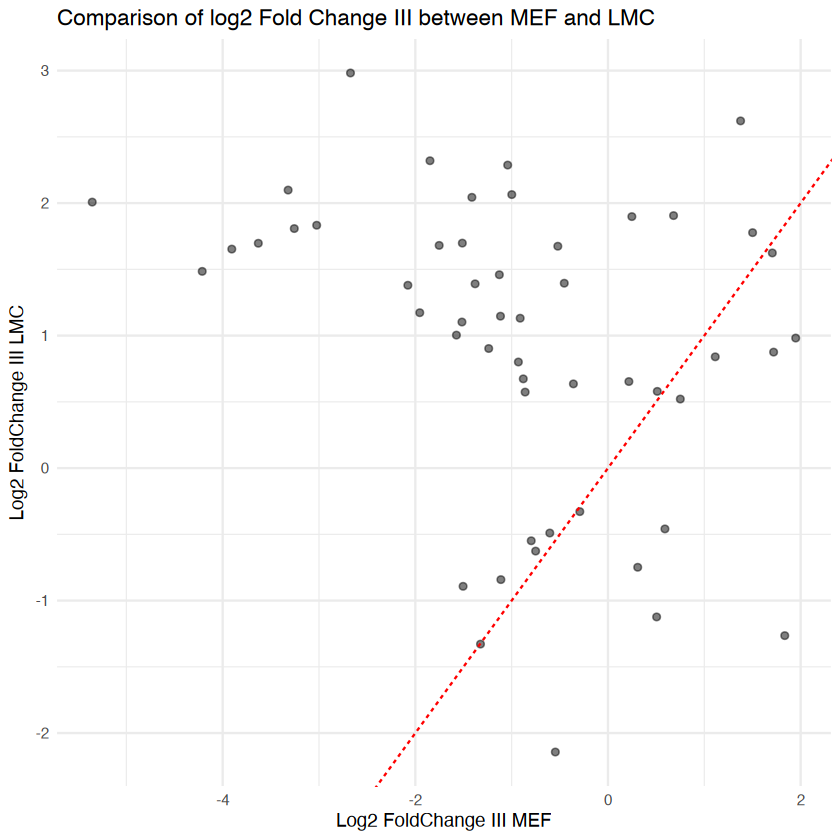

In [116]:
comparison_data <- merge(mef_data, lmc_data, by = "gene", suffixes = c("_MEF", "_LMC"))

# Now plot baseMean_I from MEF vs baseMean_I from LMC
ggplot(comparison_data, aes(x = log2FoldChange_III_MEF, y = log2FoldChange_III_LMC)) +
  geom_point(alpha = 0.5) +  # Adjust opacity if points are too dense
  geom_abline(intercept = 0, slope = 1, linetype = "dashed", color = "red") +  # Add a y=x reference line
  labs(title = "Comparison of log2 Fold Change III between MEF and LMC", x = "Log2 FoldChange III MEF", y = "Log2 FoldChange III LMC") +
  theme_minimal()

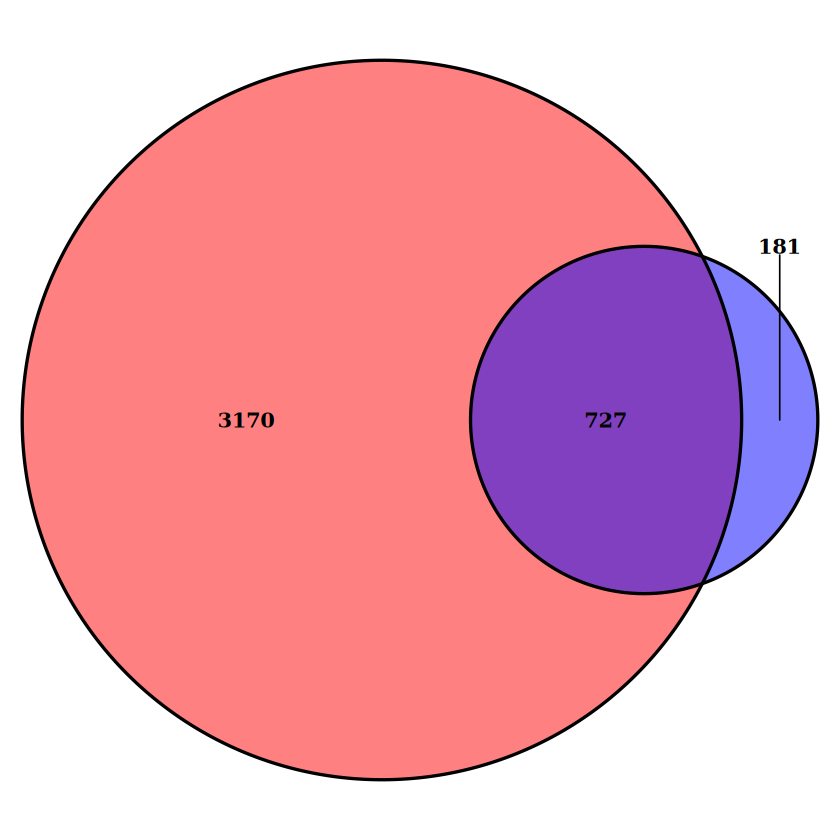

In [117]:
# Loading the DE genes from analysis I and II
gene_list_I <- na.omit(rownames(res2_I))  # Remove NAs
gene_list_II <- na.omit(rownames(res2_II))  # Remove NAs

# Making a list of the gene lists
gene_lists <- list(gene_list_I, gene_list_II)

# Run the venn diagram function
venn.plot <- venn.diagram(
    x = gene_lists,
    filename = NULL,
    category.names = c("", ""),  # Set as empty strings
    output = TRUE,
    fill = c("red", "blue"),
    alpha = 0.5,
    fontface = "bold",
    fontsize = 20,
    cat.fontface = "bold",
    cat.fontsize = 20,
    lty = "solid",
    lwd = 2,
    label.col = "black",  # Set this to "black" to show numbers
    category.pos = NULL  # Set to NULL to avoid positioning non-existing labels
)
# Plot the diagram
grid.draw(venn.plot)

In [118]:
#Reading the list of DE genes from analysis I,II,III,IV,V respectively and merge them together for next analyses.

DE_I <- data.frame(rownames(res2_I))
DE_II <- data.frame(rownames(res2_II))
DE_III <- data.frame(rownames(res2_III))


colnames(DE_I)[1] <- "Gene_name"
colnames(DE_II)[1] <- "Gene_name"
colnames(DE_III)[1] <- "Gene_name"




In [119]:
combined_column <- unique(data.frame(c(DE_I$Gene_name,DE_II$Gene_name,DE_III$Gene_name)))
colnames(combined_column)[1] <- "Gene_name"
length(combined_column$Gene_name)

[1] 9606

In [120]:
write.csv(combined_column,"MEF_DE_genes_total_Jan15_2024.csv")

Carrying out gene-set enrichment analysis as highlighted in the following link : https://learn.gencore.bio.nyu.edu/rna-seq-analysis/gene-set-enrichment-analysis/

In [121]:
# Setting the organism mouse
organism = "org.Mm.eg.db"
library(organism, character.only = TRUE)

In [122]:
#Reformatting the list of genes for the plot
original_gene_list1 <- res2_I$log2FoldChange
names(original_gene_list1) <- rownames(res2_I)
gene_list1<-na.omit(original_gene_list1)
# sorting the list in decreasing order (required for clusterProfiler)
gene_list1 = sort(gene_list1, decreasing = TRUE)

#Reformatting the list of genes for the plot
original_gene_list2 <- res2_II$log2FoldChange
names(original_gene_list2) <- rownames(res2_II)
gene_list2<-na.omit(original_gene_list2)
# sorting the list in decreasing order (required for clusterProfiler)
gene_list2 = sort(gene_list2, decreasing = TRUE)

#Reformatting the list of genes for the plot
original_gene_list3 <- res2_III$log2FoldChange
names(original_gene_list3) <- rownames(res2_III)
gene_list3<-na.omit(original_gene_list3)
# sorting the list in decreasing order (required for clusterProfiler)
gene_list3 = sort(gene_list3, decreasing = TRUE)

In [123]:
gse1 <- gseGO(geneList=gene_list1, 
             ont ="BP", 
             keyType = "SYMBOL", 
             nPerm = 10000, 
             minGSSize = 3, 
             maxGSSize = 800, 
             pvalueCutoff = 0.2, 
             verbose = TRUE, 
             OrgDb = organism, 
             pAdjustMethod = "BH")

gse2 <- gseGO(geneList=gene_list2, 
             ont ="BP", 
             keyType = "SYMBOL", 
             nPerm = 10000, 
             minGSSize = 3, 
             maxGSSize = 800, 
             pvalueCutoff = 0.2, 
             verbose = TRUE, 
             OrgDb = organism, 
             pAdjustMethod = "BH")


gse3 <- gseGO(geneList=gene_list3, 
             ont ="BP", 
             keyType = "SYMBOL", 
             nPerm = 10000, 
             minGSSize = 3, 
             maxGSSize = 800, 
             pvalueCutoff = 0.2, 
             verbose = TRUE, 
             OrgDb = organism, 
             pAdjustMethod = "BH")



preparing geneSet collections...

GSEA analysis...

Warning message in .GSEA(geneList = geneList, exponent = exponent, minGSSize = minGSSize, :
"We do not recommend using nPerm parameter incurrent and future releases"
Warning message in fgsea(pathways = geneSets, stats = geneList, nperm = nPerm, minSize = minGSSize, :
"You are trying to run fgseaSimple. It is recommended to use fgseaMultilevel. To run fgseaMultilevel, you need to remove the nperm argument in the fgsea function call."
Warning message in preparePathwaysAndStats(pathways, stats, minSize, maxSize, gseaParam, :
"There are ties in the preranked stats (0.05% of the list).
The order of those tied genes will be arbitrary, which may produce unexpected results."
leading edge analysis...

done...

preparing geneSet collections...

GSEA analysis...

Warning message in .GSEA(geneList = geneList, exponent = exponent, minGSSize = minGSSize, :
"We do not recommend using nPerm parameter incurrent and future releases"
Warning message in 

In [124]:
gse_termsim1 <- pairwise_termsim(gse1)
gse_termsim2 <- pairwise_termsim(gse2)
gse_termsim3 <- pairwise_termsim(gse3)

In [125]:
genelist_gse3 <- data.frame(gse3@geneList)
colnames(genelist_gse3)[1] <- "FoldChange"

write.csv(genelist_gse3,'genelist_III_MEF_gsea_results.csv')

Loading required package: DOSE

DOSE v3.24.2  For help: https://yulab-smu.top/biomedical-knowledge-mining-book/

If you use DOSE in published research, please cite:
Guangchuang Yu, Li-Gen Wang, Guang-Rong Yan, Qing-Yu He. DOSE: an R/Bioconductor package for Disease Ontology Semantic and Enrichment analysis. Bioinformatics 2015, 31(4):608-609




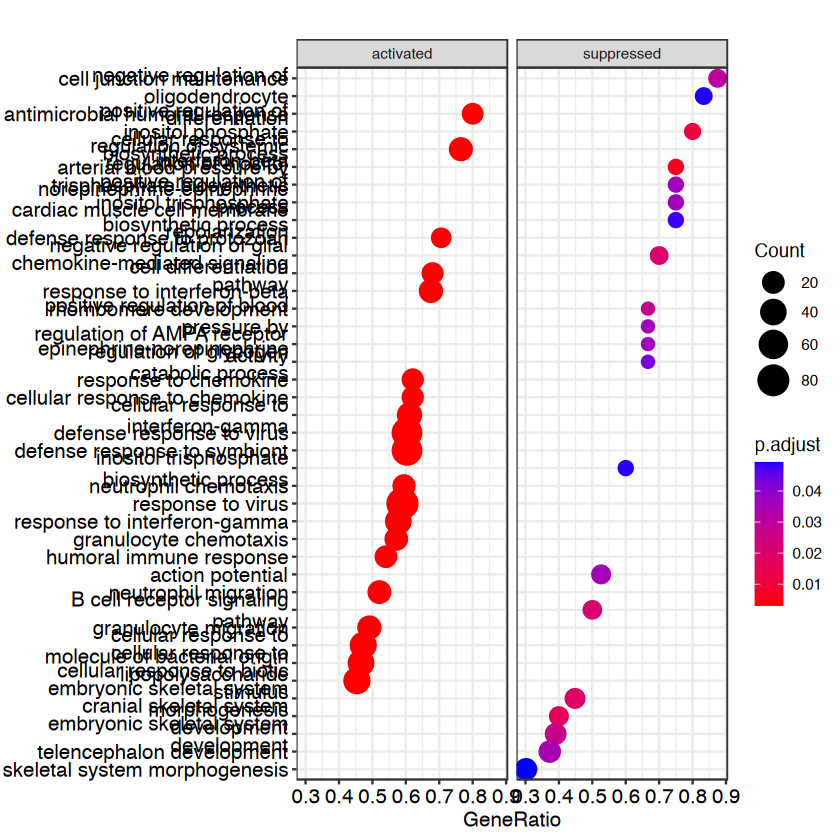

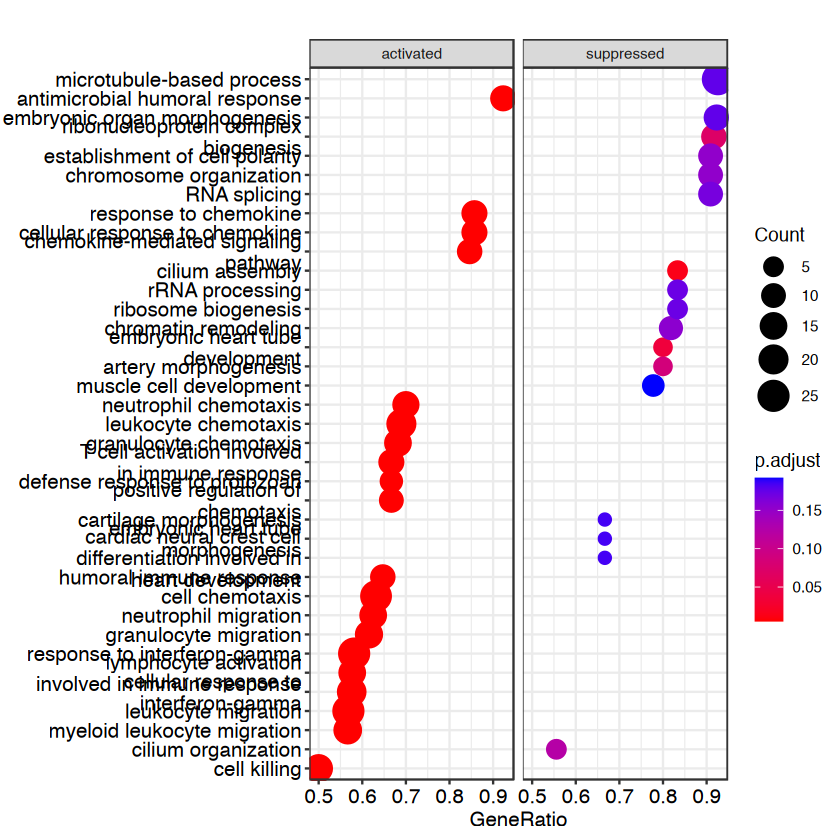

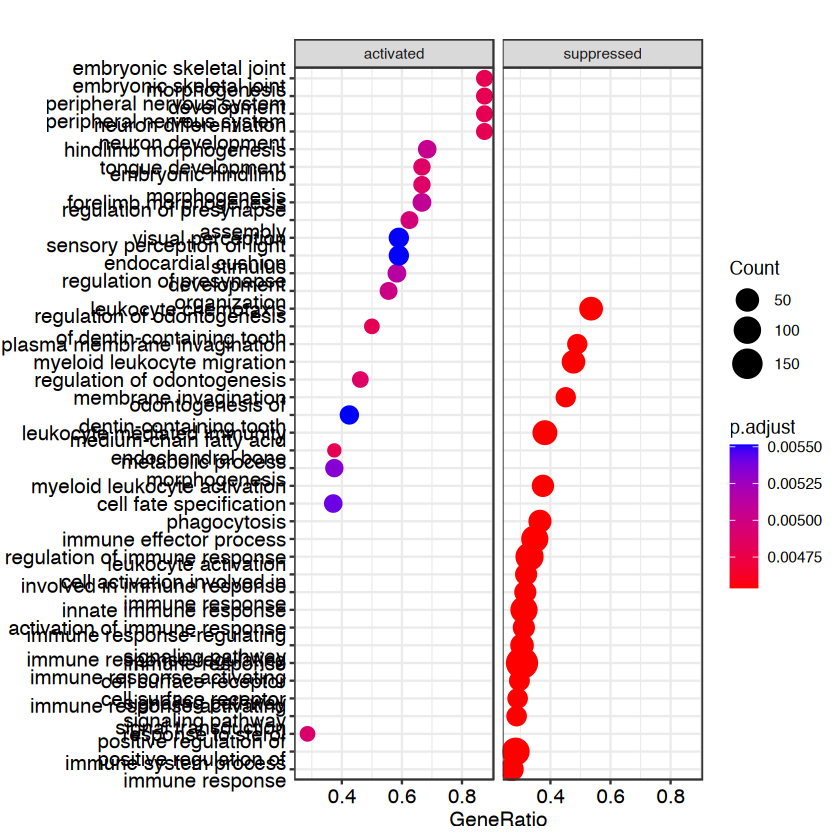

In [126]:
require(DOSE)
dotplot(gse1, showCategory=20, split=".sign") + facet_grid(.~.sign)
dotplot(gse2, showCategory=20, split=".sign") + facet_grid(.~.sign)
dotplot(gse3, showCategory=20, split=".sign") + facet_grid(.~.sign)

In [127]:
GO_I_mef <- data.frame(gse1@result)
GO_II_mef <- data.frame(gse2@result)
GO_III_mef <- data.frame(gse3@result)

In [128]:
write.csv(countData2,'MEF_May13_2025_analysis_counts.csv')

In [129]:
View(as.data.frame(gse1))

,ID,Description,setSize,enrichmentScore,NES,pvalue,p.adjust,qvalue,rank,leading_edge,core_enrichment
,<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
GO:0035458,GO:0035458,cellular response to interferon-beta,34,0.8803434,2.310904,0.0001072616,0.003086719,0.002649961,242,"tags=76%, list=6%, signal=72%",Tgtp2/Ifit1/Gbp6/Ifi205/Tgtp1/Iigp1/Gm4951/Gbp2/Gbp3/Ifi203/Gbp7/Igtp/Ifi47/Ifit3/Gm4841/F830016B08Rik/Irgm2/Irf1/Oas1g/Mndal/Gm5431/Oas1a/Ifi204/Gm12185/Irgm1/Trex1
GO:0071346,GO:0071346,cellular response to interferon-gamma,54,0.8348723,2.299188,0.0001031247,0.003086719,0.002649961,373,"tags=61%, list=10%, signal=56%",Il12b/Nos2/Gbp5/Ccl22/Gbp4/Ccl5/Gbp6/Ccl20/Ccl3/Gbp2/Ccl4/Gbp3/Parp14/Gbp7/Ccl2/Igtp/Cx3cl1/Gbp9/Irf1/Tlr2/Stx11/H2-Q7/Ccl7/Parp9/Ccl8/Ccl9/Irgm1/Socs1/Ccl17/Nmi/Nlrc5/Stat1/Jak2
GO:0034341,GO:0034341,response to interferon-gamma,71,0.8039610,2.257344,0.0001016570,0.003086719,0.002649961,373,"tags=58%, list=10%, signal=53%",Il12b/Nos2/Gbp5/Ccl22/Gbp4/Ccl5/Ubd/Gbp6/Tgtp1/Ccl20/Ccl3/Gbp2/Ccl4/Gbp3/Parp14/Gbp7/Ccl2/Igtp/Cx3cl1/Gbp9/Irgm2/Irf1/Tlr2/Stx11/H2-Q7/Cd74/Ccl7/Parp9/Cxcl16/Ccl8/Trim21/Ccl9/Irgm1/Gch1/Socs1/Ccl17/Nmi/Sp100/Nlrc5/Stat1/Jak2
GO:0035456,GO:0035456,response to interferon-beta,40,0.8404376,2.248026,0.0001056524,0.003086719,0.002649961,242,"tags=68%, list=6%, signal=64%",Tgtp2/Ifit1/Gbp6/Ifi205/Tgtp1/Iigp1/Gm4951/Gbp2/Gbp3/Ifi203/Gbp7/Igtp/Ifi47/Ifit3/Gm4841/F830016B08Rik/Irgm2/Irf1/Oas1g/Mndal/Gm5431/Xaf1/Oas1a/Ifi204/Gm12185/Irgm1/Trex1
GO:0019730,GO:0019730,antimicrobial humoral response,20,0.9159019,2.225487,0.0001148369,0.003086719,0.002649961,256,"tags=80%, list=7%, signal=75%",Cxcl10/Cxcl1/Cxcl2/Ccl22/Cxcl9/Cxcl5/Cxcl11/Ccl20/Pglyrp3/Nod2/Bcl3/Camp/Ccl8/Slpi/Ccl17/Tslp
GO:0030593,GO:0030593,neutrophil chemotaxis,37,0.8300280,2.201437,0.0001064283,0.003086719,0.002649961,252,"tags=59%, list=6%, signal=56%",Il1b/Cxcl10/Cxcl1/Cxcl2/Ccl22/Cxcl9/Ccl5/Cxcl5/Cxcl11/Ccl20/Ccl3/Il23a/Ccl4/Ccl2/Cx3cl1/Nod2/Cd74/Ccl7/Ccl8/Ccl9/Lbp/Ccl17
GO:0006959,GO:0006959,humoral immune response,37,0.8128679,2.155924,0.0001064283,0.003086719,0.002649961,289,"tags=54%, list=7%, signal=51%",Il1b/Cxcl10/Cxcl1/Cxcl2/Ccl22/Cxcl9/Tnf/Cxcl5/C3/Cxcl11/Ccl20/Pglyrp3/Nod2/Bcl3/Camp/Ccl8/Slpi/Ccl17/Tslp/Cfb
GO:0071621,GO:0071621,granulocyte chemotaxis,42,0.8003142,2.148982,0.0001053075,0.003086719,0.002649961,298,"tags=57%, list=8%, signal=53%",Il1b/Cxcl10/Cxcl1/Cxcl2/Ccl22/Cxcl9/Ccl5/Cxcl5/Cxcl11/Ccl20/Ccl3/Il23a/Ccl4/Ccl2/Cx3cl1/Nod2/Cd74/Ccl7/Ccl8/Ccl9/Lbp/Ccl17/Csf1/Ccr3
GO:1990868,GO:1990868,response to chemokine,29,0.8293740,2.134685,0.0001091107,0.003086719,0.002649961,252,"tags=62%, list=6%, signal=58%",Cxcl10/Cxcl1/Cxcl2/Ccl22/Cxcl9/Ccl5/Cxcl5/Cxcl11/Ccl20/Ccl3/Ccl4/Ccl2/Cx3cl1/Zc3h12a/Ccl7/Ccl8/Ccl9/Ccl17


In [130]:
gse1@result$Description <- sub("^(\\w)", "\\U\\1", gse1@result$Description, perl = TRUE)

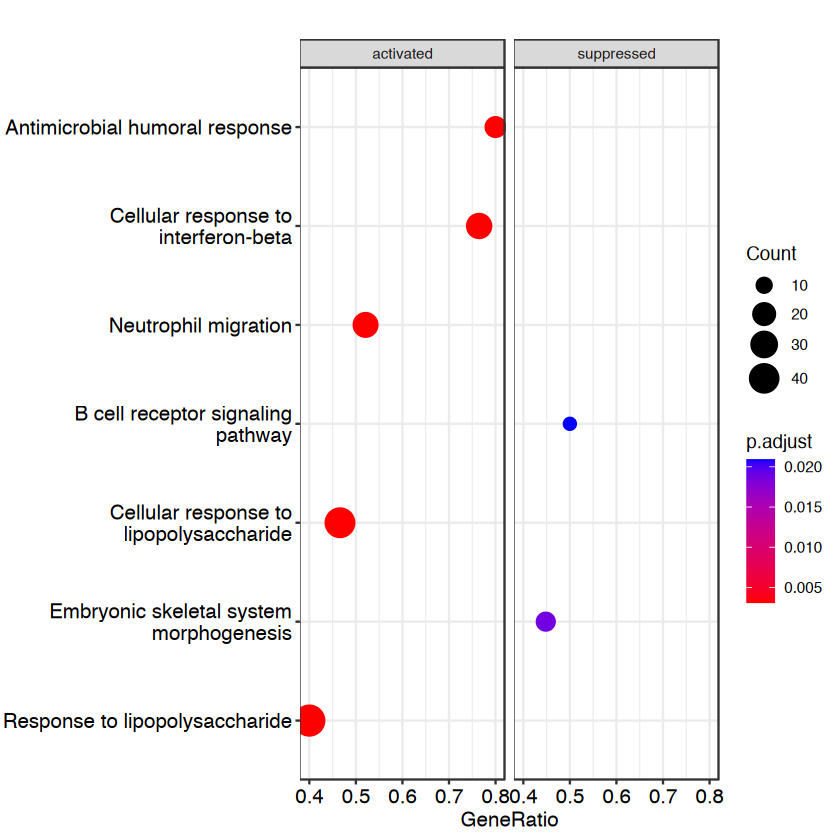

In [131]:
dotplot(gse1,showCategory=c("Cellular response to interferon-beta","Antimicrobial humoral response","Cellular response to lipopolysaccharide","Neutrophil migration","Embryonic skeletal system morphogenesis", "B cell receptor signaling pathway","Response to lipopolysaccharide"),split=".sign")+ facet_grid(.~.sign)

In [132]:
write.csv(GO_I_mef,'mef_GO_I_GSEA_clusterprofiler.csv')
write.csv(GO_II_mef,'mef_GO_II_GSEA_clusterprofiler.csv')
write.csv(GO_III_mef,'mef_GO_III_GSEA_clusterprofiler.csv')


In [133]:
gse2@result$Description <- sub("^(\\w)", "\\U\\1", gse2@result$Description, perl = TRUE)

In [134]:
View(as.data.frame(gse2))

,ID,Description,setSize,enrichmentScore,NES,pvalue,p.adjust,qvalue,rank,leading_edge,core_enrichment
,<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
GO:0060326,GO:0060326,Cell chemotaxis,38,0.7264309,2.042046,0.0001020408,0.005185642,0.004633128,162,"tags=63%, list=18%, signal=54%",Cxcl1/Cxcl5/Cxcl2/Cxcl10/Ccl5/Ccl2/Ccl20/Cx3cl1/Egr3/Vcam1/Cxcl16/Pdgfb/Cxcl9/Lbp/Saa3/Ccl7/Ccrl2/Cd74/Csf1/Cyp7b1/Cxcl11/Il23a/Ch25h/Nod2
GO:0030595,GO:0030595,Leukocyte chemotaxis,29,0.7465357,2.031987,0.0001036269,0.005185642,0.004633128,162,"tags=69%, list=18%, signal=59%",Cxcl1/Cxcl5/Cxcl2/Cxcl10/Ccl5/Ccl2/Ccl20/Cx3cl1/Cxcl16/Pdgfb/Cxcl9/Lbp/Ccl7/Cd74/Csf1/Cyp7b1/Cxcl11/Il23a/Ch25h/Nod2
GO:0071621,GO:0071621,Granulocyte chemotaxis,22,0.7648290,2.001827,0.0001059322,0.005185642,0.004633128,132,"tags=68%, list=15%, signal=60%",Cxcl1/Cxcl5/Cxcl2/Cxcl10/Ccl5/Ccl2/Ccl20/Cx3cl1/Cxcl9/Lbp/Ccl7/Cd74/Csf1/Cxcl11/Il23a
GO:1990868,GO:1990868,Response to chemokine,14,0.8240326,1.992123,0.0001114951,0.005185642,0.004633128,131,"tags=86%, list=14%, signal=74%",Cxcl1/Cxcl5/Cxcl2/Cxcl10/Ccl5/Ccl2/Ccl20/Zc3h12a/Cx3cl1/Cxcl9/Ccl7/Cxcl11
GO:1990869,GO:1990869,Cellular response to chemokine,14,0.8240326,1.992123,0.0001114951,0.005185642,0.004633128,131,"tags=86%, list=14%, signal=74%",Cxcl1/Cxcl5/Cxcl2/Cxcl10/Ccl5/Ccl2/Ccl20/Zc3h12a/Cx3cl1/Cxcl9/Ccl7/Cxcl11
GO:0034341,GO:0034341,Response to interferon-gamma,43,0.6952968,1.981229,0.0001015125,0.005185642,0.004633128,153,"tags=58%, list=17%, signal=51%",Ubd/Nos2/Gbp6/Gbp5/Gbp4/Ccl5/Ccl2/Gbp2/Gbp9/Gbp3/Tlr2/Ccl20/Cx3cl1/Tgtp1/Cxcl16/Stx11/Ifitm1/Gbp7/Parp14/Ccl7/Irf1/Cd74/Casp1/H2-Q7/Ciita
GO:0002286,GO:0002286,T cell activation involved in immune response,18,0.7815555,1.975541,0.0001083189,0.005185642,0.004633128,132,"tags=67%, list=15%, signal=58%",Nfkbiz/Zc3h12a/Bcl3/Ripk2/Stx11/Nlrp3/Icam1/Irf1/Nfkbid/Cd74/Relb/Il23a
GO:0097530,GO:0097530,Granulocyte migration,26,0.7346339,1.970451,0.0001044714,0.005185642,0.004633128,132,"tags=62%, list=15%, signal=54%",Cxcl1/Cxcl5/Cxcl2/Cxcl10/Ccl5/Ccl2/Tlr2/Ccl20/Cx3cl1/Cxcl9/Lbp/Ccl7/Cd74/Csf1/Cxcl11/Il23a
GO:0030593,GO:0030593,Neutrophil chemotaxis,20,0.7643959,1.969294,0.0001070893,0.005185642,0.004633128,132,"tags=70%, list=15%, signal=61%",Cxcl1/Cxcl5/Cxcl2/Cxcl10/Ccl5/Ccl2/Ccl20/Cx3cl1/Cxcl9/Lbp/Ccl7/Cd74/Cxcl11/Il23a


In [135]:
gse3@result$Description <- sub("^(\\w)", "\\U\\1", gse3@result$Description, perl = TRUE)

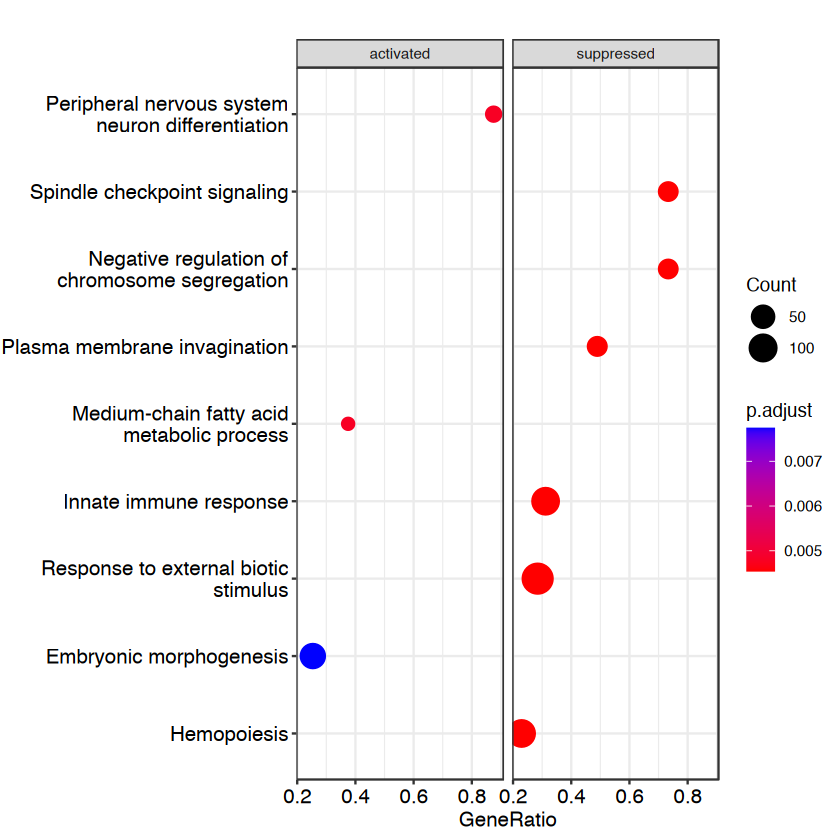

In [136]:
dotplot(gse3,showCategory=c("Spindle checkpoint signaling","Peripheral nervous system neuron differentiation","Negative regulation of chromosome segregation","Innate immune response","Response to external biotic stimulus","biological process involved in interspecies interaction between organisms","Plasma membrane invagination","Hemopoiesis","Embryonic morphogenesis","Medium-chain fatty acid metabolic process"),split=".sign")+ facet_grid(.~.sign)

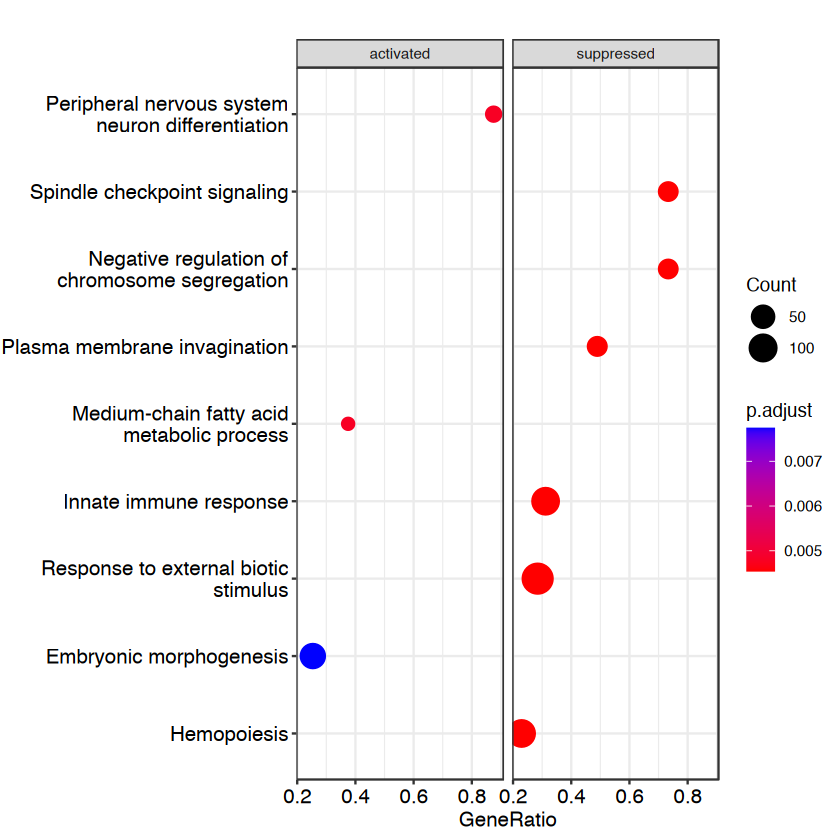

In [137]:
dotplot(gse3,showCategory=c("Spindle checkpoint signaling","Peripheral nervous system neuron differentiation","Negative regulation of chromosome segregation","Innate immune response","Response to external biotic stimulus","biological process involved in interspecies interaction between organisms","Plasma membrane invagination","Hemopoiesis","Embryonic morphogenesis","Medium-chain fatty acid metabolic process"),split=".sign")+ facet_grid(.~.sign)

In [138]:
# Assuming `p` is your ggplot object
p <- ridgeplot(gse1) +
  labs(x = "enrichment distribution") +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1, size = 8),  # Rotate and reduce text size
    axis.text.y = element_text(size = 6),  # Further reduce text size for y-axis
    strip.text.y = element_text(size = 6, angle = 0)  # Reduce facet label size and optionally rotate
  ) +
  coord_fixed(ratio = 0.7)  # Adjust aspect ratio

p <- ridgeplot(gse2) +
  labs(x = "enrichment distribution") +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1, size = 8),  # Rotate and reduce text size
    axis.text.y = element_text(size = 6),  # Further reduce text size for y-axis
    strip.text.y = element_text(size = 6, angle = 0)  # Reduce facet label size and optionally rotate
  ) +
  coord_fixed(ratio = 0.7)  # Adjust aspect ratio


p <- ridgeplot(gse3) +
  labs(x = "enrichment distribution") +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1, size = 8),  # Rotate and reduce text size
    axis.text.y = element_text(size = 6),  # Further reduce text size for y-axis
    strip.text.y = element_text(size = 6, angle = 0)  # Reduce facet label size and optionally rotate
  ) +
  coord_fixed(ratio = 0.7)  # Adjust aspect ratio




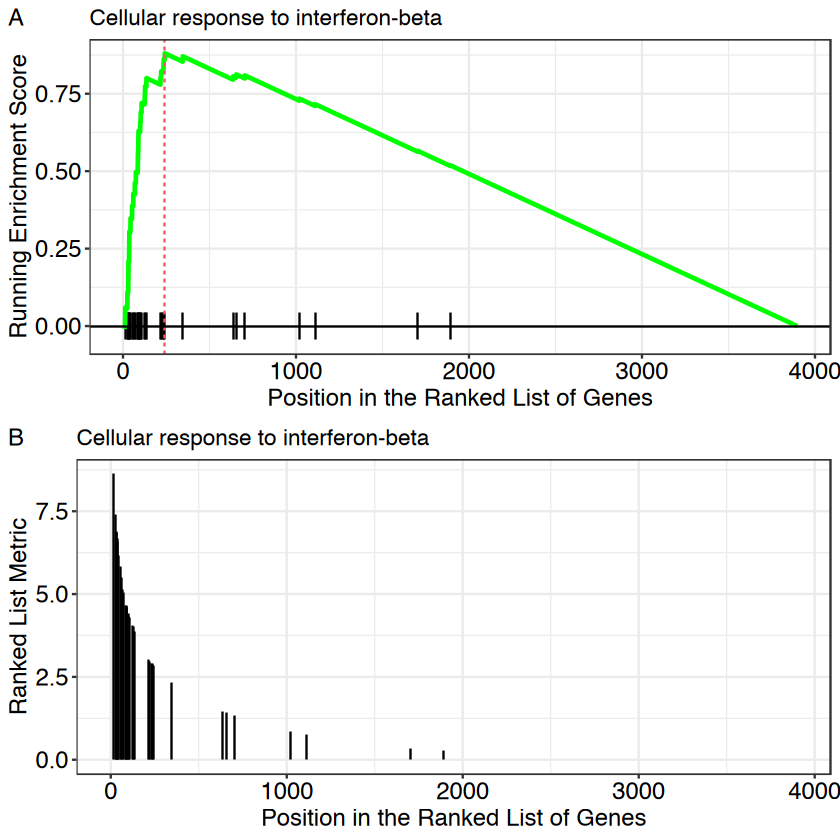

In [139]:
p1 <- gseaplot(gse1, geneSetID = 1, by = "runningScore", title = gse1$Description[1])
p2 <- gseaplot(gse1, geneSetID = 1, by = "preranked", title = gse1$Description[1])
#p3 <- gseaplot(gse1, geneSetID = 1, title = gse1$Description[1])
cowplot::plot_grid(p1, p2, ncol=1, labels=LETTERS[1:2])

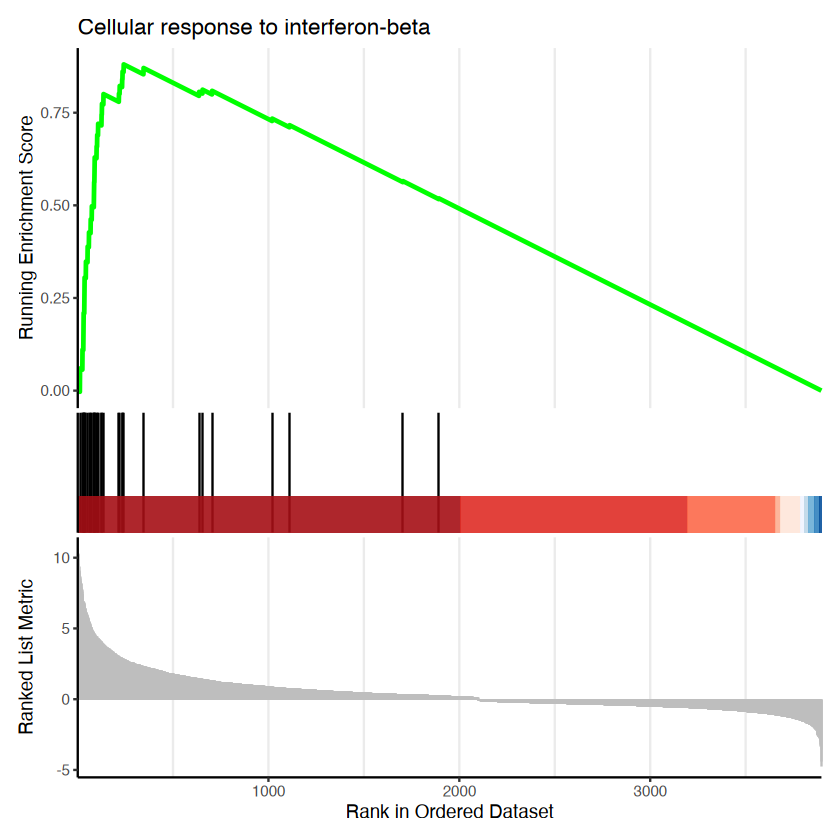

In [140]:
gseaplot2(gse1, geneSetID = 1, title = gse1$Description[1])

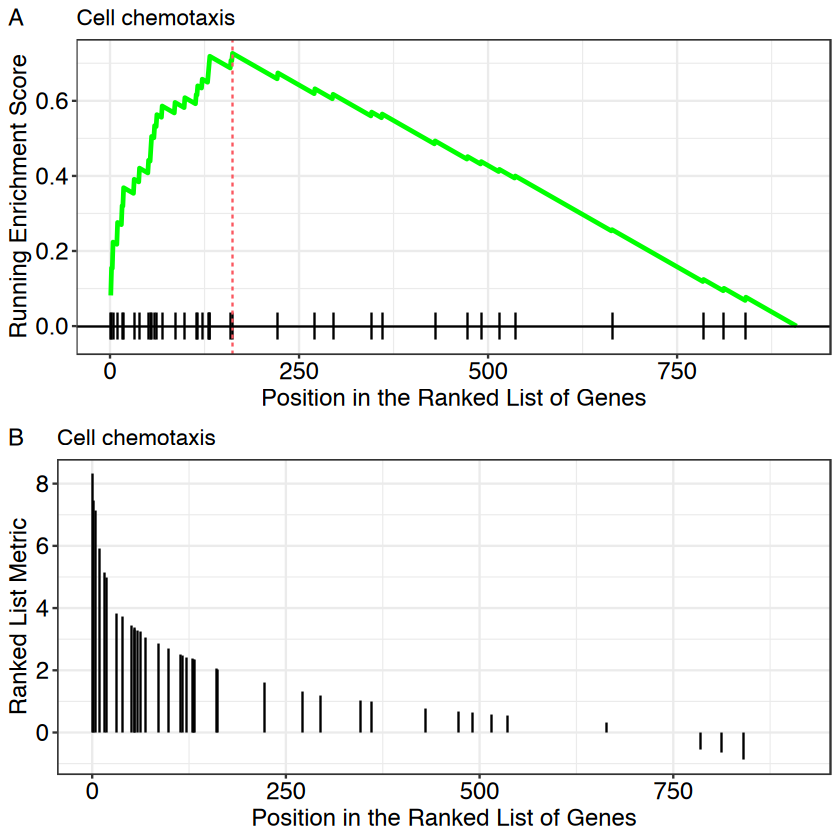

In [141]:
p1 <- gseaplot(gse2, geneSetID = 1, by = "runningScore", title = gse2$Description[1])
p2 <- gseaplot(gse2, geneSetID = 1, by = "preranked", title = gse2$Description[1])
cowplot::plot_grid(p1, p2, ncol=1, labels=LETTERS[1:2])

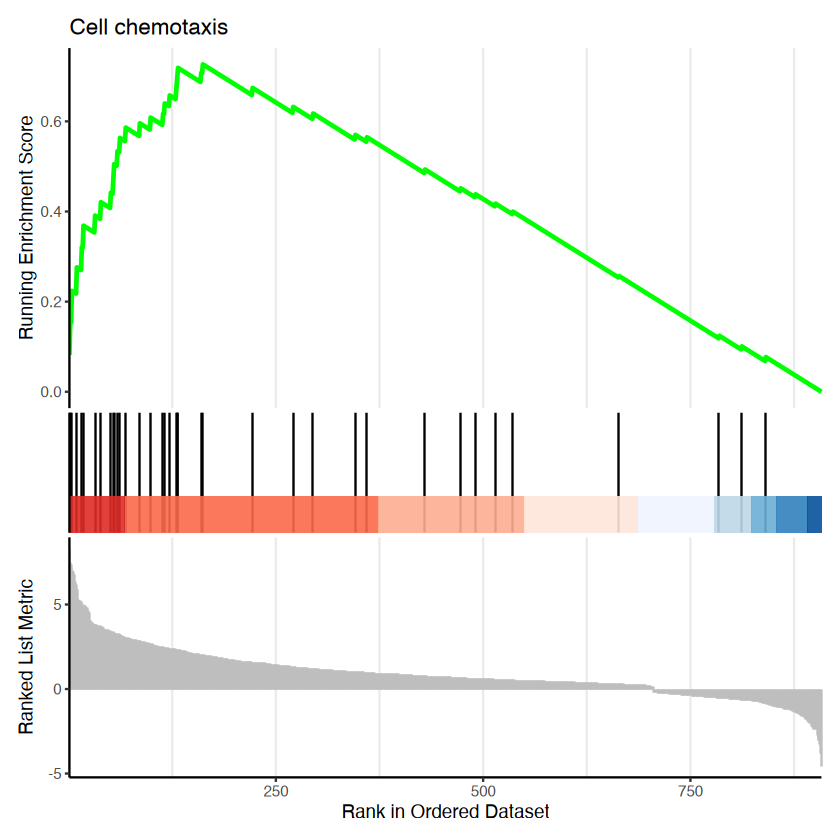

In [142]:
gseaplot2(gse2, geneSetID = 1, title = gse2$Description[1])

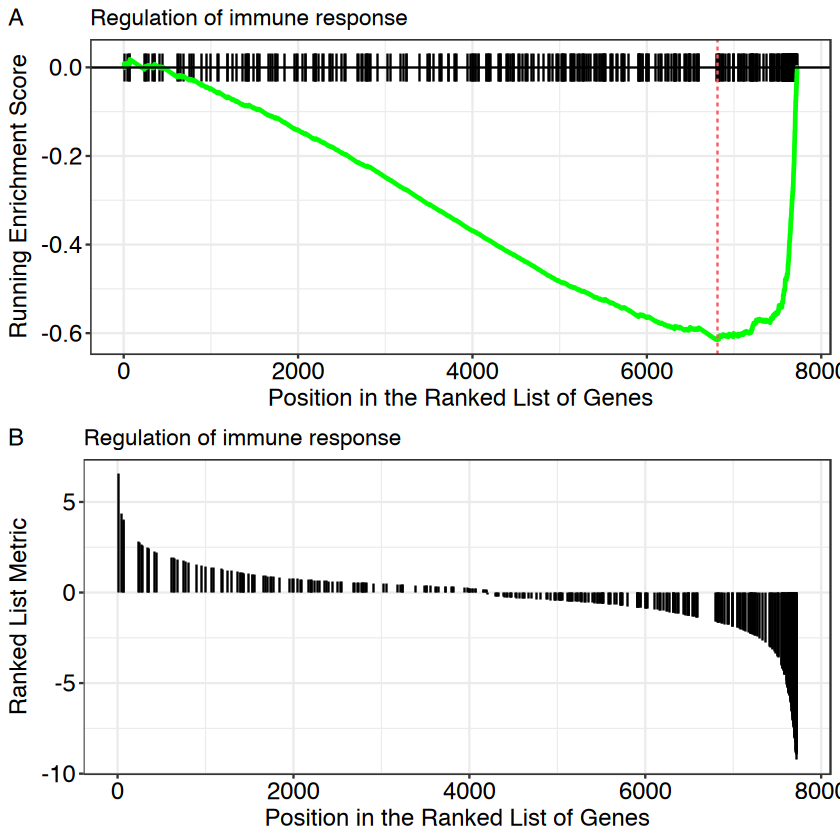

In [143]:
p1 <- gseaplot(gse3, geneSetID = 1, by = "runningScore", title = gse3$Description[1])
p2 <- gseaplot(gse3, geneSetID = 1, by = "preranked", title = gse3$Description[1])
cowplot::plot_grid(p1, p2, ncol=1, labels=LETTERS[1:2])

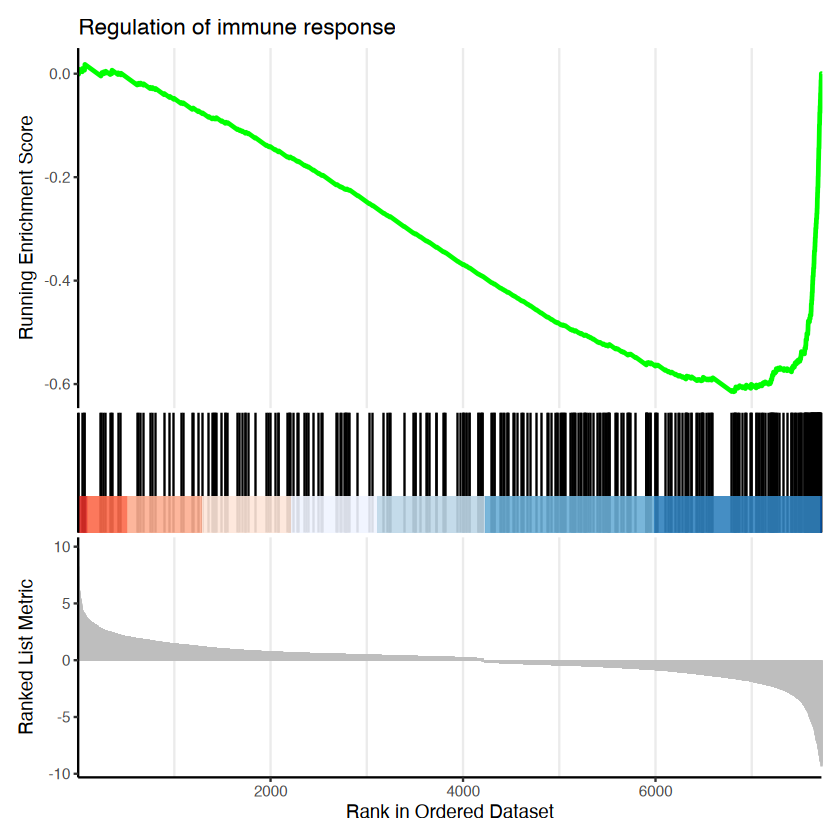

In [144]:
gseaplot2(gse3, geneSetID = 1, title = gse3$Description[1])

In [145]:
enriched_terms_df_gse1 <- gse1@result

# View the first few rows of the data frame
head(enriched_terms_df_gse1)

,ID,Description,setSize,enrichmentScore,NES,pvalue,p.adjust,qvalue,rank,leading_edge,core_enrichment
,<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
GO:0035458,GO:0035458,Cellular response to interferon-beta,34,0.8803434,2.310904,0.0001072616,0.003086719,0.002649961,242,"tags=76%, list=6%, signal=72%",Tgtp2/Ifit1/Gbp6/Ifi205/Tgtp1/Iigp1/Gm4951/Gbp2/Gbp3/Ifi203/Gbp7/Igtp/Ifi47/Ifit3/Gm4841/F830016B08Rik/Irgm2/Irf1/Oas1g/Mndal/Gm5431/Oas1a/Ifi204/Gm12185/Irgm1/Trex1
GO:0071346,GO:0071346,Cellular response to interferon-gamma,54,0.8348723,2.299188,0.0001031247,0.003086719,0.002649961,373,"tags=61%, list=10%, signal=56%",Il12b/Nos2/Gbp5/Ccl22/Gbp4/Ccl5/Gbp6/Ccl20/Ccl3/Gbp2/Ccl4/Gbp3/Parp14/Gbp7/Ccl2/Igtp/Cx3cl1/Gbp9/Irf1/Tlr2/Stx11/H2-Q7/Ccl7/Parp9/Ccl8/Ccl9/Irgm1/Socs1/Ccl17/Nmi/Nlrc5/Stat1/Jak2
GO:0034341,GO:0034341,Response to interferon-gamma,71,0.8039610,2.257344,0.0001016570,0.003086719,0.002649961,373,"tags=58%, list=10%, signal=53%",Il12b/Nos2/Gbp5/Ccl22/Gbp4/Ccl5/Ubd/Gbp6/Tgtp1/Ccl20/Ccl3/Gbp2/Ccl4/Gbp3/Parp14/Gbp7/Ccl2/Igtp/Cx3cl1/Gbp9/Irgm2/Irf1/Tlr2/Stx11/H2-Q7/Cd74/Ccl7/Parp9/Cxcl16/Ccl8/Trim21/Ccl9/Irgm1/Gch1/Socs1/Ccl17/Nmi/Sp100/Nlrc5/Stat1/Jak2
GO:0035456,GO:0035456,Response to interferon-beta,40,0.8404376,2.248026,0.0001056524,0.003086719,0.002649961,242,"tags=68%, list=6%, signal=64%",Tgtp2/Ifit1/Gbp6/Ifi205/Tgtp1/Iigp1/Gm4951/Gbp2/Gbp3/Ifi203/Gbp7/Igtp/Ifi47/Ifit3/Gm4841/F830016B08Rik/Irgm2/Irf1/Oas1g/Mndal/Gm5431/Xaf1/Oas1a/Ifi204/Gm12185/Irgm1/Trex1
GO:0019730,GO:0019730,Antimicrobial humoral response,20,0.9159019,2.225487,0.0001148369,0.003086719,0.002649961,256,"tags=80%, list=7%, signal=75%",Cxcl10/Cxcl1/Cxcl2/Ccl22/Cxcl9/Cxcl5/Cxcl11/Ccl20/Pglyrp3/Nod2/Bcl3/Camp/Ccl8/Slpi/Ccl17/Tslp
GO:0030593,GO:0030593,Neutrophil chemotaxis,37,0.8300280,2.201437,0.0001064283,0.003086719,0.002649961,252,"tags=59%, list=6%, signal=56%",Il1b/Cxcl10/Cxcl1/Cxcl2/Ccl22/Cxcl9/Ccl5/Cxcl5/Cxcl11/Ccl20/Ccl3/Il23a/Ccl4/Ccl2/Cx3cl1/Nod2/Cd74/Ccl7/Ccl8/Ccl9/Lbp/Ccl17


In [146]:
enriched_terms_df_gse2 <- gse2@result

# View the first few rows of the data frame
head(enriched_terms_df_gse2)

,ID,Description,setSize,enrichmentScore,NES,pvalue,p.adjust,qvalue,rank,leading_edge,core_enrichment
,<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
GO:0060326,GO:0060326,Cell chemotaxis,38,0.7264309,2.042046,0.0001020408,0.005185642,0.004633128,162,"tags=63%, list=18%, signal=54%",Cxcl1/Cxcl5/Cxcl2/Cxcl10/Ccl5/Ccl2/Ccl20/Cx3cl1/Egr3/Vcam1/Cxcl16/Pdgfb/Cxcl9/Lbp/Saa3/Ccl7/Ccrl2/Cd74/Csf1/Cyp7b1/Cxcl11/Il23a/Ch25h/Nod2
GO:0030595,GO:0030595,Leukocyte chemotaxis,29,0.7465357,2.031987,0.0001036269,0.005185642,0.004633128,162,"tags=69%, list=18%, signal=59%",Cxcl1/Cxcl5/Cxcl2/Cxcl10/Ccl5/Ccl2/Ccl20/Cx3cl1/Cxcl16/Pdgfb/Cxcl9/Lbp/Ccl7/Cd74/Csf1/Cyp7b1/Cxcl11/Il23a/Ch25h/Nod2
GO:0071621,GO:0071621,Granulocyte chemotaxis,22,0.7648290,2.001827,0.0001059322,0.005185642,0.004633128,132,"tags=68%, list=15%, signal=60%",Cxcl1/Cxcl5/Cxcl2/Cxcl10/Ccl5/Ccl2/Ccl20/Cx3cl1/Cxcl9/Lbp/Ccl7/Cd74/Csf1/Cxcl11/Il23a
GO:1990868,GO:1990868,Response to chemokine,14,0.8240326,1.992123,0.0001114951,0.005185642,0.004633128,131,"tags=86%, list=14%, signal=74%",Cxcl1/Cxcl5/Cxcl2/Cxcl10/Ccl5/Ccl2/Ccl20/Zc3h12a/Cx3cl1/Cxcl9/Ccl7/Cxcl11
GO:1990869,GO:1990869,Cellular response to chemokine,14,0.8240326,1.992123,0.0001114951,0.005185642,0.004633128,131,"tags=86%, list=14%, signal=74%",Cxcl1/Cxcl5/Cxcl2/Cxcl10/Ccl5/Ccl2/Ccl20/Zc3h12a/Cx3cl1/Cxcl9/Ccl7/Cxcl11
GO:0034341,GO:0034341,Response to interferon-gamma,43,0.6952968,1.981229,0.0001015125,0.005185642,0.004633128,153,"tags=58%, list=17%, signal=51%",Ubd/Nos2/Gbp6/Gbp5/Gbp4/Ccl5/Ccl2/Gbp2/Gbp9/Gbp3/Tlr2/Ccl20/Cx3cl1/Tgtp1/Cxcl16/Stx11/Ifitm1/Gbp7/Parp14/Ccl7/Irf1/Cd74/Casp1/H2-Q7/Ciita


In [147]:
enriched_terms_df_gse3 <- gse3@result

# View the first few rows of the data frame
head(enriched_terms_df_gse3)

,ID,Description,setSize,enrichmentScore,NES,pvalue,p.adjust,qvalue,rank,leading_edge,core_enrichment
,<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
GO:0050776,GO:0050776,Regulation of immune response,336,-0.6148675,-2.790810,0.0001266464,0.004538607,0.003720127,912,"tags=33%, list=12%, signal=30%",Lag3/Fgl2/Icosl/Tnf/Ager/Cyba/Tnfrsf14/Adcy7/Nfkbid/Tril/Zp3/Il1rl1/Ifi204/Syk/Rgcc/Il18rap/Cd14/Cd86/Ppl/Slc15a2/Tlr1/H2-M9/Fes/Hcst/P2rx7/C5ar2/Treml4/Plcg2/Arrb2/Enpp3/Ccr1/Pck1/Fcna/Aim2/Siglecg/Oas1a/Oas1g/Cfp/Tlr9/Nlrc4/Lpxn/Cd22/Mndal/Lcp2/Nlrp3/Prkch/Cd33/Pik3r6/Unc93b1/Ulbp1/Npy/Sh2d1b1/Fyb/Fcgr3/Cd300a/Was/Spn/Prkcb/Card9/Klhl6/Bcl2a1d/Apoe/Mmp12/Clec12a/Ptafr/Slc11a1/Slc15a3/Lat2/Cd84/Fcgr4/Rac2/Casp1/Adam8/Tlr7/Themis2/Cd5l/Ptpn6/Trem2/Ncf1/Clec4n/Myo1g/Stap1/Clec7a/Ptprc/Btk/Inpp5d/Tlr8/Cd37/Vav1/Clec4d/Spi1/Itgam/Fcer1g/Il7r/Nfam1/C5ar1/Fcgr2b/Pik3ap1/Cd180/Laptm5/Nckap1l/Itgb2/Cd36/Cd48/C3ar1/Myo1f/Tlr13/C1qc/C1qa/C1qb/Tyrobp
GO:0002274,GO:0002274,Myeloid leukocyte activation,104,-0.6930454,-2.742316,0.0001494098,0.004538607,0.003720127,613,"tags=38%, list=8%, signal=35%",Tlr1/Fes/Plcg2/Enpp3/Cebpa/Milr1/Tmem106a/Lcp2/Cx3cr1/Cd33/Cnr2/Ulbp1/Npy/Fcgr3/Cd300a/Aif1/Ptafr/Slc11a1/Lat2/Cd84/Fcgr4/Rac2/Casp1/Ptpn6/Trem2/Stap1/Pirb/Cd37/Clec4d/Spi1/Itgam/Fcer1g/Dock2/C5ar1/Itgb2/Cd48/Myo1f/C1qa/Tyrobp
GO:0002764,GO:0002764,Immune response-regulating signaling pathway,167,-0.6475735,-2.731244,0.0001401542,0.004538607,0.003720127,678,"tags=31%, list=9%, signal=28%",Cd14/Cd86/Slc15a2/Tlr1/C5ar2/Treml4/Plcg2/Arrb2/Aim2/Oas1a/Oas1g/Tlr9/Lpxn/Cd22/Lcp2/Nlrp3/Prkch/Cd33/Unc93b1/Sh2d1b1/Fyb/Cd300a/Prkcb/Klhl6/Bcl2a1d/Slc15a3/Lat2/Casp1/Tlr7/Themis2/Ptpn6/Trem2/Clec4n/Myo1g/Stap1/Clec7a/Ptprc/Btk/Tlr8/Clec4d/Fcer1g/Nfam1/C5ar1/Pik3ap1/Cd180/Laptm5/Nckap1l/Cd36/C3ar1/Tlr13/Tyrobp
GO:0002443,GO:0002443,Leukocyte mediated immunity,173,-0.6364131,-2.694039,0.0001398601,0.004538607,0.003720127,912,"tags=38%, list=12%, signal=34%",Lag3/Fgl2/Icosl/Tnf/Ager/Tcirg1/Spon2/Raet1e/Zp3/Syk/Il18rap/Trem1/H2-M9/Fes/P2rx7/Treml4/Plcg2/Arrb2/Exo1/Milr1/Tlr9/Il21r/Cx3cr1/Nlrp3/Pik3r6/Unc93b1/Ulbp1/Pou2f2/Sh2d1b1/Fcgr3/Cd300a/Coro1a/Was/Spn/Csf2rb/Card9/Slamf9/Ptafr/Slc11a1/Lat2/Cd84/Rac2/Csf2rb2/Ptpn6/Trem2/Ncf1/Myo1g/Stap1/Ptprc/Pirb/Btk/Inpp5d/Vav1/Spi1/Itgam/Fcer1g/Il7r/Fcgr2b/Nckap1l/Itgb2/Myo1f/Kdm5d/C1qc/C1qa/C1qb/Tyrobp
GO:0006955,GO:0006955,Immune response,596,-0.5618651,-2.659317,0.0001168224,0.004538607,0.003720127,918,"tags=31%, list=12%, signal=29%",Tgfbr3/Lag3/Fgl2/Icosl/Tnf/Ager/Trim59/Tcirg1/Cyba/Tnfrsf14/Adcy7/Spon2/Raet1e/Ticam2/Nfkbid/Oas2/Tril/Zp3/Il1rl1/Cxcl12/Ifi204/Syk/Rgcc/Ccl7/Evl/Il18rap/Cd14/Il1rl2/Cd86/Ppl/Ccrl2/Pik3cd/Slc15a2/Tlr1/Trem1/H2-M9/Fes/Ccr3/Sp100/Sirpa/Hcst/P2rx7/C5ar2/Treml4/Lfng/Plcg2/Arrb2/Clec4a1/Enpp3/Ccr1/Pck1/Mdk/Kng1/Fcna/Aim2/Siglecg/Ccl11/Mfng/Oas1a/Trf/Oas1g/Exo1/Gpr183/Naip5/Cfp/Clec4a2/Trim14/Milr1/Hck/Tlr9/Irf5/Tmem106a/Il21r/Nlrc4/Lpxn/Tnfrsf11a/Cd22/Mndal/Lcp2/Cx3cr1/Nlrp3/Ifi27l2b/Prkch/Sla/Cd33/Pik3r6/Unc93b1/Ulbp1/Dock10/Slamf7/Ccl3/Nrros/Npy/Pou2f2/Sh2d1b1/Ccl9/Fyb/Lst1/Fcgr3/Cd300a/Sp110/Coro1a/Ccl4/Was/Spn/Ccl6/Irf8/Csf2rb/Prkcb/Card9/Klhl6/Bcl2a1d/Lcp1/Apoe/Ly9/Slamf9/Ly86/Mmp12/Mcoln2/Clec12a/Ptafr/Slc11a1/Slc15a3/Lat2/Gbp8/Cd84/Cd68/Tnfaip8l2/Fcgr4/Rac2/Casp1/Adam8/Tlr7/Themis2/Csf1r/Cd5l/Csf2rb2/Ptpn6/Trem2/Itgal/Ncf1/Mrc1/Clec4n/Myo1g/Stap1/Clec7a/Pld4/Ptprc/Pirb/Btk/Wfdc17/Inpp5d/Tlr8/Cd37/Vav1/Clec4d/Spi1/Itgam/Fcer1g/Il7r/Dock2/Nfam1/C5ar1/Fcgr2b/Pik3ap1/Cd180/Cybb/Laptm5/Nckap1l/Itgb2/Cd36/Cd48/C3ar1/Myo1f/Kdm5d/Tlr13/C1qc/Ctss/C1qa/Mpeg1/C1qb/Tyrobp
GO:0002768,GO:0002768,Immune response-regulating cell surface receptor signaling pathway,91,-0.6837308,-2.652775,0.0001519757,0.004538607,0.003720127,307,"tags=30%, list=4%, signal=29%",Lpxn/Cd22/Lcp2/Prkch/Sh2d1b1/Fyb/Cd300a/Prkcb/Klhl6/Bcl2a1d/Lat2/Themis2/Ptpn6/Clec4n/Myo1g/Stap1/Clec7a/Ptprc/Btk/Clec4d/Fcer1g/Nfam1/C5ar1/Laptm5/Nckap1l/C3ar1/Tyrobp


In [148]:
homeobox <- read.csv('homebox_gene_list.csv',header = FALSE)
colnames(homeobox) <- "Gene_name"

In [149]:
homeobox$Gene_name <- toupper(homeobox$Gene_name)

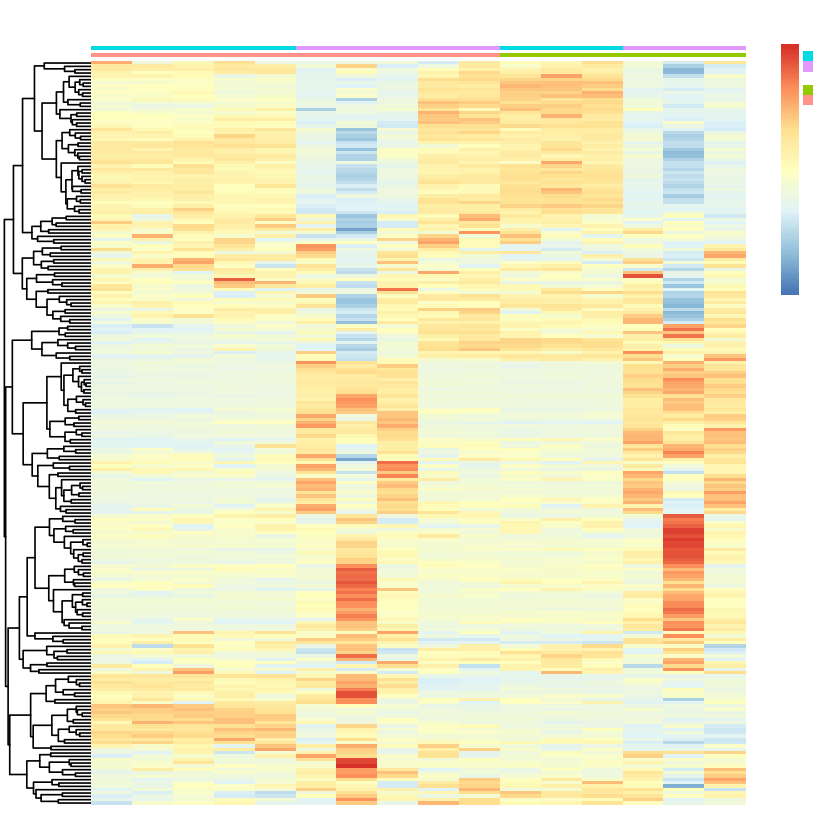

In [150]:
# Load necessary libraries
library(pheatmap)
library(dplyr)

# Ensure the gene names in homeobox are present in the row names of countData
common_genes <- intersect(homeobox$Gene_name, rownames(countData))

# Filter countData to include only rows that have genes present in common_genes
filteredCountData_homeo <- countData[common_genes, ]

# Define the width and height of the plot
# Increase the height to ensure all rows are visible
plot_width <- 20
plot_height <- 100

# Save the heatmap as a PDF
#pdf("Heatmap_of_Homeobox_Gene_Expression.pdf", width = plot_width, height = plot_height)

# Plot the heatmap of the filtered countData with clustering and improved row names visibility
pheatmap(filteredCountData_homeo,
         cluster_rows = TRUE,  # Cluster by rows
         cluster_cols = FALSE,
         annotation_col = as.data.frame(manual_annotation),  # Ensure this is defined or modify as needed
         show_rownames = TRUE,
         show_colnames = FALSE,  # Hiding column names
         scale = "row",
       #  fontsize_row = 4,  # Adjust the font size for row names
      #   fontsize_col = 10,  # Adjust the font size for column names if shown
         main = "Heatmap of Homeobox Gene Expression",
         fontsize = 2,  # Increase overall font size
         cellheight = 2)  # Set the height of each cell (row)



In [151]:
nf_kb <- read.table('nf_kb_sites.txt')

In [152]:
colnames(nf_kb)[1] <- "Gene_name"

In [153]:
library(clusterProfiler)
library(org.Mm.eg.db)

In [154]:
gene_listI <- rownames(res2_I)
entrez_ids <- mapIds(org.Mm.eg.db, keys = gene_listI, column = "ENTREZID", keytype = "SYMBOL")

# Running KEGG enrichment analysis using the Entrez IDs
kegg_results <- enrichKEGG(gene = entrez_ids, organism = 'mmu', keyType = 'kegg')
# Filter to get genes related to NF-κB signaling pathway (mmu04064)
nfkb_genes <- kegg_results$geneID[kegg_results$ID == 'mmu04064']
# Convert the gene list from a comma-separated string to a vector
nfkb_genes_list <- unlist(strsplit(nfkb_genes, split = "/"))
# Convert Entrez IDs back to Gene Names
nfkb_gene_names <- mapIds(org.Mm.eg.db, keys = nfkb_genes_list, column = "SYMBOL", keytype = "ENTREZID")
nf_I <- data.frame(nfkb_gene_names)

'select()' returned 1:1 mapping between keys and columns

Reading KEGG annotation online: "https://rest.kegg.jp/link/mmu/pathway"...

Reading KEGG annotation online: "https://rest.kegg.jp/list/pathway/mmu"...

'select()' returned 1:1 mapping between keys and columns



In [155]:
#This list of genes with Tata,GC boxes have been obtained from Homer analysis

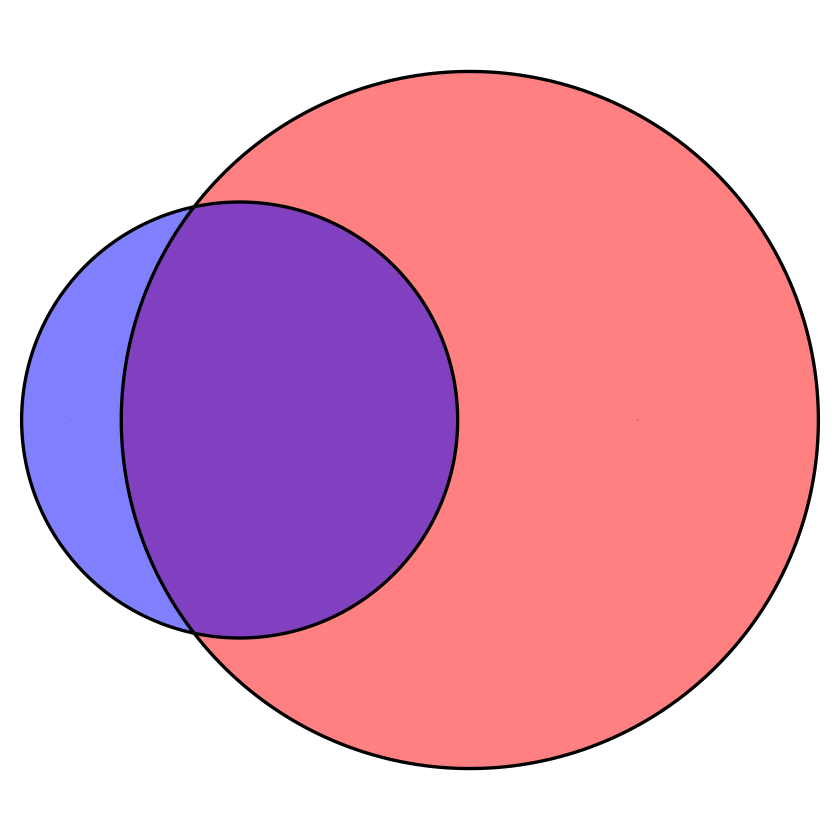

In [156]:
library(VennDiagram)
library(grid)

# Loading the DE genes from analysis I and II
gene_list_I <- na.omit(rownames(res2_I_up))  # Remove NAs
gene_list_II <- na.omit(rownames(res2_II_up))  # Remove NAs

# Making a list of the gene lists in flipped order
gene_lists <- list(gene_list_II, gene_list_I)

# Run the Venn diagram function with flipped positions, no labels, and no numbers
venn.plot <- venn.diagram(
    x = gene_lists,
    filename = NULL,
    category.names = c("", ""),  # Set category names to empty strings to hide labels
    output = TRUE,
    fill = c("blue", "red"),  # Flipped the colors to match the flipped order
    alpha = 0.5,
    fontface = "bold",
    fontsize = 20,
    cat.fontface = "bold",
    cat.fontsize = 20,
    rotation.degree = 180,  # Rotate the diagram by 180 degrees
    reverse = TRUE,  # Reverse the order of categories
    cex = 0  # Remove the numbers in circles
)

# Plot the diagram
grid.draw(venn.plot)





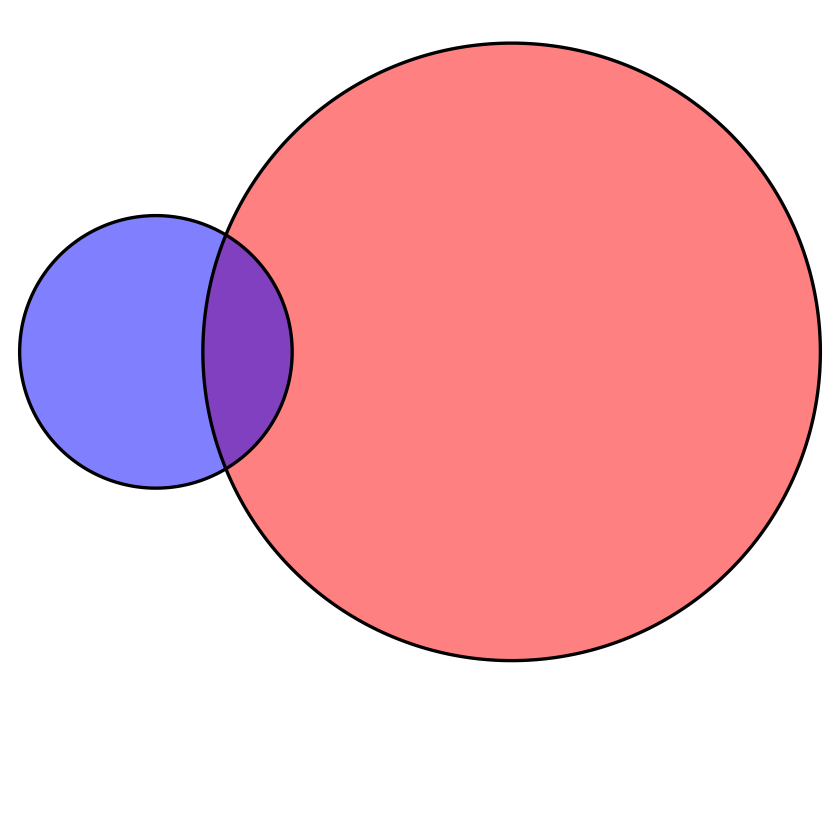

In [157]:
library(VennDiagram)
library(grid)

# Loading the DE genes from analysis I and II
gene_list_I <- na.omit(rownames(res2_I_down))  # Remove NAs
gene_list_II <- na.omit(rownames(res2_II_down))  # Remove NAs

# Making a list of the gene lists in flipped order
gene_lists <- list(gene_list_II, gene_list_I)

# Run the Venn diagram function with flipped positions, no labels, and no numbers
venn.plot <- venn.diagram(
    x = gene_lists,
    filename = NULL,
    category.names = c("", ""),  # Set category names to empty strings to hide labels
    output = TRUE,
    fill = c("blue", "red"),  # Flipped the colors to match the flipped order
    alpha = 0.5,
    fontface = "bold",
    fontsize = 20,
    cat.fontface = "bold",
    cat.fontsize = 20,
    rotation.degree = 180,  # Rotate the diagram by 180 degrees
    reverse = TRUE,  # Reverse the order of categories
    cex = 0,  # Remove the numbers in circles
    cat.cex = 0,  # Remove category labels
    label.col = c("transparent", "transparent", "transparent")  # Make labels transparent
)

# Plot the diagram
grid.draw(venn.plot)


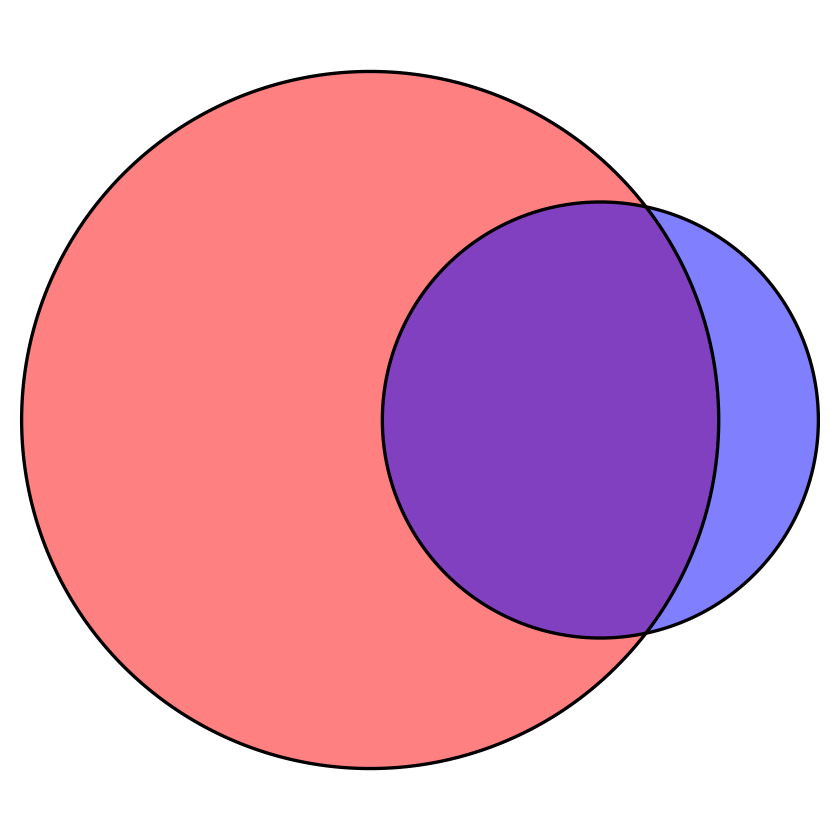

In [158]:
# Loading the DE genes from analysis I and II
gene_list_I <- na.omit(rownames(res2_I_up))  # Remove NAs
gene_list_II <- na.omit(rownames(res2_II_up))  # Remove NAs

# Making a list of the gene lists
gene_lists <- list(gene_list_I, gene_list_II)

# Run the venn diagram function
venn.plot <- venn.diagram(
    x = gene_lists,
    filename = NULL,
    category.names = c("", ""),  # Set as empty strings
    output = TRUE,
    fill = c("red", "blue"),
    alpha = 0.5,
    fontface = "bold",
    fontsize = 20,
    cat.fontface = "bold",
    cat.fontsize = 20,
    lty = "solid",
    lwd = 2,
    label.col = NA,  # Set this to "black" to show numbers
    category.pos = NULL  # Set to NULL to avoid positioning non-existing labels
)
# Plot the diagram
grid.draw(venn.plot)

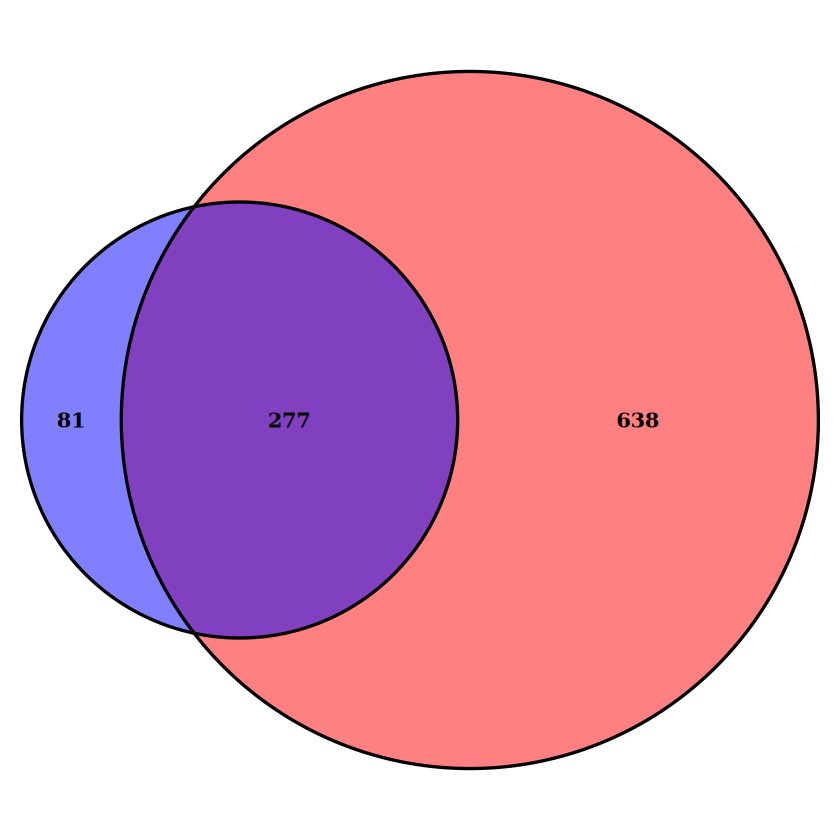

In [159]:
library(VennDiagram)
library(grid)

# Loading the DE genes from analysis I and II
gene_list_I <- na.omit(rownames(res2_I_up))  # Remove NAs
gene_list_II <- na.omit(rownames(res2_II_up))  # Remove NAs

# Making a list of the gene lists in flipped order
gene_lists <- list(gene_list_II, gene_list_I)

# Run the Venn diagram function with flipped positions and no labels
venn.plot <- venn.diagram(
    x = gene_lists,
    filename = NULL,
    category.names = c("", ""),  # Set category names to empty strings to hide labels
    output = TRUE,
    fill = c("blue", "red"),  # Flipped the colors to match the flipped order
    alpha = 0.5,
    fontface = "bold",
    fontsize = 20,
    cat.fontface = "bold",
    cat.fontsize = 20,
    lty = "solid",
    lwd = 2,
    label.col = "black",  # Set this to "black" to show numbers
    rotation.degree = 180,  # Rotate the diagram by 180 degrees
    reverse = TRUE  # Reverse the order of categories
)

# Plot the diagram
grid.draw(venn.plot)


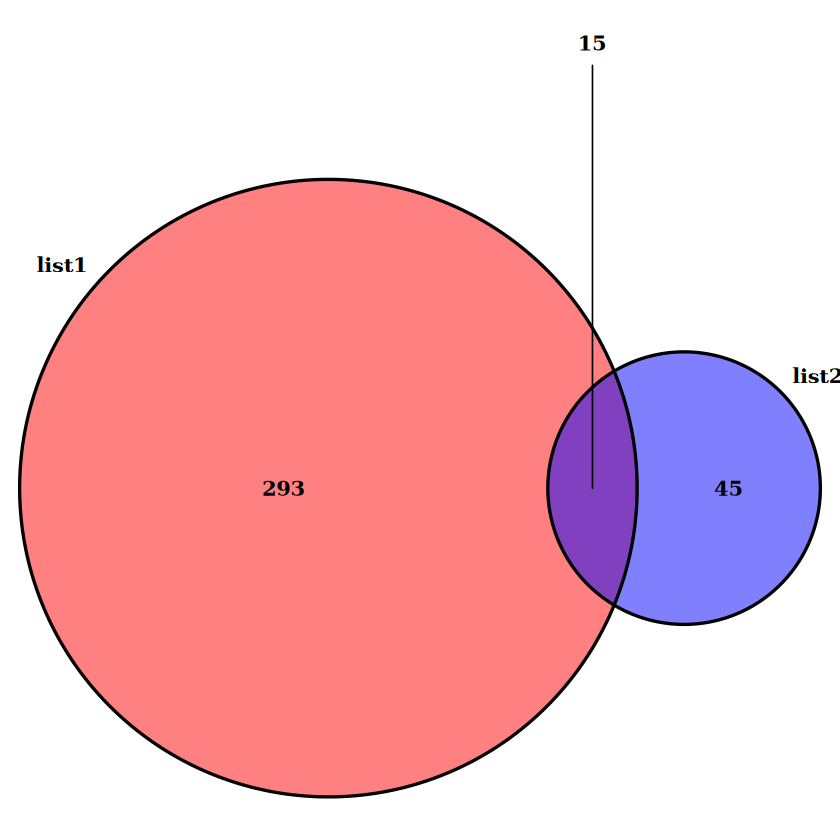

In [160]:
# Loading the DE genes from analysis I and II
gene_list_I <- na.omit(rownames(res2_I_down))  # Remove NAs
gene_list_II <- na.omit(rownames(res2_II_down))  # Remove NAs

# Making a list of the gene lists
gene_lists <- list(gene_list_I, gene_list_II)

# Run the venn diagram function
venn.plot <- venn.diagram(
    x = gene_lists,
    filename = NULL,
    category.names = c("list1", "list2"),  # Set as empty strings
    output = TRUE,
    fill = c("red", "blue"),
    alpha = 0.5,
    fontface = "bold",
    fontsize = 20,
    cat.fontface = "bold",
    cat.fontsize = 20,
    lty = "solid",
    lwd = 2,
    label.col = "black",  # Set this to "black" to show numbers
    category.pos = NULL  # Set to NULL to avoid positioning non-existing labels
)
# Plot the diagram
grid.draw(venn.plot)

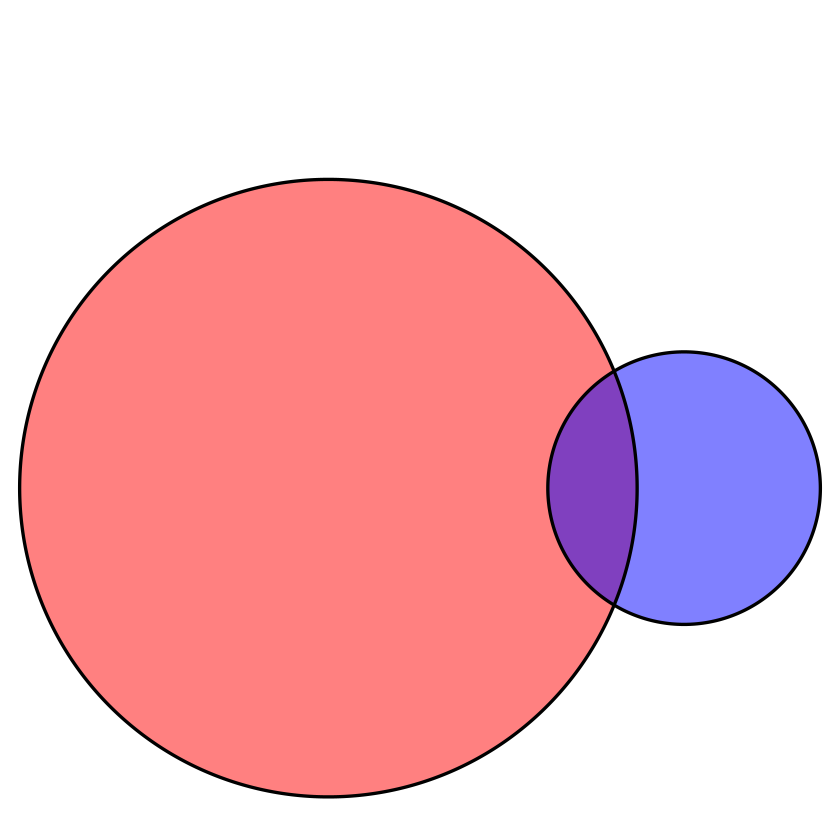

In [161]:
# Loading the DE genes from analysis I and II
gene_list_I <- na.omit(rownames(res2_I_down))  # Remove NAs
gene_list_II <- na.omit(rownames(res2_II_down))  # Remove NAs

# Making a list of the gene lists
gene_lists <- list(gene_list_I, gene_list_II)

# Run the venn diagram function
venn.plot <- venn.diagram(
    x = gene_lists,
    filename = NULL,
    category.names = c("", ""),  # Set as empty strings
    output = TRUE,
    fill = c("red", "blue"),
    alpha = 0.5,
    fontface = "bold",
    fontsize = 20,
    cat.fontface = "bold",
    cat.fontsize = 20,
    lty = "solid",
    lwd = 2,
    label.col = NA,  # Set this to "black" to show numbers
    category.pos = NULL  # Set to NULL to avoid positioning non-existing labels
)
# Plot the diagram
grid.draw(venn.plot)

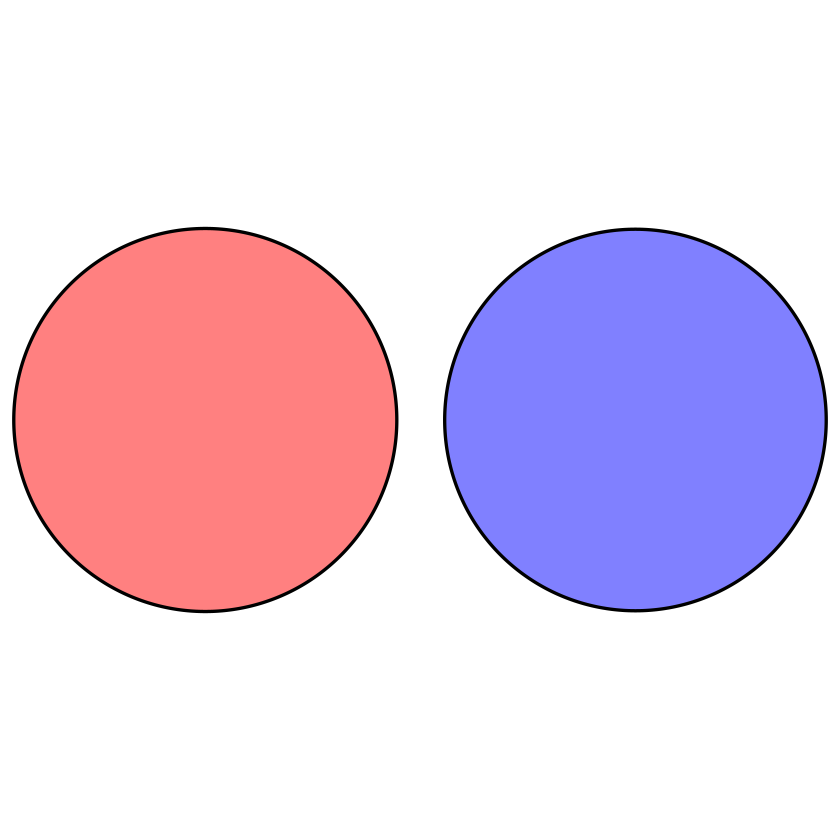

In [162]:
# Loading the DE genes from analysis I and II
gene_list_I <- na.omit(rownames(res3_up))  # Remove NAs
gene_list_II <- na.omit(rownames(res3_down))  # Remove NAs

# Making a list of the gene lists
gene_lists <- list(gene_list_I, gene_list_II)

# Run the venn diagram function
venn.plot <- venn.diagram(
    x = gene_lists,
    filename = NULL,
    category.names = c("", ""),  # Set as empty strings
    output = TRUE,
    fill = c("red", "blue"),
    alpha = 0.5,
    fontface = "bold",
    fontsize = 20,
    cat.fontface = "bold",
    cat.fontsize = 20,
    lty = "solid",
    lwd = 2,
    label.col = NA,  # Set this to "black" to show numbers
    category.pos = NULL  # Set to NULL to avoid positioning non-existing labels
)
# Plot the diagram
grid.draw(venn.plot)

In [163]:
gene_listII <- rownames(res2_II)
entrez_ids <- mapIds(org.Mm.eg.db, keys = gene_listII, column = "ENTREZID", keytype = "SYMBOL")

# Running KEGG enrichment analysis using the Entrez IDs
kegg_results <- enrichKEGG(gene = entrez_ids, organism = 'mmu', keyType = 'kegg')
# Filter to get genes related to NF-κB signaling pathway (mmu04064)
nfkb_genes <- kegg_results$geneID[kegg_results$ID == 'mmu04064']
nfkb_genes_list <- unlist(strsplit(nfkb_genes, split = "/"))
nfkb_gene_names <- mapIds(org.Mm.eg.db, keys = nfkb_genes_list, column = "SYMBOL", keytype = "ENTREZID")
nf_II <- data.frame(nfkb_gene_names)


'select()' returned 1:1 mapping between keys and columns

'select()' returned 1:1 mapping between keys and columns



In [164]:
colnames(nf_II)[1] <- "Gene_Name"
nf_II$Gene_Name <- toupper(nf_II$Gene_Name)

In [165]:
filtered_counts <- countData1[countData1$Gene_Name %in% nfkb_gene_names, ]

In [166]:
rownames(filtered_counts) <- filtered_counts$Gene_Name

In [167]:
rownames(res2_III) <- toupper(rownames(res2_III))

In [168]:
rownames(res2_II) <- toupper(rownames(res2_II))

In [169]:
filtered_data_II <- res2_II[row.names(res2_II) %in% nf_kb, ]

In [170]:
chk <- data.frame(rownames(res2_III))

In [171]:
nf_kb <- data.frame(nf_kb)

In [172]:
colnames(chk)[1] <- "Gene_name"

In [173]:
colnames(nf_kb)[1] <- "Gene_name"

In [174]:
chk2 <- merge(nf_kb,chk,by = "Gene_name")

In [175]:

nf_kb_genes <- intersect(rownames(res2_III), nf_kb$Gene_name)
filteredresdata <- res2_III[nf_kb_genes, ]

filtered_rows <- grep("^(?!GM|MIR|ENSMUS|RPL|RIK).*$", rownames(filteredresdata), perl = TRUE)


In [176]:
filteredresdata

log2 fold change (MLE): genotype mut vs wt 
Wald test p-value: genotype mut vs wt 
DataFrame with 143 rows and 7 columns
           baseMean log2FoldChange     lfcSE      stat       pvalue
          <numeric>      <numeric> <numeric> <numeric>    <numeric>
PENK       2106.031        5.87975  0.237001   24.8089 7.17866e-136
UCP2        747.971       -2.38129  0.111647  -21.3288 6.13613e-101
IL1RN      4518.897        5.75647  0.326452   17.6335  1.36338e-69
BDNF       2465.045        1.71052  0.107970   15.8426  1.58191e-56
PTAFR       195.275       -5.23533  0.340094  -15.3938  1.80265e-53
...             ...            ...       ...       ...          ...
TNFRSF1B 4802.50386      -0.453901  0.179298  -2.53155    0.0113561
TLR2     5188.44858       0.534925  0.213548   2.50494    0.0122471
CR2        31.58668      -0.805243  0.327128  -2.46156    0.0138336
ICOS        4.57783       2.102563  0.856843   2.45385    0.0141336
TRPC1     204.50097       0.580067  0.243186   2.38528    0.017

In [177]:
# Sort the filtered genes by the absolute value of log2FoldChange in descending order
sorted_genes <- filteredresdata[order(-abs(filteredresdata$log2FoldChange)), ]

# Select the top 50 genes based on this sorting
top_50_genes <- head(sorted_genes, 50)

In [178]:
top_50_expression_data <- countData1[rownames(top_50_genes), ]

In [179]:
# Assuming countdata1 is your data frame or matrix
rownames(countData1) <- toupper(rownames(countData1))


In [180]:
rownames(top_50_genes)

[1] "CD48"     "SPI1"     "BTK"      "PENK"     "IL1RN"    "PTAFR"   
 [7] "APOE"     "EBI3"     "CCL4"     "BMP4"     "CD83"     "CCL3"    
[13] "TFPI2"    "TNFSF15"  "CCL20"    "SERPINE2" "THBS2"    "TLR9"    
[19] "OLR1"     "PTGIS"    "WT1"      "TACR1"    "LIPG"     "ADORA1"  
[25] "HPSE"     "UCP2"     "DPYD"     "LEF1"     "MDK"      "MMP9"    
[31] "AGT"      "XDH"      "MYLK"     "ICOS"     "PTHLH"    "TREM1"   
[37] "DMP1"     "PAX8"     "F3"       "ST8SIA1"  "WNT10B"   "CD86"    
[43] "LCN2"     "MT3"      "SDC4"     "ADAM19"   "MBP"      "GCLC"    
[49] "GATA3"    "APOD"

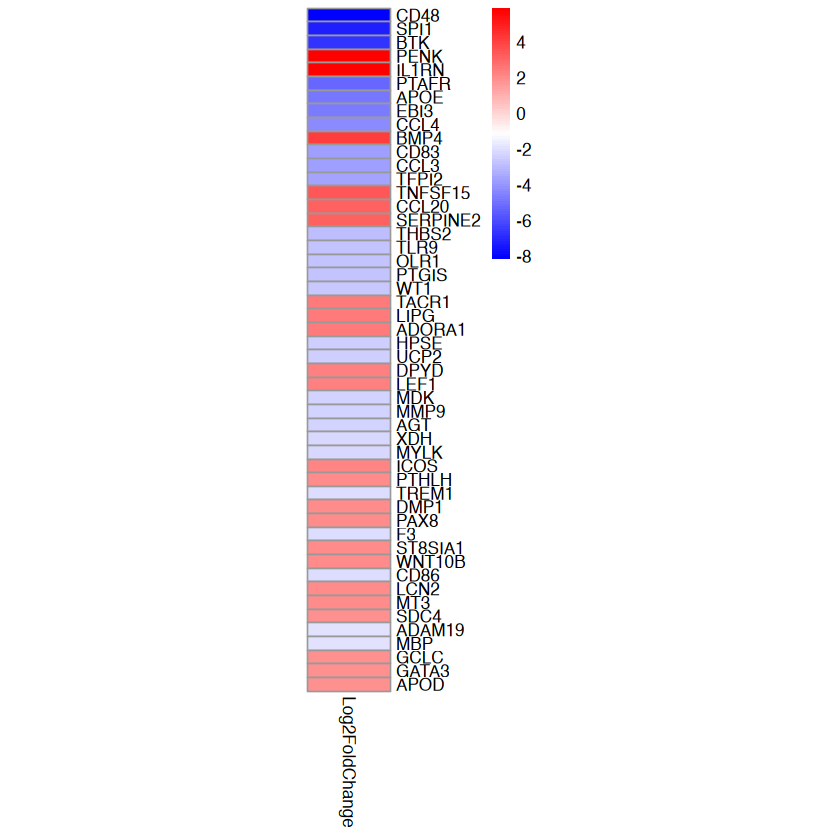

In [181]:
# Extract log2FoldChange values for the top 50 genes
log2fc_values_top_50 <- top_50_genes$log2FoldChange

# Convert to a matrix for pheatmap
log2fc_matrix_top_50 <- matrix(log2fc_values_top_50, nrow = length(log2fc_values_top_50), ncol = 1, 
                               dimnames = list(rownames(top_50_genes), "Log2FoldChange"))
genes_to_keep <- !grepl("^(Gm|Mir|ENSMUS|Rpl.*|.*Rik|mt-|Malat1)", rownames(log2fc_matrix_top_50))

# Filter both the log2FoldChange values and update row names accordingly
log2fc_values_filtered <- log2fc_values_top_50[genes_to_keep]
row_names_filtered <- rownames(log2fc_matrix_top_50)[genes_to_keep]

# Update the matrix for pheatmap using filtered genes
log2fc_matrix_filtered <- matrix(log2fc_values_filtered, nrow = length(log2fc_values_filtered), ncol = 1, 
                                 dimnames = list(row_names_filtered, "Log2FoldChange"))



color_palette_fc <- colorRampPalette(c("blue", "white", "red"))(100)
# Plot the heatmap with a slimmer appearance by adjusting cellwidth and cellheight
pheatmap(log2fc_matrix_filtered,
         cluster_rows = FALSE, 
         cluster_cols = FALSE, 
         show_rownames = TRUE,
         color = color_palette_fc,
         cellwidth = 50)  # Adjust the cell height if necessary


Attaching package: 'reshape2'


The following object is masked from 'package:tidyr':

    smiths




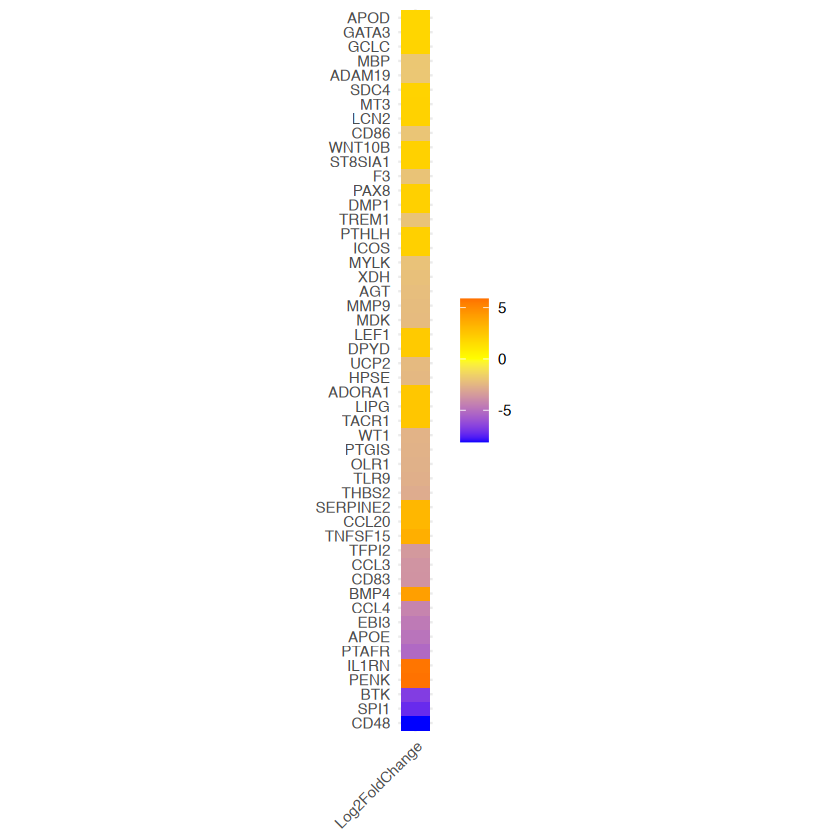

In [182]:
# Load necessary libraries
library(ggplot2)
library(reshape2)  # For melting the matrix

# Convert your matrix to a long format
long_data <- melt(log2fc_matrix_filtered)

ggplot(long_data, aes(x = Var2, y = Var1, fill = value)) +
  geom_tile() +  # Creates the heatmap tiles
  scale_fill_gradient2(low = "blue", high = "red", mid = "yellow", midpoint = 0) +  # Customize your color scale
  coord_fixed(ratio = 0.5) +  # Adjust this value to change tile thickness
  theme_minimal() +  # Use a minimal theme
  theme(axis.text.x = element_text(angle = 45, hjust = 1), # Rotate x-axis labels if needed
        axis.title = element_blank(), # Remove axis titles for a cleaner look
        legend.title = element_blank()) + # Optionally, adjust legend title
  labs(fill = "Log2 FC") # Customize labels as needed


In [183]:
lmc_I <- read.csv('LMC_I.csv')
lmc_II <- read.csv('LMC_II.csv')
lmc_III <- read.csv('LMC_III.csv')

In [184]:
lmc_I <- data.frame(lmc_I)
lmc_II <- data.frame(lmc_II)
lmc_III <- data.frame(lmc_III)

In [185]:
mef_I <- data.frame(mef_I)
mef_II <- data.frame(mef_II)
mef_III <- data.frame(mef_III)

In [186]:
mef_I$lfcSE <- NULL
mef_II$lfcSE <- NULL
mef_III$lfcSE <- NULL

mef_I$pvalue <- NULL
mef_II$pvalue <- NULL
mef_III$pvalue <- NULL

mef_I$stat <- NULL
mef_II$stat <- NULL
mef_III$stat <- NULL

In [187]:
colnames(mef_I)[1] <- "baseMean_I"
colnames(mef_II)[1] <- "baseMean_II"
colnames(mef_III)[1] <- "baseMean_III"

colnames(mef_I)[2] <- "log2Foldchange_I"
colnames(mef_II)[2] <- "log2Foldchange_II"
colnames(mef_III)[2] <- "log2Foldchange_III"

colnames(mef_I)[3] <- "AdjustedPvalue_I"
colnames(mef_II)[3] <- "AdjustedPvalue_II"
colnames(mef_III)[3] <- "AdjustedPvalue_III"

In [188]:
lmc_I$lfcSE <- NULL
lmc_II$lfcSE <- NULL
lmc_III$lfcSE <- NULL

lmc_I$pvalue <- NULL
lmc_II$pvalue <- NULL
lmc_III$pvalue <- NULL

lmc_I$stat <- NULL
lmc_II$stat <- NULL
lmc_III$stat <- NULL


In [189]:
colnames(lmc_I)[1] <- "Gene"
colnames(lmc_II)[1] <- "Gene"
colnames(lmc_III)[1] <- "Gene"

colnames(lmc_I)[2] <- "baseMean_I"
colnames(lmc_II)[2] <- "baseMean_II"
colnames(lmc_III)[2] <- "baseMean_III"

colnames(lmc_I)[3] <- "log2Foldchange_I"
colnames(lmc_II)[3] <- "log2Foldchange_II"
colnames(lmc_III)[3] <- "log2Foldchange_III"

colnames(lmc_I)[4] <- "AdjustedPvalue_I"
colnames(lmc_II)[4] <- "AdjustedPvalue_II"
colnames(lmc_III)[4] <- "AdjustedPvalue_III"

In [190]:
lmc_I_II <- merge(lmc_I,lmc_II,by = "Gene")

In [191]:
mef_I$Gene <- rownames(mef_I)
mef_II$Gene <- rownames(mef_II)
mef_III$Gene <- rownames(mef_III)

In [192]:
mef_I_II <- merge(mef_I,mef_II,by = "Gene")

In [193]:
lmc_I_II_filtered <- filter(lmc_I_II, AdjustedPvalue_I < 0.05 | AdjustedPvalue_II < 0.05)

`geom_smooth()` using formula = 'y ~ x'


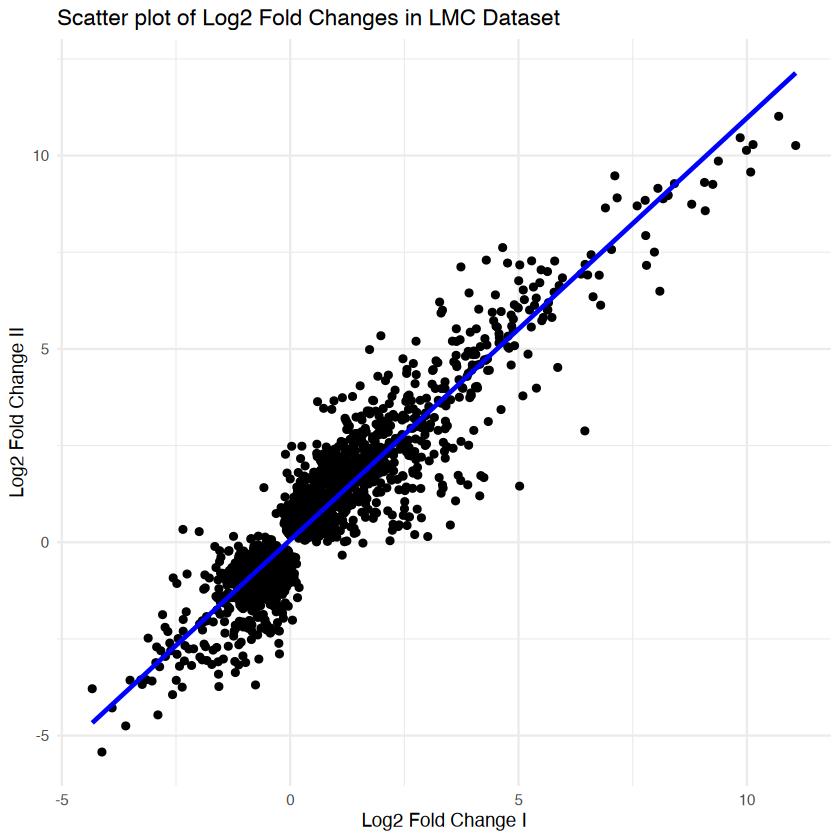

In [194]:
ggplot(lmc_I_II_filtered, aes(x = log2Foldchange_I, y = log2Foldchange_II)) +
  geom_point() +
  theme_minimal() +
  labs(x = "Log2 Fold Change I", y = "Log2 Fold Change II", title = "Scatter plot of Log2 Fold Changes in LMC Dataset") +
  geom_smooth(method = "lm", color = "blue", se = FALSE) # Adds a linear regression line without confidence interval

In [195]:
# Assuming 'lmc_I_II_filtered' is correctly set up with 'log2Foldchange_I', 'log2Foldchange_II', and 'Gene' columns.

# Load necessary libraries
library(plotly)

# Define the range for the diagonal line based on your data limits
range_min <- min(c(lmc_I_II_filtered$log2Foldchange_I, lmc_I_II_filtered$log2Foldchange_II))
range_max <- max(c(lmc_I_II_filtered$log2Foldchange_I, lmc_I_II_filtered$log2Foldchange_II))

# Fit a linear model for the regression line
lm_fit <- lm(log2Foldchange_II ~ log2Foldchange_I, data = lmc_I_II_filtered)

# Generate predicted values for the regression line
predict_x <- seq(range_min, range_max, length.out = 100)
predict_y <- predict(lm_fit, newdata = data.frame(log2Foldchange_I = predict_x))

# Create the interactive plot with gene names in hover text
p_interactive <- plot_ly() %>%
  add_trace(data = lmc_I_II_filtered, x = ~log2Foldchange_I, y = ~log2Foldchange_II, type = 'scatter', mode = 'markers',
            hoverinfo = 'text', text = ~paste('Gene:', Gene, '<br>Log2 Fold Change I:', log2Foldchange_I, 
                                              '<br>Log2 Fold Change II:', log2Foldchange_II)) %>%
  #add_trace(x = c(range_min, range_max), y = c(range_min, range_max), type = 'scatter', mode = 'lines',
            #line = list(dash = 'dash', color = 'red'), showlegend = FALSE) %>%
  add_trace(x = predict_x, y = predict_y, type = 'scatter', mode = 'lines',
            line = list(color = 'blue'), showlegend = FALSE) %>%
  layout(title = 'Scatter plot of Log2 Fold Changes in LMC Dataset',
         xaxis = list(title = 'Log2Fold-Change in Wild-type samples (LPS versus Control)'),
         yaxis = list(title = 'Log2Fold-Change in Sp3 knockout samples (LPS versus Control)'),
         hovermode = 'closest')

# Optionally, save the interactive plot as an HTML file
htmlwidgets::saveWidget(p_interactive, file = "interactive_plot_lmc_filtered_I_II_withgenenames.html")



In [196]:
# Assuming 'lmc_I_II_filtered' is correctly set up with 'log2Foldchange_I', 'log2Foldchange_II', and 'Gene' columns.

# Load necessary libraries
library(plotly)

# Define the range for the diagonal line based on your data limits
range_min <- min(c(lmc_I_II_filtered$log2Foldchange_I, lmc_I_II_filtered$log2Foldchange_II))
range_max <- max(c(lmc_I_II_filtered$log2Foldchange_I, lmc_I_II_filtered$log2Foldchange_II))

# Calculate number of data points above and below the diagonal
above_diagonal <- sum(lmc_I_II_filtered$log2Foldchange_II > lmc_I_II_filtered$log2Foldchange_I)
below_diagonal <- sum(lmc_I_II_filtered$log2Foldchange_II < lmc_I_II_filtered$log2Foldchange_I)

# Fit a linear model for the regression line
lm_fit <- lm(log2Foldchange_II ~ log2Foldchange_I, data = lmc_I_II_filtered)

# Generate predicted values for the regression line
predict_x <- seq(range_min, range_max, length.out = 100)
predict_y <- predict(lm_fit, newdata = data.frame(log2Foldchange_I = predict_x))

# Create the interactive plot with gene names in hover text
p_interactive <- plot_ly() %>%
  add_trace(data = lmc_I_II_filtered, x = ~log2Foldchange_I, y = ~log2Foldchange_II, type = 'scatter', mode = 'markers',
            hoverinfo = 'text', text = ~paste('Gene:', Gene, '<br>Log2 Fold Change I:', log2Foldchange_I, 
                                              '<br>Log2 Fold Change II:', log2Foldchange_II)) %>%
  add_trace(x = c(range_min, range_max), y = c(range_min, range_max), type = 'scatter', mode = 'lines',
            line = list(dash = 'dash', color = 'red'), showlegend = FALSE) %>%
  add_trace(x = predict_x, y = predict_y, type = 'scatter', mode = 'lines',
            line = list(color = 'blue'), showlegend = FALSE) %>%
  layout(title = 'Scatter plot of Log2 Fold Changes in LMC Dataset',
         xaxis = list(title = 'Log2Fold-Change in Wild-type samples (LPS versus Control)'),
         yaxis = list(title = 'Log2Fold-Change in Sp3 knockout samples (LPS versus Control)'),
         hovermode = 'closest',
         annotations = list(
           list(x = 0.95, y = 0.05, xref = 'paper', yref = 'paper', text = paste('Above diagonal:', above_diagonal), showarrow = FALSE, align = 'right'),
           list(x = 0.95, y = 0.00, xref = 'paper', yref = 'paper', text = paste('Below diagonal:', below_diagonal), showarrow = FALSE, align = 'right')
         ))

# Optionally, save the interactive plot as an HTML file
htmlwidgets::saveWidget(p_interactive, file = "interactive_plot_lmc_filtered_I_II_withgenenames_withdiagnol.html")



In [197]:
sessionInfo()
#display all packages and versions used in the notebook document.

R version 4.2.1 (2022-06-23)
Platform: aarch64-apple-darwin20 (64-bit)
Running under: macOS 15.5

Matrix products: default
BLAS:   /Library/Frameworks/R.framework/Versions/4.2-arm64/Resources/lib/libRblas.0.dylib
LAPACK: /Library/Frameworks/R.framework/Versions/4.2-arm64/Resources/lib/libRlapack.dylib

locale:
[1] en_US.UTF-8/en_US.UTF-8/en_US.UTF-8/C/en_US.UTF-8/en_US.UTF-8

attached base packages:
[1] grid      stats4    stats     graphics  grDevices utils     datasets 
[8] methods   base     

other attached packages:
 [1] reshape2_1.4.4              DOSE_3.24.2                
 [3] org.Mm.eg.db_3.16.0         htmltools_0.5.8.1          
 [5] RColorBrewer_1.1-3          ggridges_0.5.6             
 [7] enrichplot_1.18.4           clusterProfiler_4.6.2      
 [9] VennDiagram_1.7.3           futile.logger_1.4.3        
[11] plotly_4.10.4               pheatmap_1.0.12            
[13] Glimma_2.8.0                knitr_1.50                 
[15] lubridate_1.9.4             forcats_1.0.0